# Analysis Script for Bright Flashes in the Background (First Study)


https://osf.io/mkq84/wiki/home/

### Imports 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## import src.json_parsing as parse
import src.json_parsing as parse
import src.light_event_detection as ld
import src.sound_event_detection as sd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from src.analysis import analysis_rates, analysis_position, trial_by_trial_analysis, landing_position_analysis, response_density_analysis
from src.helper_funcs import scramble_columns_piecewise
from src.plotting import create_double_color_cols

def get_relevant_blocks(original_block_list, skipped_blocks, reloaded_blocks):
                
    if type(skipped_blocks) == str:
        drop_blocks = [int(x) for x in skipped_blocks.split(',')]
        include_blocks = [x for x in original_block_list if x not in drop_blocks]
    elif np.isnan(skipped_blocks):
        include_blocks = [x for x in original_block_list]
    
    add_blocks = []
    
    if type(reloaded_blocks) == str:
        add_blocks = [int(x) for x in reloaded_blocks.split(',')]
    elif np.isnan(reloaded_blocks):
        pass
    elif type(reloaded_blocks) == np.float64:
        add_blocks = [reloaded_blocks]
    else:
        print(type(reloaded_blocks))
    for b in add_blocks:
        include_blocks.append(b)
        
    include_blocks.sort()
    
    # replace double blocks with nans
    no_change = np.where(np.diff(include_blocks) == 0)[0]
    if len(no_change)>0:
        for n in no_change:
            include_blocks[n] = np.nan
    
    return include_blocks

In [3]:
study_name = 'background'
study_type = 'inlab'
data_path = f'../../../data/{study_type}/{study_name}'
results_path = f'../../../results/{study_type}/results_{study_name}'

condition_code = 'B'

### Parse Data - JATOS data

#### Define Parameters

In [4]:
# file paths
raw_input_path = f'{data_path}/raw/full_jatos_data_{study_name}.log' # here we put the exported data file from jatos 
complete_output_path = f'{data_path}/preprocessed/complete_remote_data_{study_name}.csv' # here we put the path where we want to save the output data 
clean_output_path = f'{data_path}/preprocessed/clean_remote_data_{study_name}.csv' # here we put the path where we want to save the output data 
pix2deg_output_path = f'{data_path}/preprocessed/px2deg_{study_name}.csv' # here we put the data path where we want to save the pixel to dva transformation
session2participant_output_path = f'{data_path}/preprocessed/session2participant_{study_name}.csv' # here we put the data path where we want to save the pixel to dva transformation
test_path_clean_data  = f'{data_path}/test_files/clean_data_test_{study_name}.csv' # this is a test file we create manually by saving the first version of the analysis testing for validity

extra_session_input_path = [] 
incomplete_session_paths = []


# data fragments to be filtered
filter_dict = {'component': 'Trials_Serial', 'test_part': 'trial'}
screen_parse_filter = {'component': 'Calibrate_Screen', 'test_part': 'virtual_chinrest'} 
session_parse_filter = {'component': 'Calibrate_Screen', 'test_part': 'virtual_chinrest'} 

# define the number of desired entries in cells with lists
desired_length_dict = {'flashOnTime': 1,
                       'flashOffTime': 1,
                       'flashTime': 1,
                       'scheduled_change_onset': 1,
                       'touchOn': 6, 
                       'touchOff': 6,
                       'touchX': 6, 
                       'touchY': 6,
                       'choiceOrder': 6, 
                       'position_x': 6, 
                       'position_y': 6, 
                       'shifted_position_x': 6,
                       'shifted_position_y': 6}

set_dtype_dict = {'position_x': float,
                  'position_y': float,
                  'shifted_position_x': float,
                  'shifted_position_y': float,
                  'touchX': float,
                  'touchY': float,
                  'windowWidth': float,
                  'windowHeight': float,
                  'startTime': float,
                  'endTime': float,
                  'flashOnTime': float,
                  'flashOffTime': float,
                  'touchOn': float,
                  'touchOff': float,
                  'scheduled_change_onset': float,
                  'flash_duration': float,
                  'change_onset': float,
                  'trial_duration': float,
                  'choiceOrder': int,
                  'touchOn_relative': float,
                  'touchOff_relative': float}

# columns with lists as entries that need to be expanded
explode_lists = [['flashOnTime', 'flashOffTime', 'flashTime', 'scheduled_change_onset'],
                 ['touchOn', 'touchOff', 'touchX', 'touchY', 'choiceOrder', 'position_x', 'position_y', 'shifted_position_x', 'shifted_position_y']]

# define column names
set_time_cols = ['touchOn', 'touchOff']
relative_to_cols = ['startTime', 'flashOnTime']
remove_false_cols = ['success']
session_code_col = 'subject'
id_col_name = 'participant_id'
session_col_name = 'session_number'
pix2deg_col = 'px2deg'
ses2part_col = 'session_code'


# column names and keys to be removed from the experiment
outlier_dict = {'subject': [19405, 17748, 17749]}

### Run Parsing

In [5]:
trial_data = parse.format_and_save_data_multiple_participants(raw_input_path, clean_output_path, 
                                                              filter_dict=filter_dict, 
                                                              length_dict=desired_length_dict, 
                                                              explode_lists=explode_lists,
                                                              set_time_cols = set_time_cols,
                                                              relative_to_cols = relative_to_cols,
                                                              remove_false_cols = remove_false_cols,
                                                              outlier_dict = outlier_dict,
                                                              format_dict = set_dtype_dict, 
                                                              incomplete_session_paths = [],
                                                              force_save_new = True)


pix2deg_dict =  parse.parse_screen_information(raw_input_path, 
                                               pix2deg_output_path, 
                                               screen_parse_filter, 
                                               outlier_dict, 
                                               session_code_col, 
                                               pix2deg_col)


# translate the session codes from the in-lab experiment into ids
session2part_dict = parse.parse_screen_information(raw_input_path, 
                                                   session2participant_output_path, 
                                                   session_parse_filter, 
                                                   outlier_dict, 
                                                   session_code_col, 
                                                   ses2part_col)
session2part_dict[20250] = 'P03B1'
session2part_dict[20304] = 'P03B2'
session2part_dict[20202] = 'P10B1'
session2part_dict[20490] = 'P07B1' 
session2part_dict[20750] = 'P07B2' 

trial_data = parse.add_participant_id(trial_data, 
                                      session2part_dict, 
                                      session_code_col, 
                                      condition_code, 
                                      id_col_name,
                                      session_col_name)

trial_data.to_csv(clean_output_path, index = False)

structure_data = pd.read_csv(pix2deg_output_path)
structure_data = parse.add_participant_id(structure_data, 
                                          session2part_dict, 
                                          session_code_col, 
                                          condition_code, 
                                          id_col_name,
                                          session_col_name)
structure_data.to_csv(pix2deg_output_path, index = False)

In [6]:
# save data without discarding wrong answers
no_false_cols = []
full_data = parse.format_and_save_data_multiple_participants(raw_input_path, complete_output_path, 
                                                              filter_dict=filter_dict, 
                                                              length_dict=desired_length_dict, 
                                                              explode_lists=explode_lists,
                                                              set_time_cols = set_time_cols,
                                                              relative_to_cols = relative_to_cols,
                                                              remove_false_cols = no_false_cols,
                                                              outlier_dict = outlier_dict,
                                                              format_dict = set_dtype_dict, 
                                                              incomplete_session_paths = [],
                                                              force_save_new = True)


full_data = parse.add_participant_id(full_data, 
                                      session2part_dict, 
                                      session_code_col, 
                                      condition_code, 
                                      id_col_name,
                                      session_col_name)
full_data = full_data.reset_index(drop = True)
full_data.to_csv(complete_output_path, index = False)

### Look at Data

In [7]:
trial_data.head()

,test_part,trial_type,trial_index,time_elapsed,internal_node_id,subject,component,startup_time,startup_datetime,success,...,tooManyTouches,screenInLandscape,flashTime,trialID,stimJumped,flashShown,touchOn_relative,touchOff_relative,participant_id,session_number
0,trial,canvas-mi-serial,4,78616,0.0-2.0-0.0-0.0,21102,Trials_Serial,2325.3,1677500033,1.0,...,0.0,1.0,576.748534,18.0,1.0,0.0,-585.704,-511.704,16.0,2.0
0,trial,canvas-mi-serial,4,78616,0.0-2.0-0.0-0.0,21102,Trials_Serial,2325.3,1677500033,1.0,...,0.0,1.0,576.748534,18.0,1.0,0.0,-402.704,-362.704,16.0,2.0
0,trial,canvas-mi-serial,4,78616,0.0-2.0-0.0-0.0,21102,Trials_Serial,2325.3,1677500033,1.0,...,0.0,1.0,576.748534,18.0,1.0,0.0,-236.704,-179.704,16.0,2.0
0,trial,canvas-mi-serial,4,78616,0.0-2.0-0.0-0.0,21102,Trials_Serial,2325.3,1677500033,1.0,...,0.0,1.0,576.748534,18.0,1.0,0.0,-62.704,-12.704,16.0,2.0
0,trial,canvas-mi-serial,4,78616,0.0-2.0-0.0-0.0,21102,Trials_Serial,2325.3,1677500033,1.0,...,0.0,1.0,576.748534,18.0,1.0,0.0,112.296,178.296,16.0,2.0


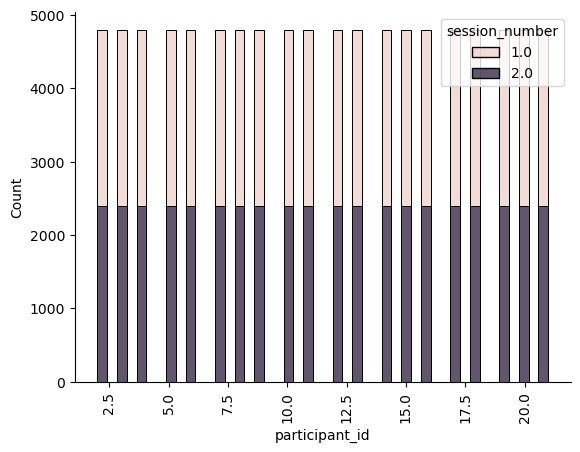

In [8]:
sns.histplot(data = trial_data,
             x = 'participant_id',
             hue = 'session_number',
            multiple = 'stack')
plt.xticks(rotation = 90);

### Show the distribution

In [9]:
participant_col = 'prolific_id'
condition_col = 'condition_name'
jump_conds = ['no_jump', 'jump']
jump_col = 'stimJumped'
flash_conds = ['no_flash', 'flash']
flash_col = 'flashShown'

base_colors = ['3DA7B8', '333333', '777777', '3DA7B8']
shade_step_size = 0.01
time_col = 'touchOff_relative'

trial_data = trial_data.reset_index(drop = True)

### Show the distribution of each tap over time

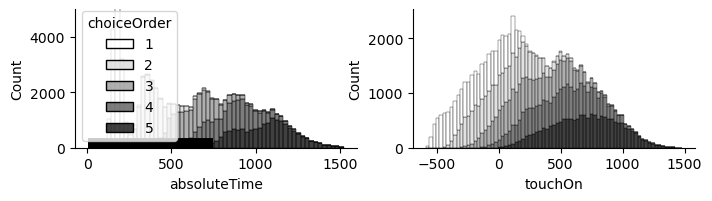

In [10]:
fig, axs = plt.subplots(1,2, figsize = (8, 1.8))
nonull_data = trial_data[trial_data.choiceOrder!=0]
nonull_data = nonull_data.reset_index(drop = True)
nonull_data['absoluteTime'] = nonull_data['touchOn'] + nonull_data['flashOnTime']
fig = sns.histplot(data=nonull_data,
                   x = 'absoluteTime',
                   hue = 'choiceOrder',
                   multiple='stack',
                   palette = 'Greys',
                   ax = axs[0]);

axs[0].set_ylim([0,5000])

null_data = trial_data[trial_data.choiceOrder==0]
axs[0].hlines(100, min(null_data.flashOnTime), max(null_data.flashOnTime), color = 'black', linewidth = 10);


fig = sns.histplot(data=nonull_data,
                   x = 'touchOn',
                   hue = 'choiceOrder',
                   multiple='stack',
                   palette = 'Greys',
                   ax = axs[1],
                   legend = False);



### Typical duration of a trial

In [11]:
trial_durations = abs(trial_data[trial_data.choiceOrder == 0].touchOn.values - trial_data[trial_data.choiceOrder == 5].touchOn.values)

print(f'mean: {np.nanmean(trial_durations)}')
print(f'min: {np.nanmin(trial_durations)}')
print(f'max: {np.nanmax(trial_durations)}')
print(f'median: {np.nanmedian(trial_durations)}')      
print(f'std: {np.nanstd(trial_durations)}')      

mean: 1056.0705440900533
min: 560.0
max: 1524.0
median: 1071.0
std: 169.615082832701


### Rate Analysis

#### Parameter Definition

In [12]:
# data file paths
movement_rate_metrics_path = f'{results_path}/movement_rate_metrics_{study_name}.csv' # here we put the path name for the rate metrics
movement_rate_figure_path = f'{results_path}/movement_rate_figure_{study_name}.svg' # here we put the path name for the rate metrics
movement_rate_test_path  = f'{data_path}/test_files/movement_rate_test_{study_name}.csv' # this is a test file we create manually by saving the first version of the analysis testing for validity
movement_rate_cluster_file = f'{results_path}/movement_rate_clusters_{study_name}.csv'
raw_movement_rate_file = f'{results_path}/raw_movement_rate_clusters_{study_name}.svg'

# define the conditions
conditions_rates = {
    'flash_jump': {'flashShown': 1,
                  'stimJumped': 1},
    'flash_no_jump': {'flashShown': 1,
                  'stimJumped': 0},
    'no_flash_jump': {'flashShown': 0,
                  'stimJumped': 1},
    'no_flash_no_jump': {'flashShown': 0,
                  'stimJumped': 0},
}

# define color scheme for plots
# define the conditions
conditions_rates = {
    'flash+ jump+': {'flashShown': 1,
                  'stimJumped': 1},
    'flash+ jump-': {'flashShown': 1,
                  'stimJumped': 0},
    'flash- jump+': {'flashShown': 0,
                  'stimJumped': 1},
    'flash- jump-': {'flashShown': 0,
                  'stimJumped': 0},
}

color_rates = {'flash+ jump+': '#3DA7B8', 
          'flash+ jump-': '#3DA7B8', 
          'flash- jump+': '#333333', 
          'flash- jump-': '#333333'}

linestyles = {
          'flash+ jump+': '-', 
          'flash+ jump-': '--', 
          'flash- jump+': '-', 
          'flash- jump-': '--'}

# set parameters for our analysis
rate_analysis_parameters = {'window_start': -700,
                            'window_end': 1500,
                            'search_start': 0,
                            'search_end': 700,
                            'baseline_start': -100,
                            'baseline_end': 0,
                            'alpha': 1/50}

# define column names for the analysis
move_offset_col = 'touchOn_relative' # touchOn marks the time participants tapped on the screen. This happens at the END of a movement
move_onset_col = 'touchOff_relative' # touchOff is the time participants lifted their finder from the screen. This is the ONSET of a movement
participant_col = 'participant_id'
touch_order_col = 'choiceOrder'

# define the condition name for the baseline
baseline_name = 'flash- jump-'

# ANOVA - define variables 
# We'll run one ANOVA per DV, with all IVs as input
dependent_variables = ['magnitude', 'latency']
independent_variables = ['flash_shown', 'stim_jumped']

#### Run Analysis

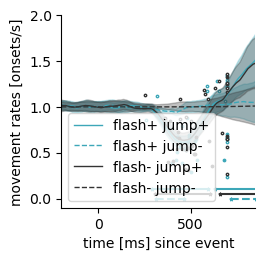

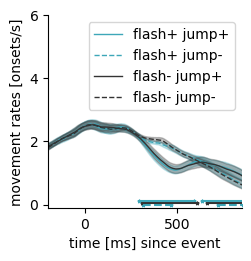

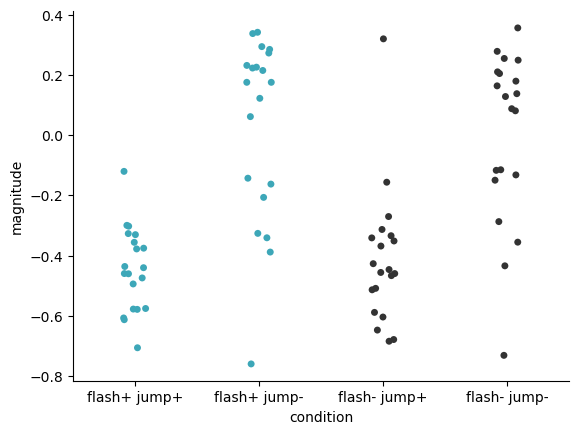

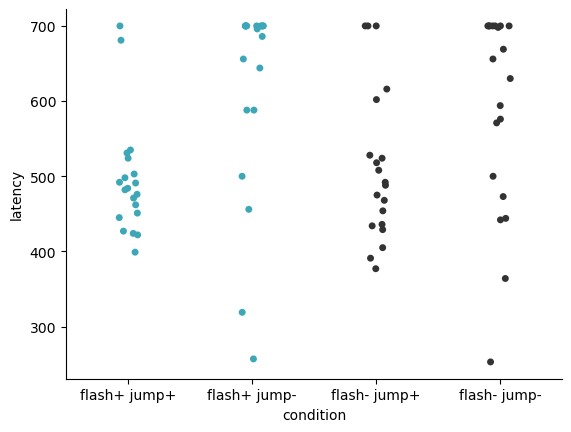

Results from ANOVA with 
DEPENDENT variable: MAGNITUDE; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.0001 1.0000 19.0000 0.9917
stim_jumped             35.9721 1.0000 19.0000 0.0000
flash_shown:stim_jumped  2.0574 1.0000 19.0000 0.1677

Results from ANOVA with 
DEPENDENT variable: LATENCY; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.1914 1.0000 19.0000 0.6667
stim_jumped             13.9483 1.0000 19.0000 0.0014
flash_shown:stim_jumped  2.4645 1.0000 19.0000 0.1329



In [13]:
analysis_rates(trial_data,
               move_offset_col,
               move_onset_col,
               participant_col,
               rate_analysis_parameters,
               touch_order_col,
               conditions_rates, 
               color_rates,
               linestyles,
               movement_rate_metrics_path,
               movement_rate_figure_path,
               raw_movement_rate_file,
               dependent_variables,
               independent_variables,
               baseline_name,
               results_path,
               movement_rate_cluster_file)

#### Test if the metrics changed

In [14]:
# parse.test_file_equality(movement_rate_metrics_path, movement_rate_test_path)

In [15]:
# Characterization of the raw movement rates
raw_rate_path = f'{results_path}/movement_rates_raw_{study_name}.csv'
raw_rates = pd.read_csv(raw_rate_path)
raw_rates_window = raw_rates[[str(x) for x in np.arange(-100, 0)]]
raw_rates['median_rate'] = raw_rates_window.median(axis = 1, numeric_only = True)
raw_rates = raw_rates[['participant', 'index', 'median_rate']]
describe_rates = raw_rates.groupby(['index']).describe()['median_rate']
describe_rates['sem'] = describe_rates['std']/np.sqrt(describe_rates['count'])
describe_rates

,count,mean,std,min,25%,50%,75%,max,sem
index,,,,,,,,,
flash+ jump+,21.0,4.882426,0.517822,4.264397,4.455692,4.811132,4.974025,6.302087,0.112998
flash+ jump-,21.0,4.937485,0.544991,4.328386,4.484648,4.856681,5.190668,6.354484,0.118927
flash- jump+,21.0,4.940754,0.548039,4.362531,4.606498,4.742777,5.161117,6.464918,0.119592
flash- jump-,21.0,4.884761,0.534267,4.156097,4.556463,4.795699,4.979612,6.391547,0.116587


### Obsersation in plot above:

*Type here* 

### Trial-by-Trial Analysis

- statistical comparison to baseline
- add distribution of trial numbers

In [16]:
figure_path = f'{results_path}/flight_rest_times_figure.svg' # Here we put the name of the figure where we want to save the movement duration analysis


conditions_dict = {
     'flash- jump-': {'flashShown': 0,
                  'stimJumped': 0},
     'flash- jump+': {'flashShown': 0,
                  'stimJumped': 1},
    'flash+ jump+': {'flashShown': 1,
                  'stimJumped': 1},
    'flash+ jump-': {'flashShown': 1,
                  'stimJumped': 0},
   
   
    }


baseline_condition_dict = {'flashShown': 0,
                  'stimJumped': 0}

touch_onset_col = 'touchOn'
touch_offset_col = 'touchOff'
touch_relative_col = 'touchOff_relative'

plot_columns = {'rest': 'rest_times', 'flight': 'flight_times'}
colors = {'flash+ jump+': '#3DA7B8', 
          'flash+ jump-': '#3DA7B8', 
          'flash- jump+': '#333333', 
          'flash- jump-': '#333333'}
linestyles = {
          'flash+ jump+': '-', 
          'flash+ jump-': '--', 
          'flash- jump+': '-', 
          'flash- jump-': '--'
    
}

smooth_window = 50

heatmap_parameters = {'n_col': 42, 'n_row': 20,  'x_min': -700,
                      'x_max': 1400, 'y_min': 0, 'y_max': 500}
heatmap_figure_path = f'{results_path}/heatmaps_latencies_figure.svg'
individual_heatmap_figure_path = f'{results_path}/heatmaps_individual_latencies_figure.svg'
cluster_1d_path = f'{results_path}/rest_flight_time_cluster.csv'
cluster_2d_path = f'{results_path}/heatmap_flight_cluster.csv'

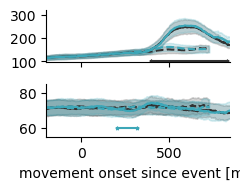

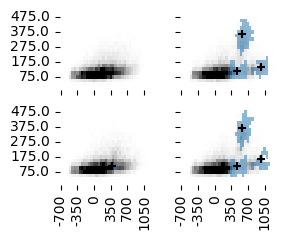

In [17]:
time, participant_timings = trial_by_trial_analysis(trial_data, 
                                                    touch_relative_col, 
                                                    plot_columns, 
                                                    conditions_dict, 
                                                    baseline_condition_dict, 
                                                    colors, 
                                                    linestyles,
                                                    participant_col, 
                                                    touch_onset_col, 
                                                    touch_offset_col, 
                                                    smooth_window, 
                                                    figure_path,
                                                    heatmap_parameters, 
                                                    heatmap_figure_path,
                                                    cluster_1d_path,
                                                    cluster_2d_path,
                                                    results_path)

### Response Position - Mixed or Distinct? 

In [18]:
conditions_dictionary = {'jump +': {'stimJumped': 1},
                         'jump -': {'stimJumped': 0}}

window_center_col = 'window_center'
touch_col = 'touch'
point_col = 'shifted_position'
origin_col = 'position'
dimensions = ['x', 'y']
rotation_degrees = 180
align_position_cols = ['shifted_position', 'centered_touch', 'position']
participant_col = 'participant_id'
heatmap_params = {
    'n_col': 105,
    'n_row': 30,
    'x_min': -700,
    'x_max': 1400,
    'y_min': -1,
    'y_max': 2
}

ci = 0.96
time_col = 'touchOff_relative'

window_width_col = 'windowWidth'
window_height_col = 'windowHeight'
tap_order_col = 'choiceOrder'
scrambled_col = 'scrambled_position'

cluster_table_path = f'{results_path}/landing_position_heatmap_cluster.csv'

# some data transforms
trial_data[f'{window_center_col}_x'] = trial_data[window_width_col]/2
trial_data[f'{window_center_col}_y'] = trial_data[window_height_col]/2

trial_data[f'{touch_col}_x'] = trial_data['touchX']
trial_data[f'{touch_col}_y'] = trial_data['touchY']

# create scrambled comparison for no_jump condition
scramble_data = scramble_columns_piecewise(trial_data, f'{point_col}_x', tap_order_col, f'{scrambled_col}_x', 'subject')
scramble_data = scramble_columns_piecewise(scramble_data, f'{point_col}_y', tap_order_col, f'{scrambled_col}_y', 'subject')
test_data = trial_data.copy(deep = True)
test_data.loc[test_data.stimJumped == 0, f'{point_col}_x'] = scramble_data[scramble_data.stimJumped == 0][f'{scrambled_col}_x'].values
test_data.loc[test_data.stimJumped == 0, f'{point_col}_y'] = scramble_data[scramble_data.stimJumped == 0][f'{scrambled_col}_y'].values

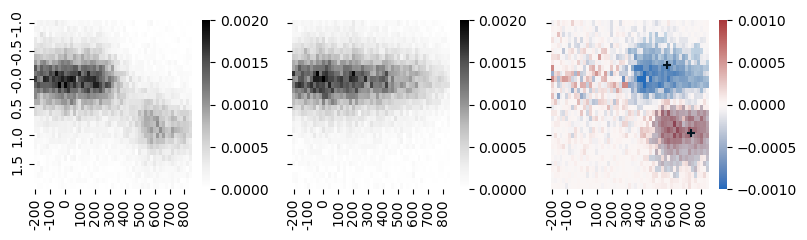

In [19]:
heatmap_dictionary = response_density_analysis(test_data, conditions_dictionary, 
                                               window_center_col, touch_col, 
                                               point_col, origin_col, 
                                               dimensions, rotation_degrees,
                                               align_position_cols, participant_col, 
                                               heatmap_params, time_col, ci, results_path,
                                               cluster_table_path)

## Parse Light Files

In [20]:
participants = ['P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21']
bad_participants = ['P01']

sessions = ['B1', 'B2']
recordings = ['01', '02', '03']

regular_blocks = np.arange(1, 11)

meta_path = f'../../../data/{study_type}/combined_meta'

In [21]:
#"trial_type":"eye-tracker-calibration"
def parse_diode_information(path):
    all_data = parse.load_json(path)
    return all_data

diode_setup_data = parse_diode_information(raw_input_path)
diode_setup_data = diode_setup_data[diode_setup_data['component'] == 'Trials_Serial']
diode_setup_data = diode_setup_data[diode_setup_data['trial_type'] == 'eye-tracker-calibration'].dropna(how = 'all', axis = 1)

In [22]:
diode_setup_data = parse.add_participant_id(diode_setup_data, 
                                              session2part_dict, 
                                              session_code_col, 
                                              condition_code, 
                                              id_col_name,
                                              session_col_name)


In [23]:
calibration_data = parse_diode_information(raw_input_path)
calibration_data = calibration_data[calibration_data['component'] == 'Calibrate_Screen']
calibration_data = calibration_data[calibration_data['trial_type'] == 'virtual-chinrest'].dropna(how = 'all', axis = 1)
calibration_data = parse.add_participant_id(calibration_data, 
                                              session2part_dict, 
                                              session_code_col, 
                                              condition_code, 
                                              id_col_name,
                                              session_col_name)
calibration_data.dropna().to_csv(f'{data_path}/raw/calibration.csv', index = False)

P02 B1 01


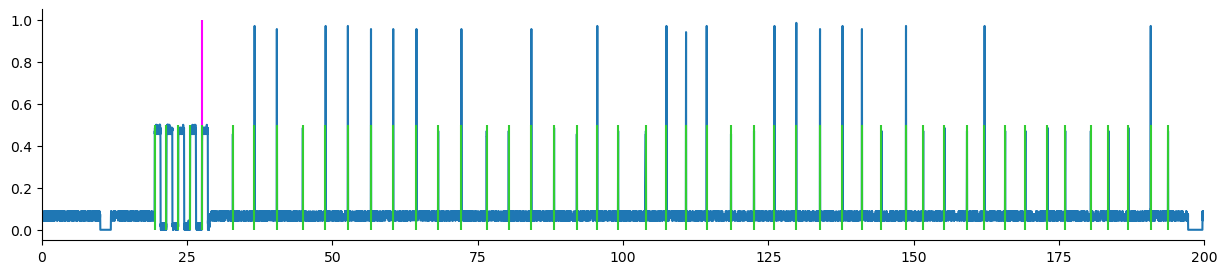

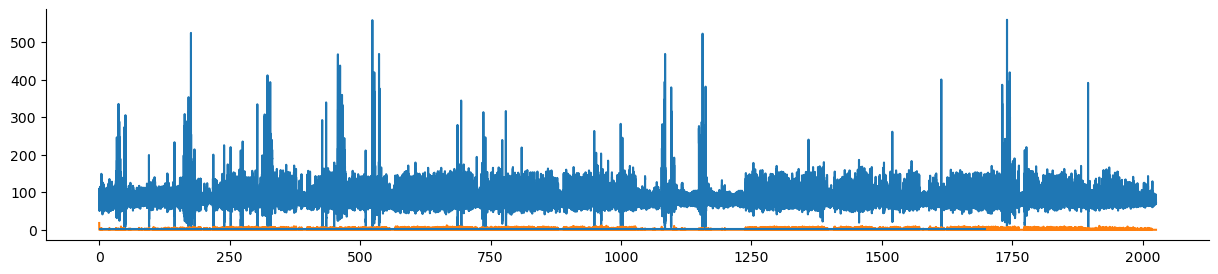

P02 B2 01


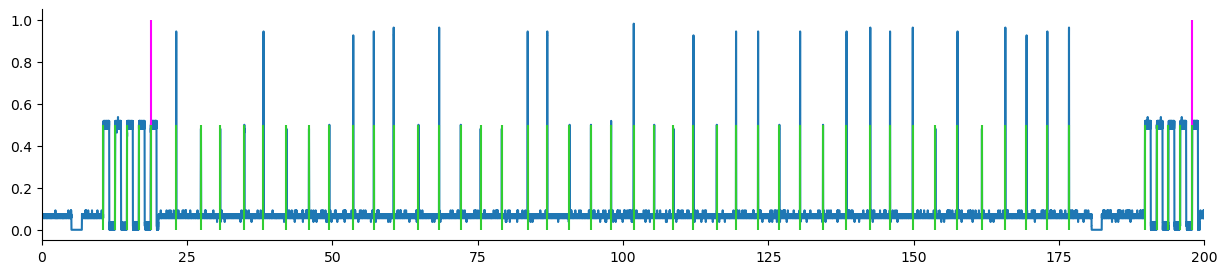

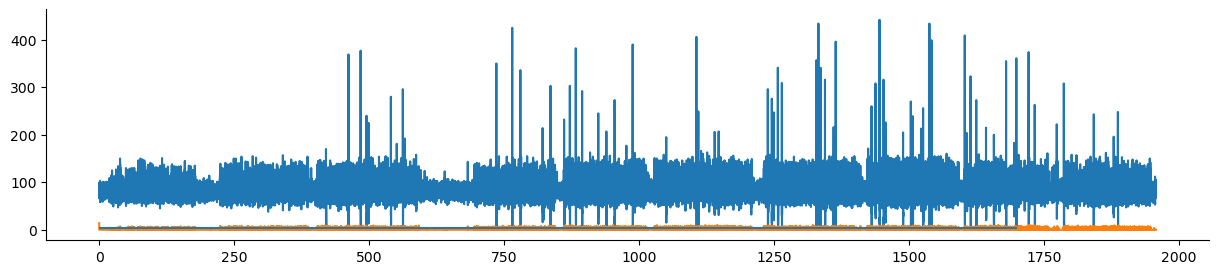

P03 B1 01


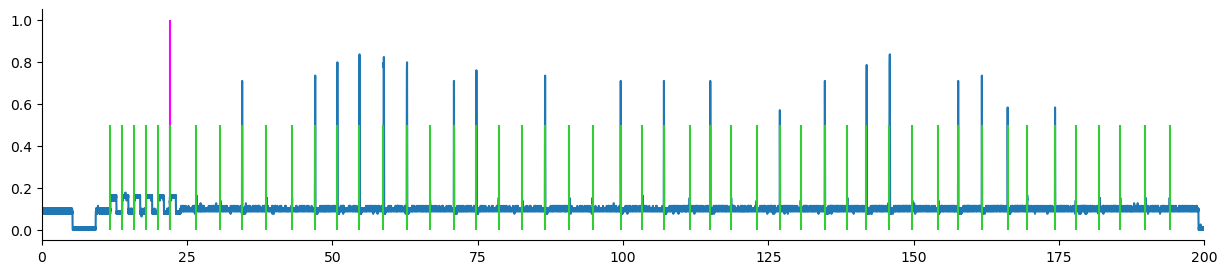

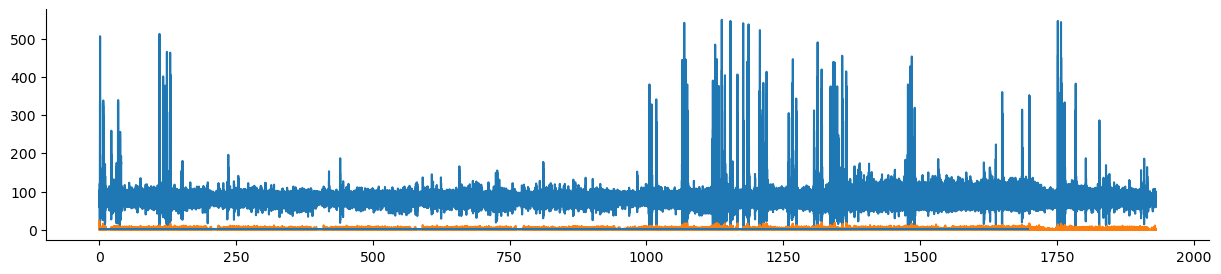

P03 B2 01


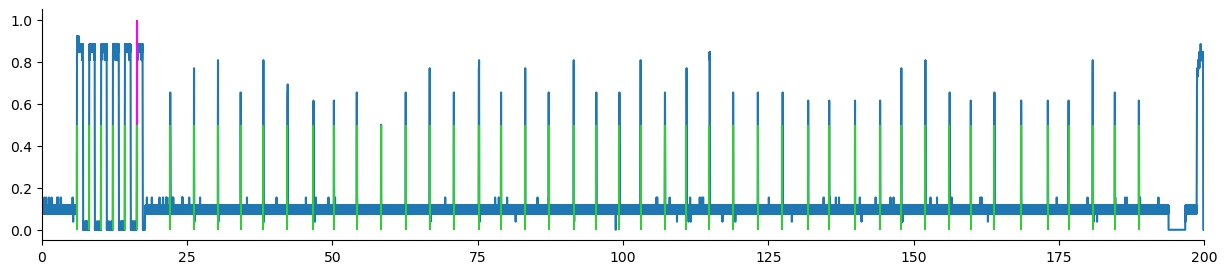

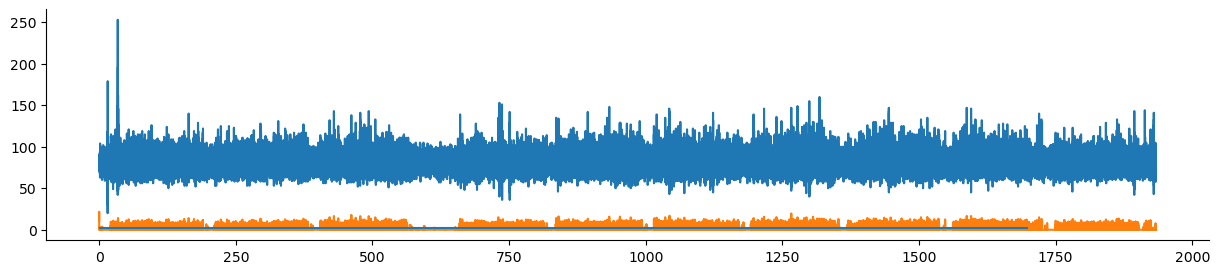

P04 B1 01


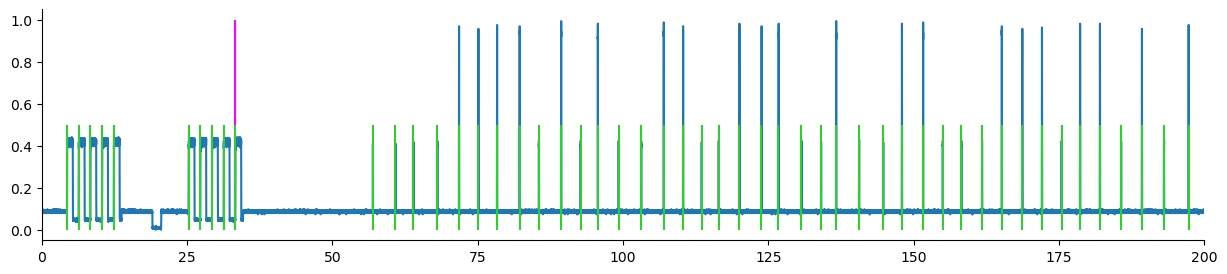

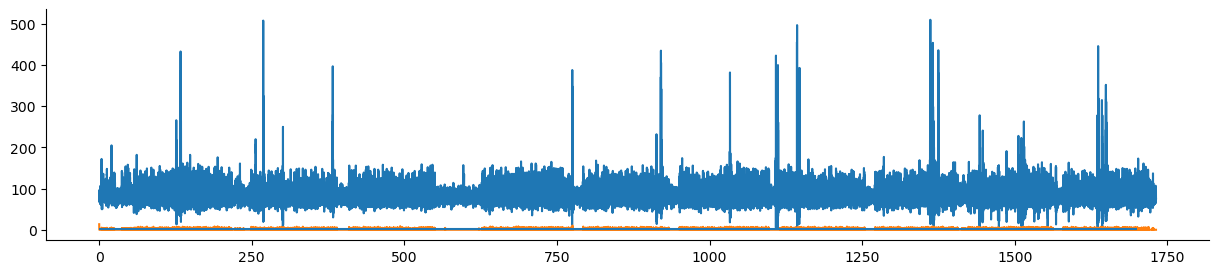

P04 B2 01


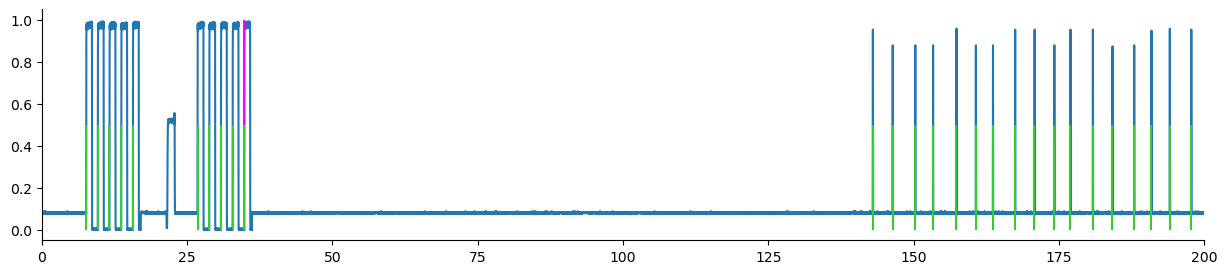

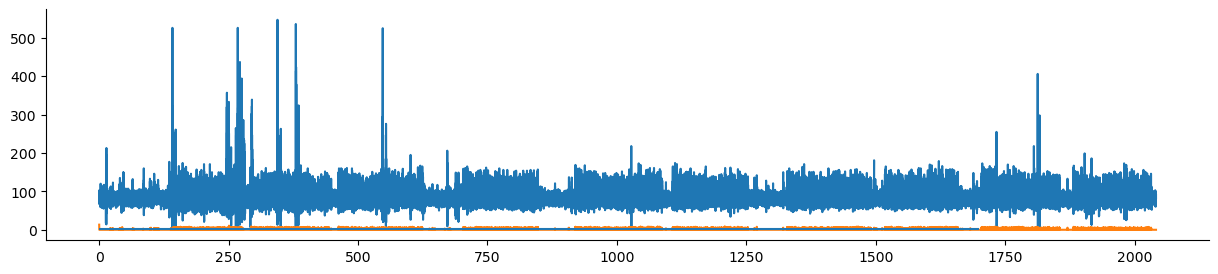

P05 B1 01


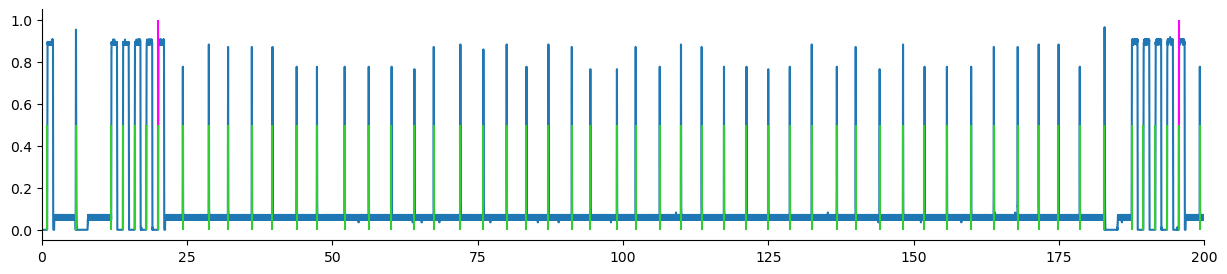

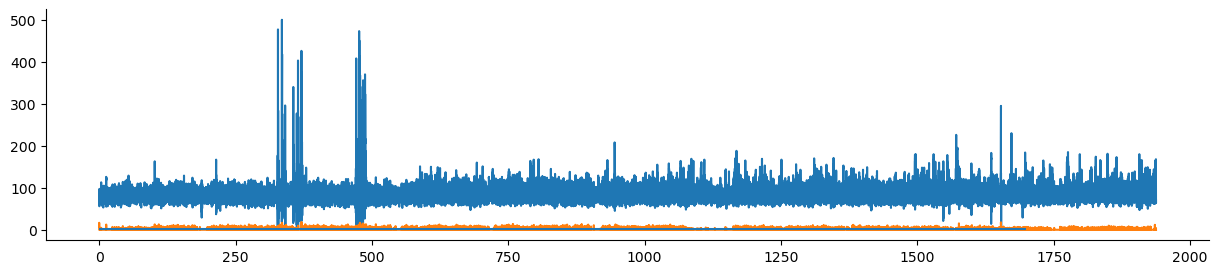

P05 B2 01


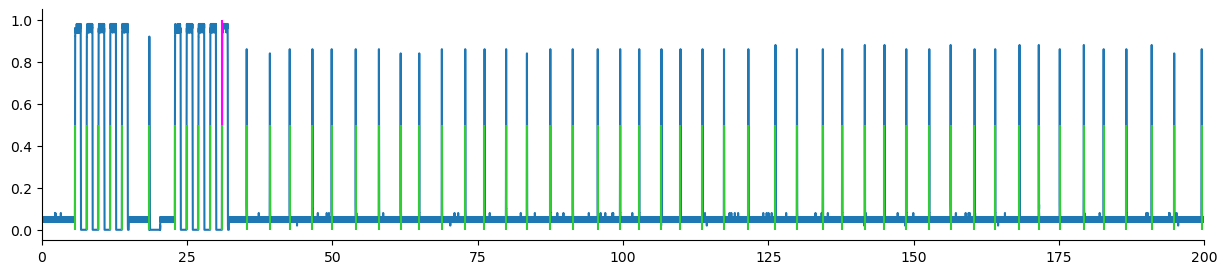

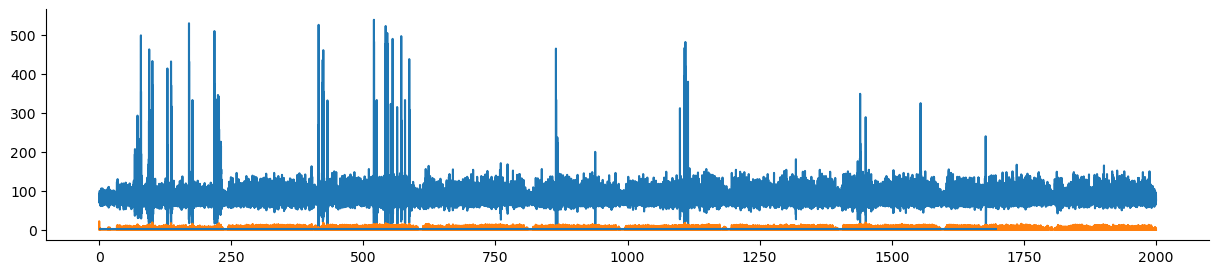

P07 B1 01


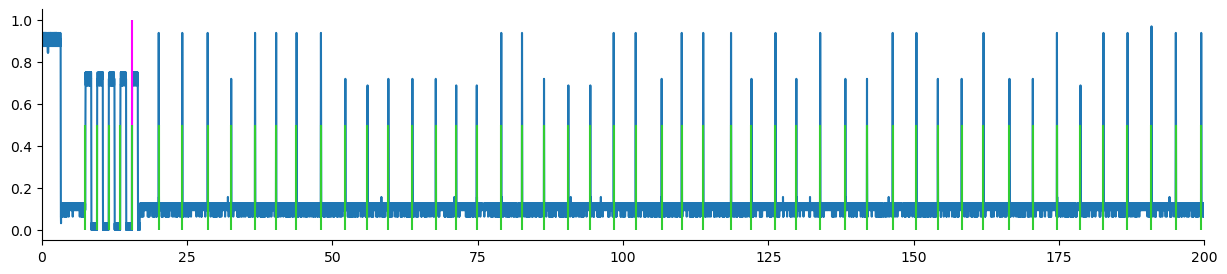

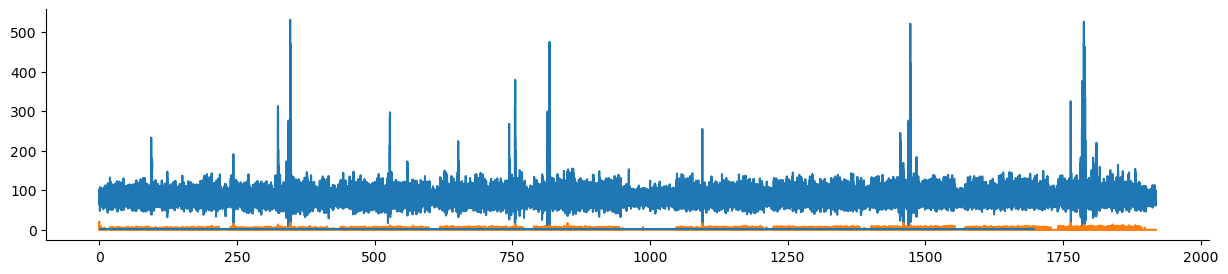

P07 B2 01


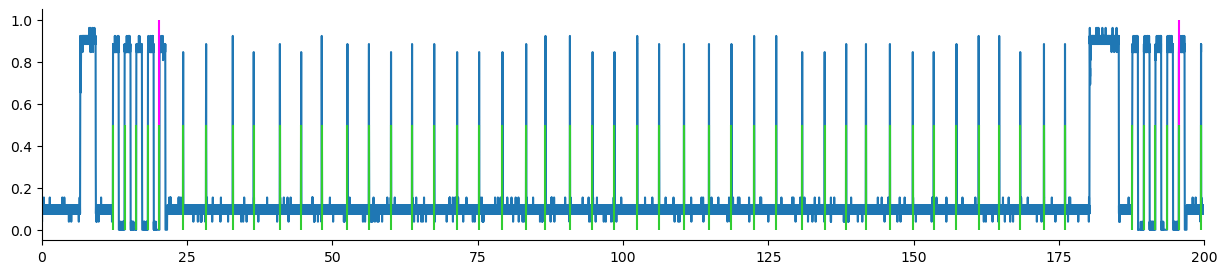

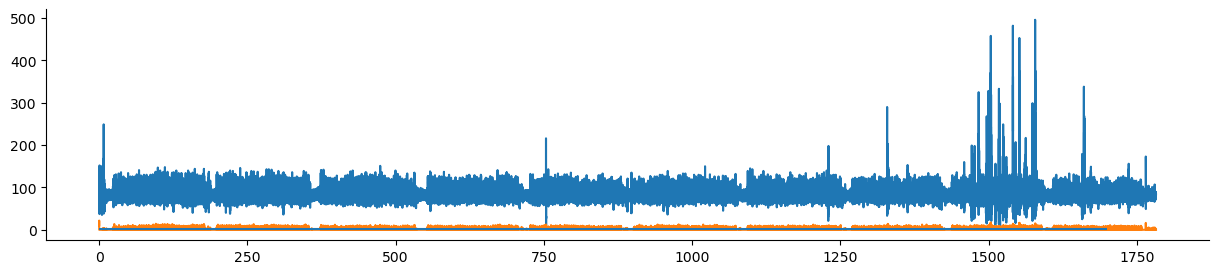

P08 B1 01


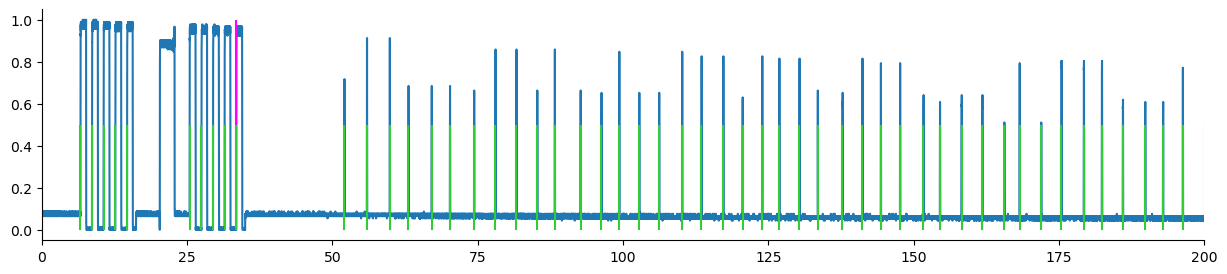

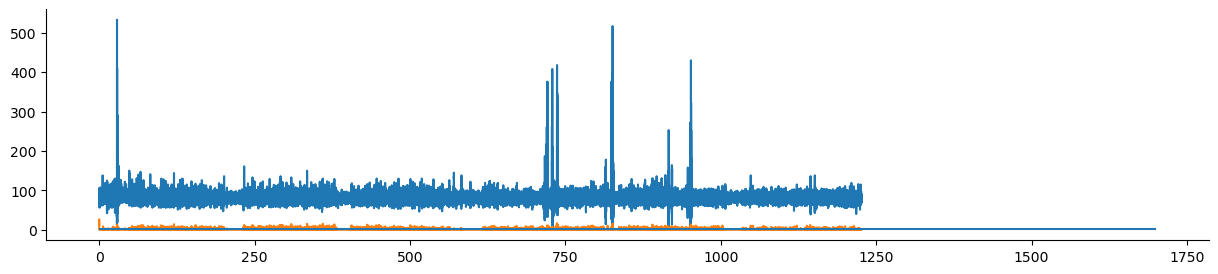

P08 B1 02


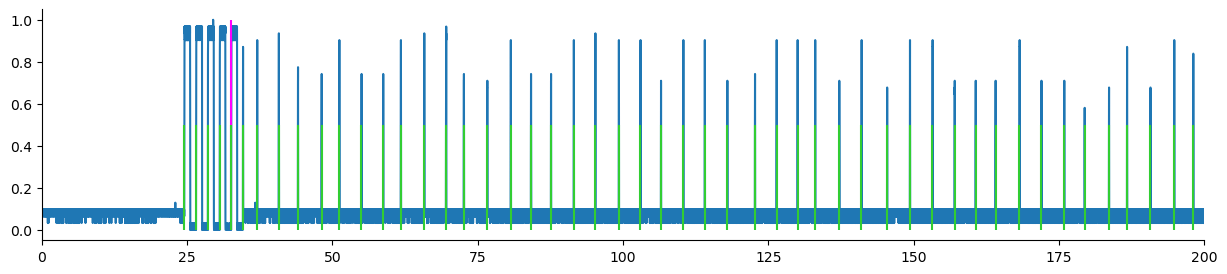

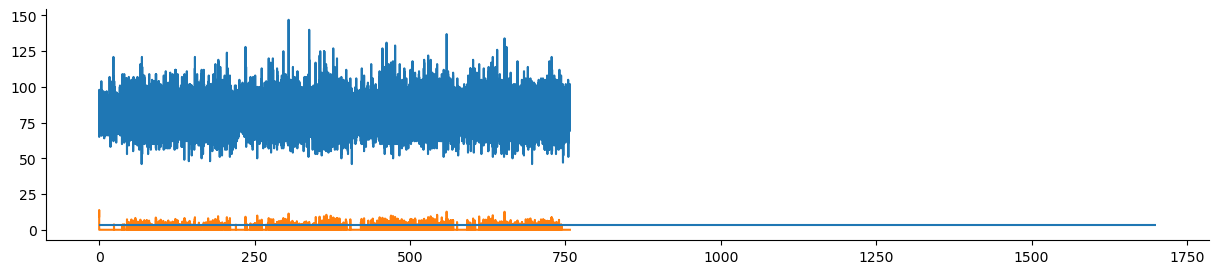

P08 B2 01


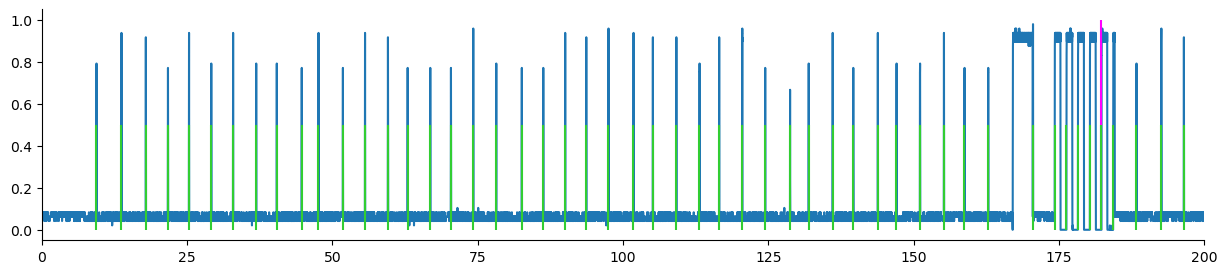

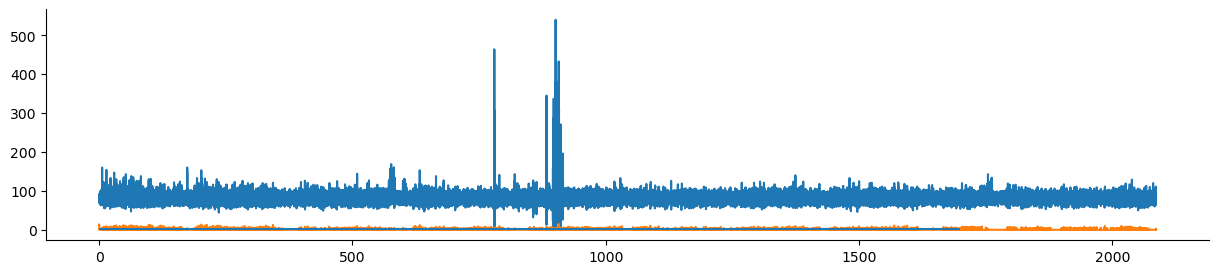

P09 B1 01


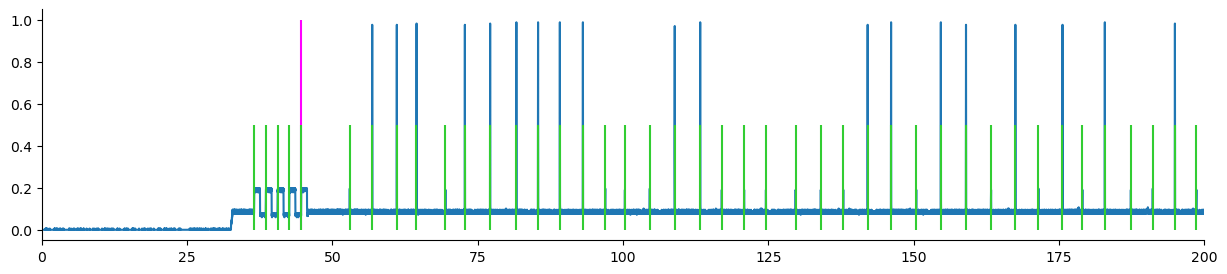

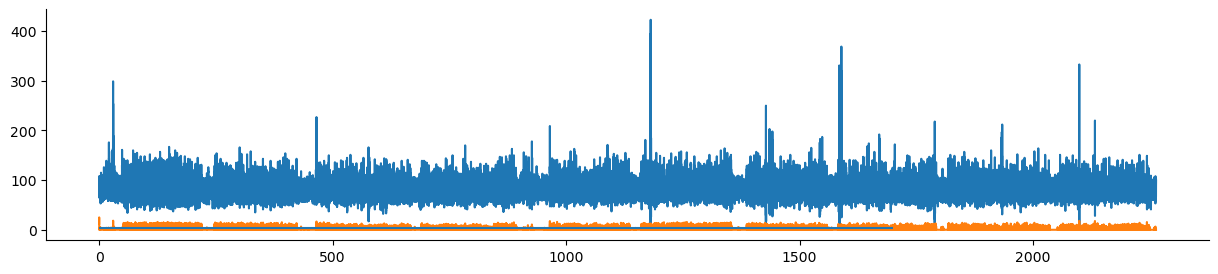

P09 B2 01


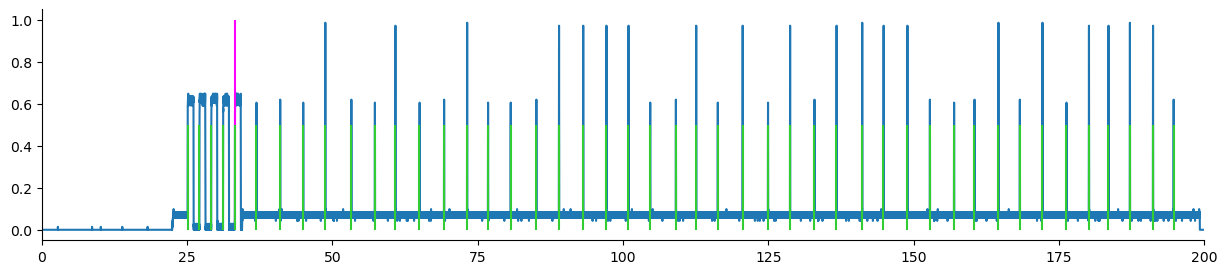

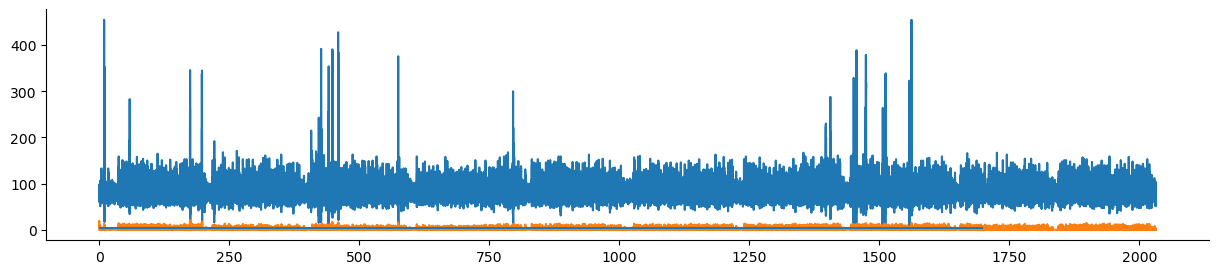

P10 B1 01


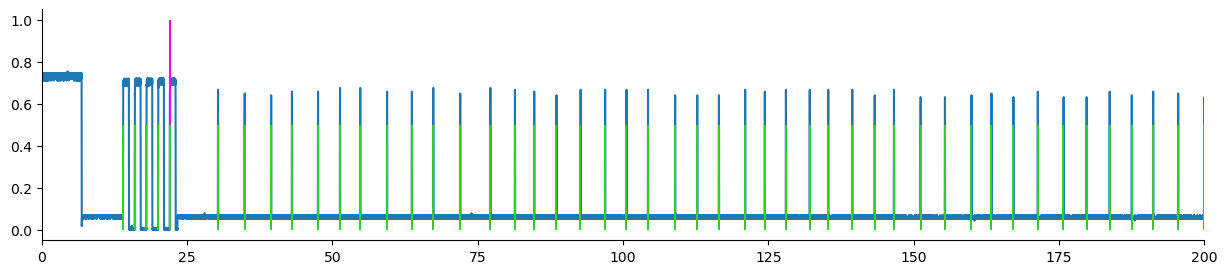

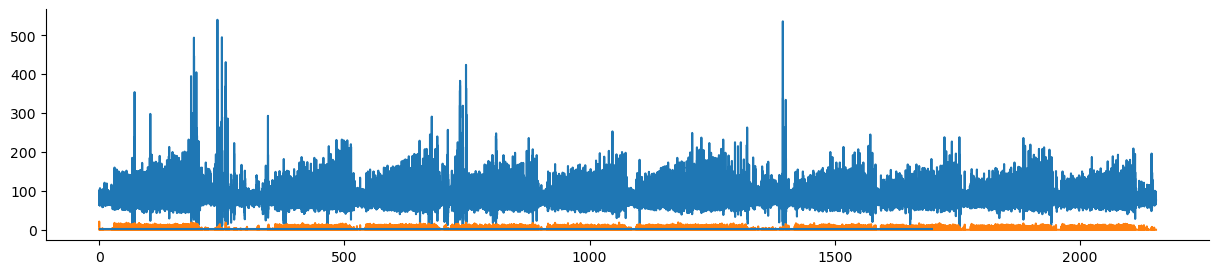

P11 B1 01


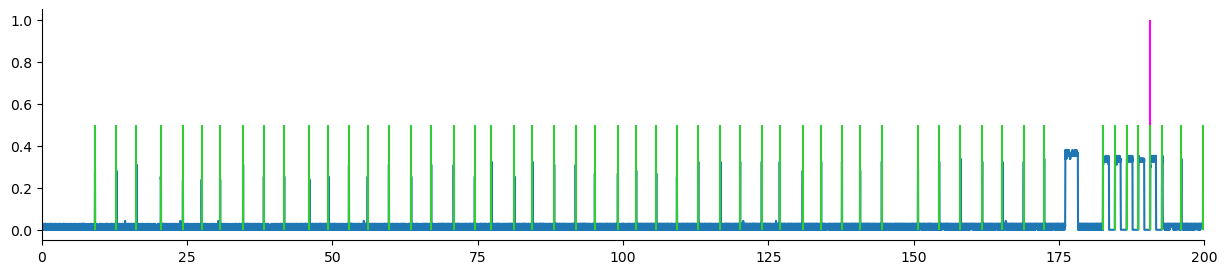

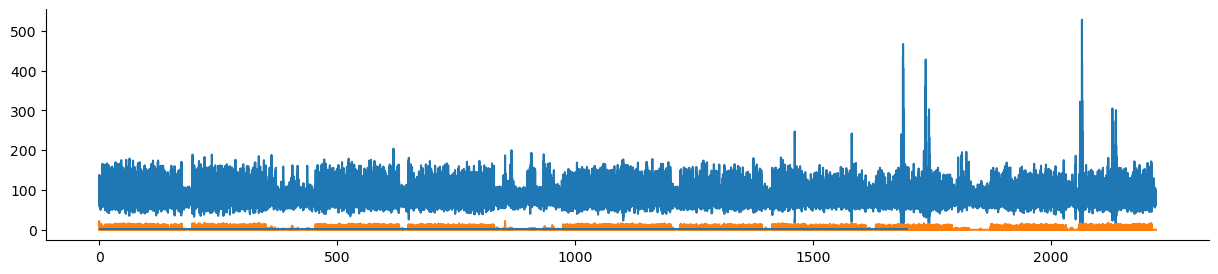

P11 B2 01


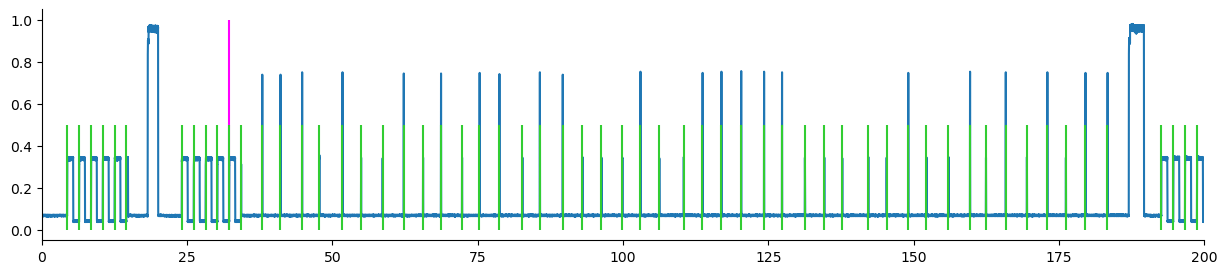

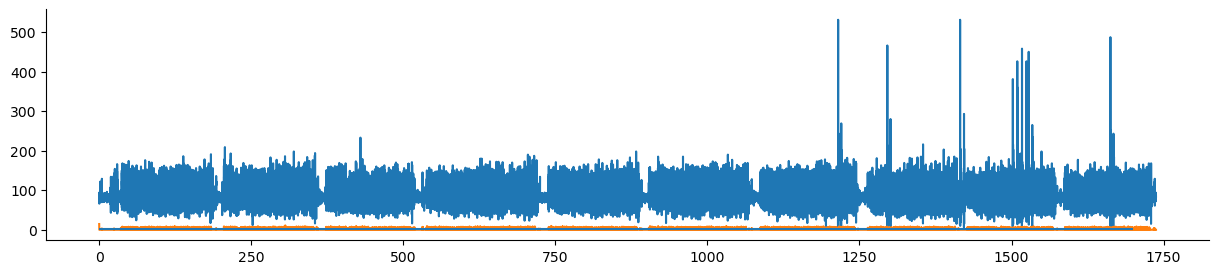

P12 B1 01


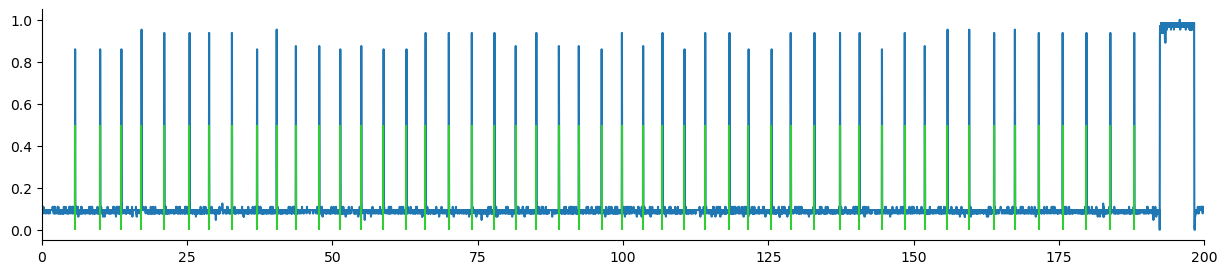

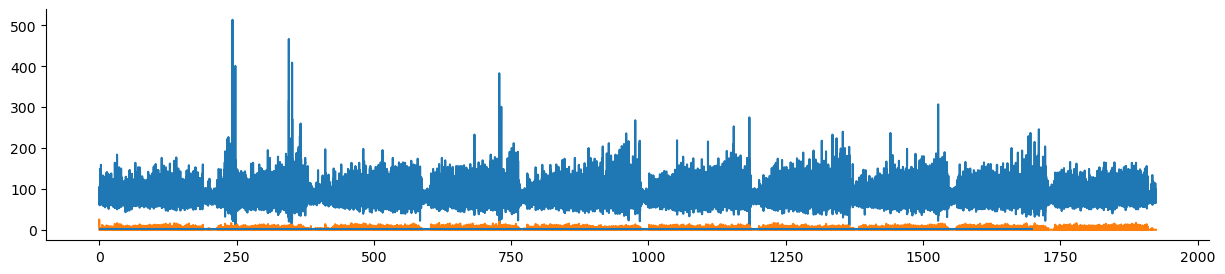

P12 B2 01


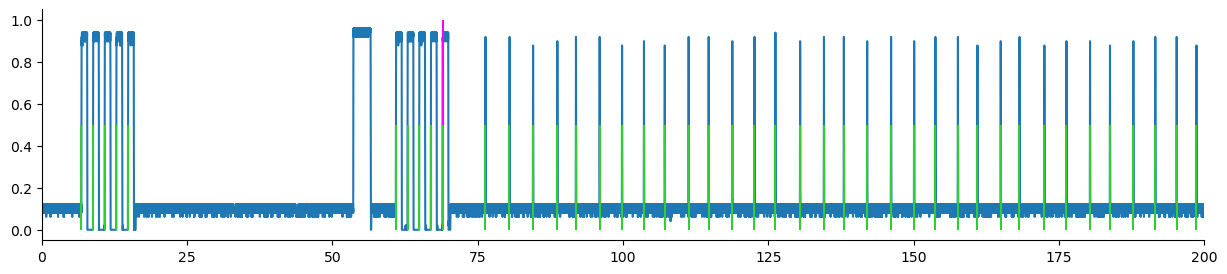

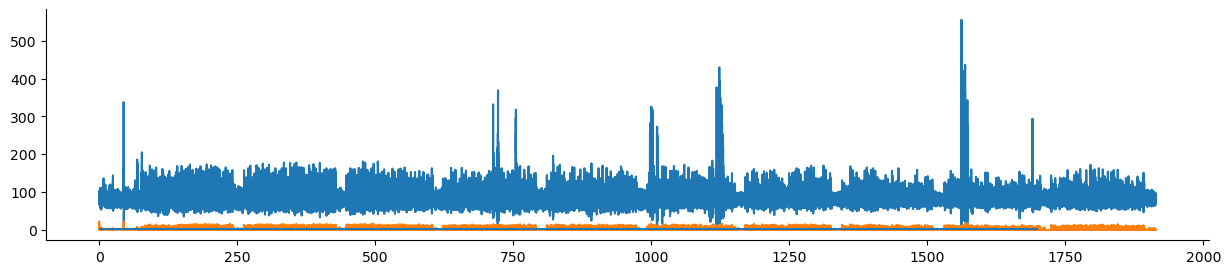

P13 B1 01


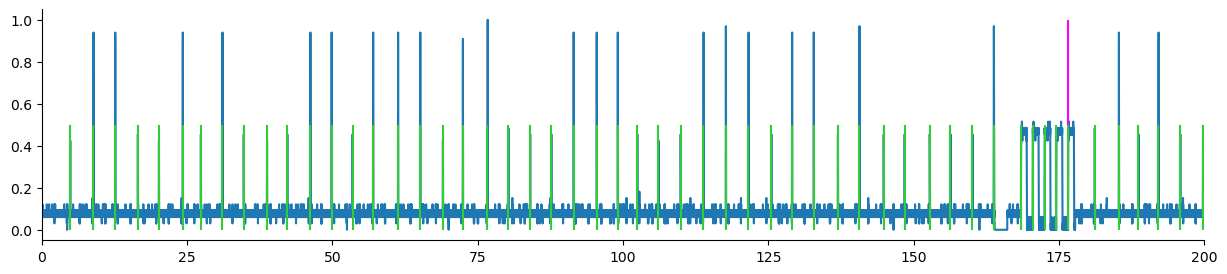

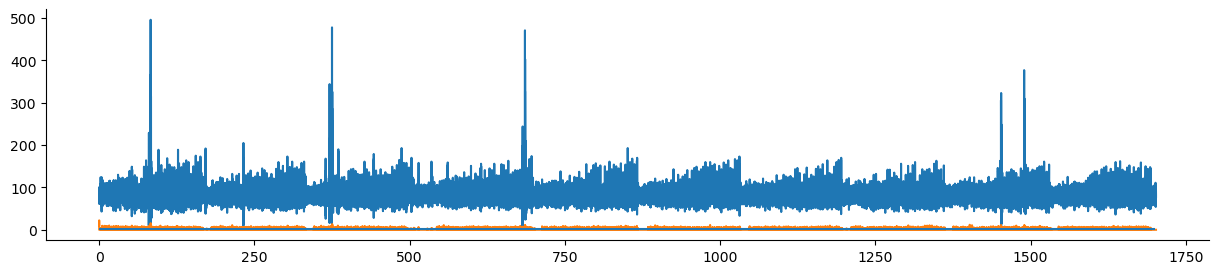

P13 B2 01


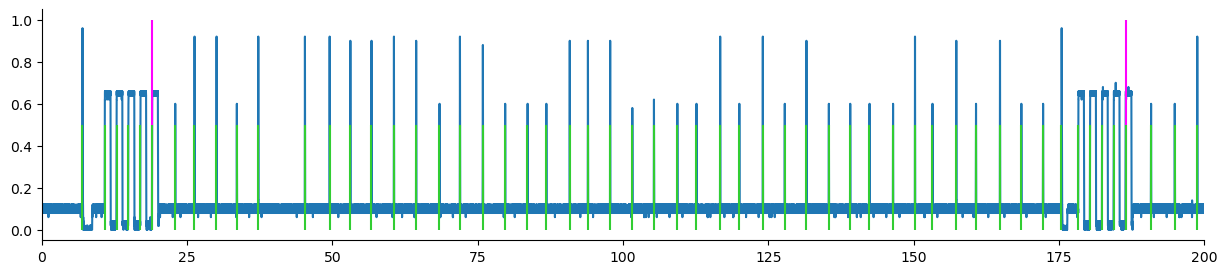

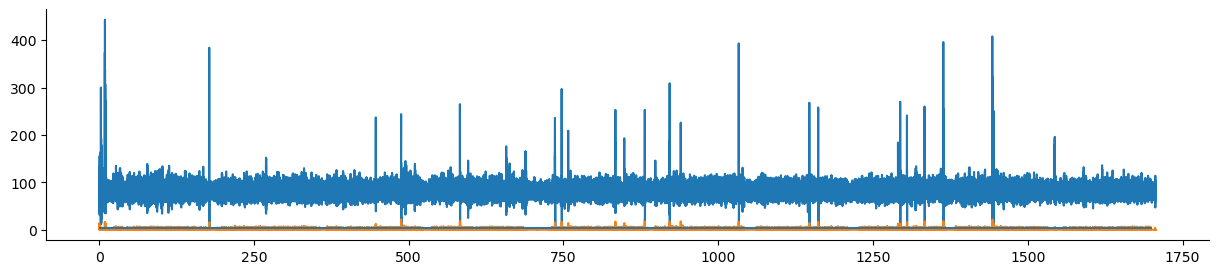

P14 B1 01


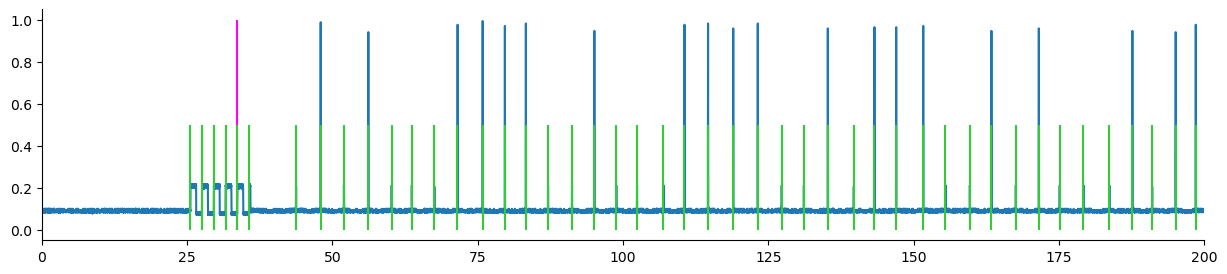

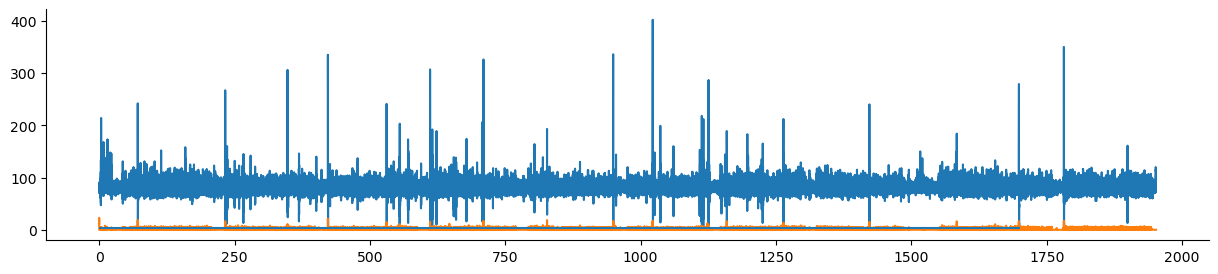

P14 B2 01


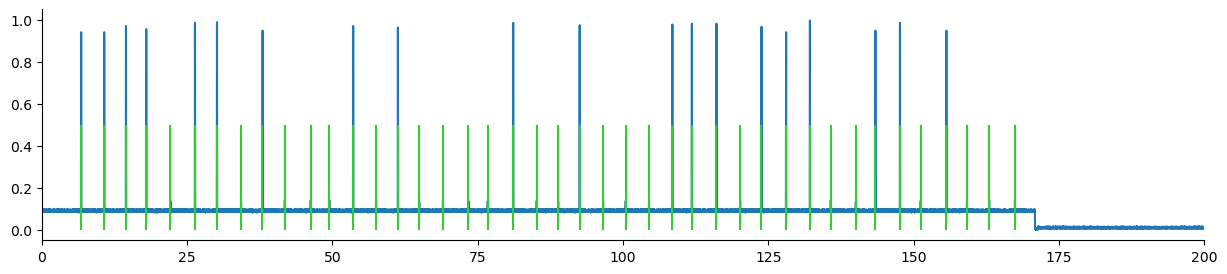

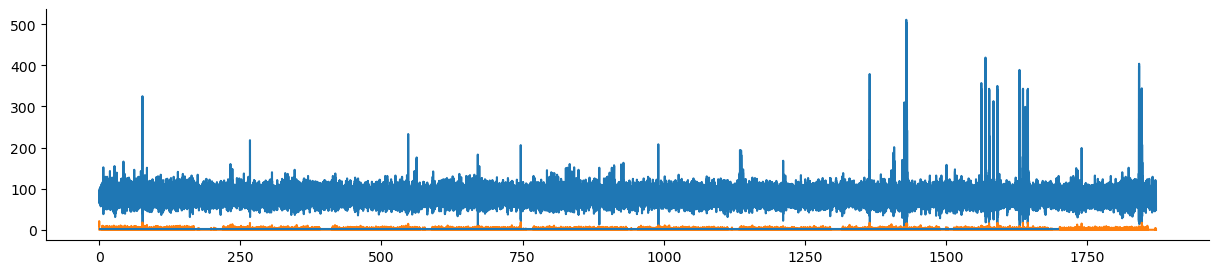

P15 B1 01


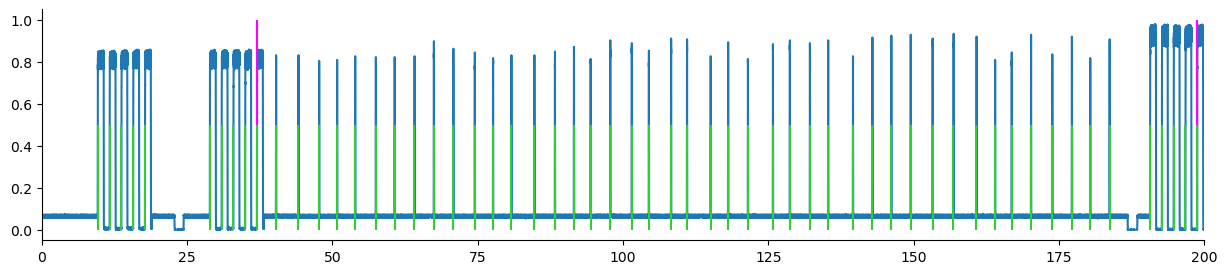

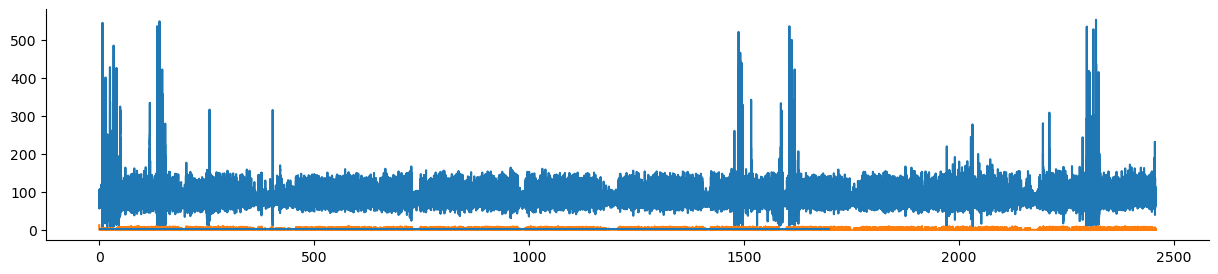

P16 B1 01


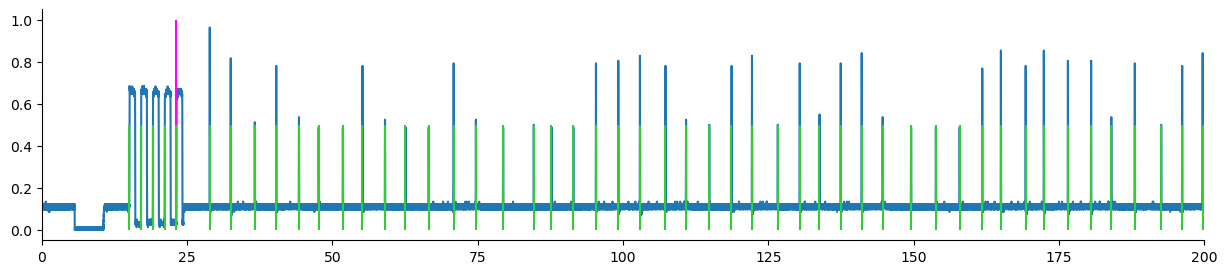

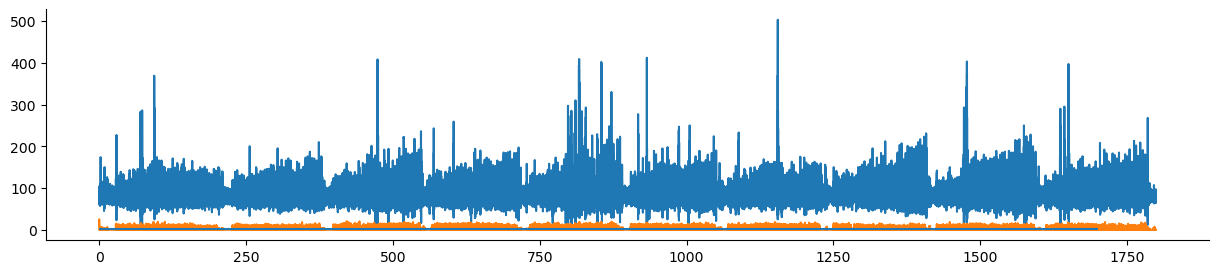

P16 B2 01


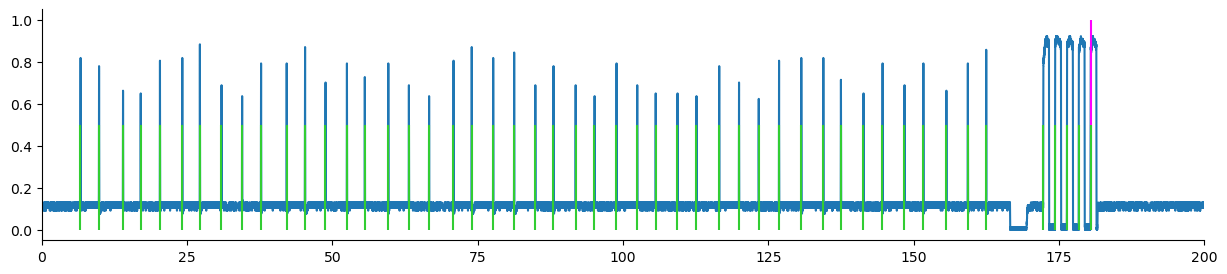

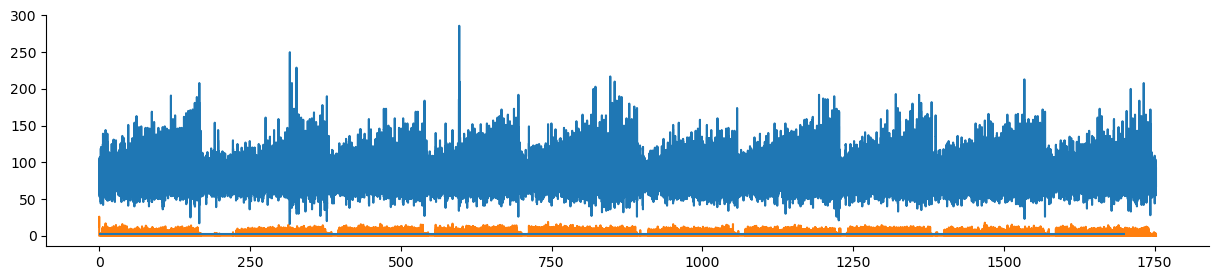

P17 B1 01


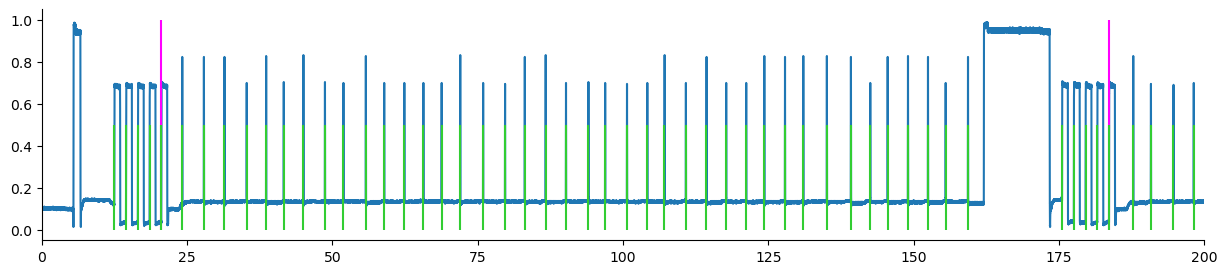

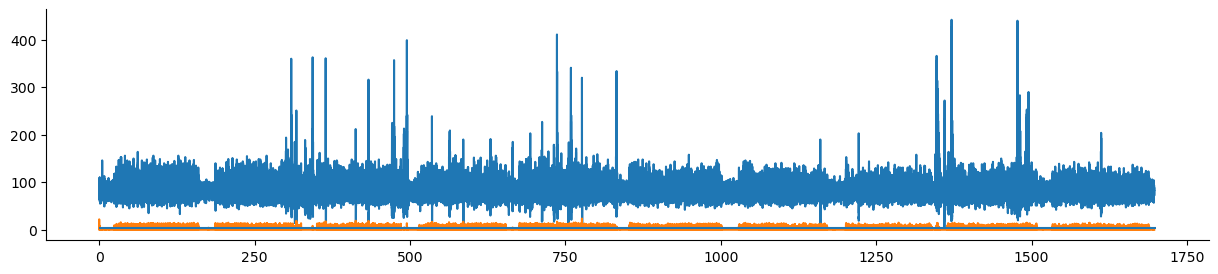

P17 B2 01


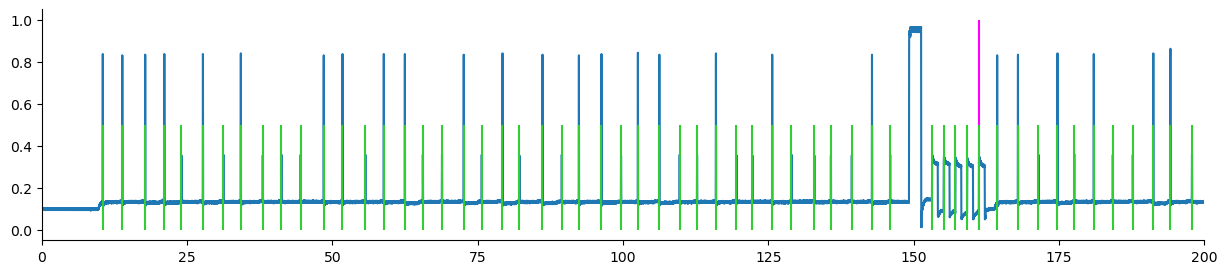

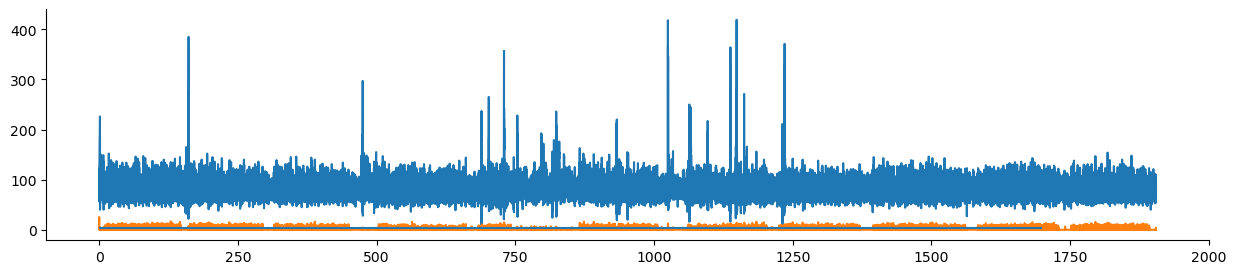

P18 B1 01


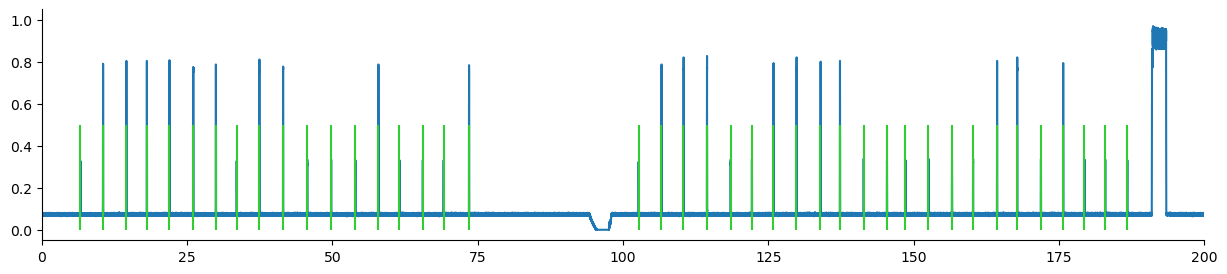

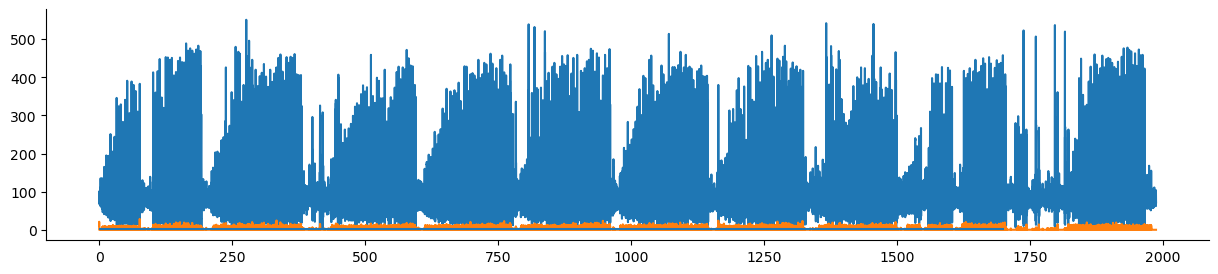

P18 B2 01


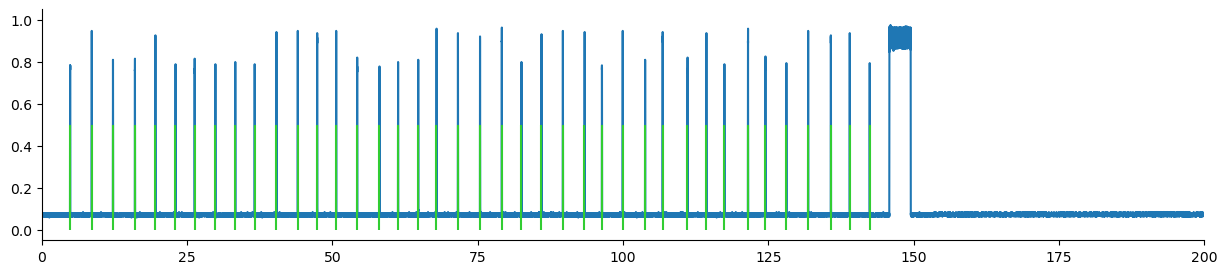

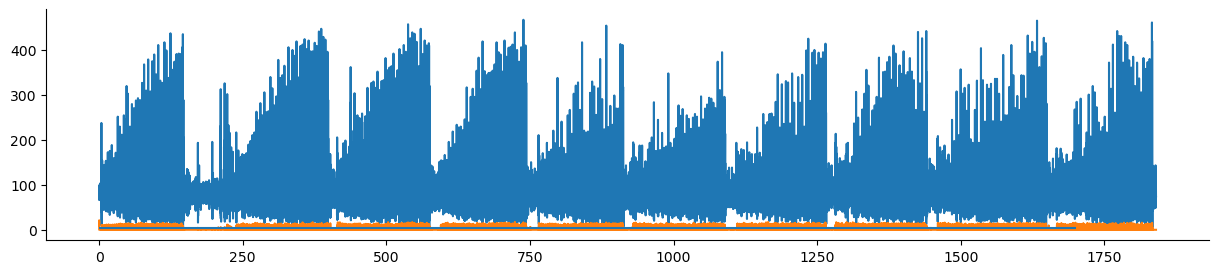

P19 B1 01


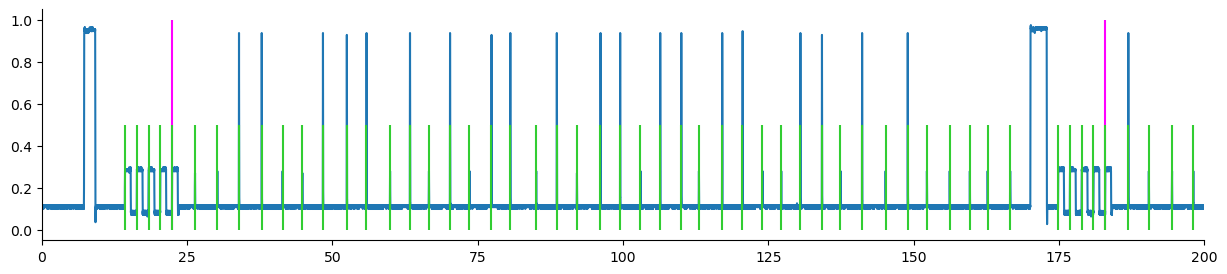

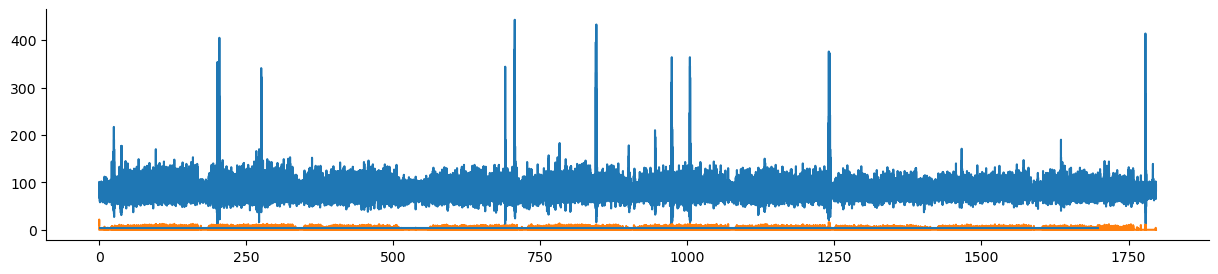

P19 B2 01


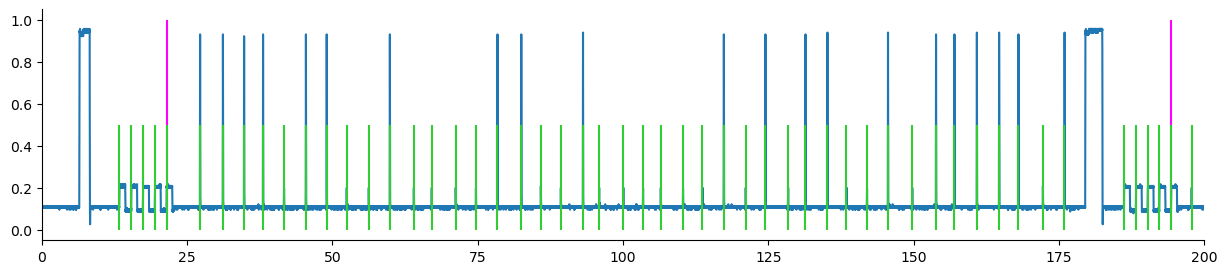

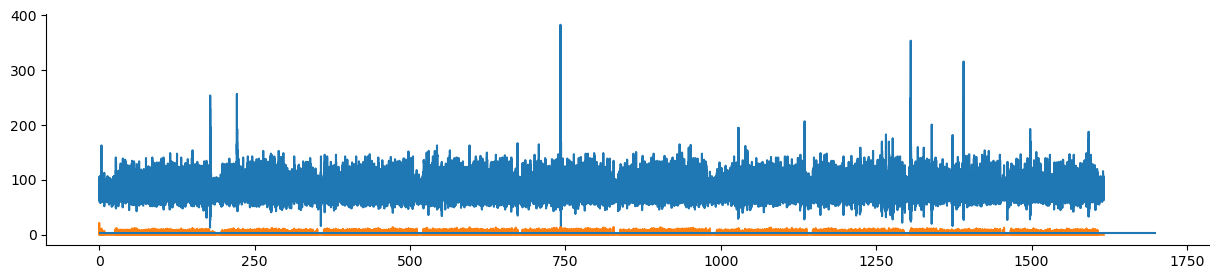

P20 B1 01


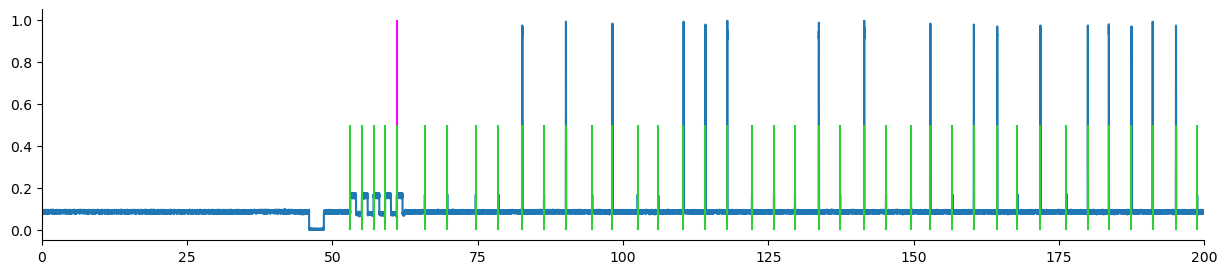

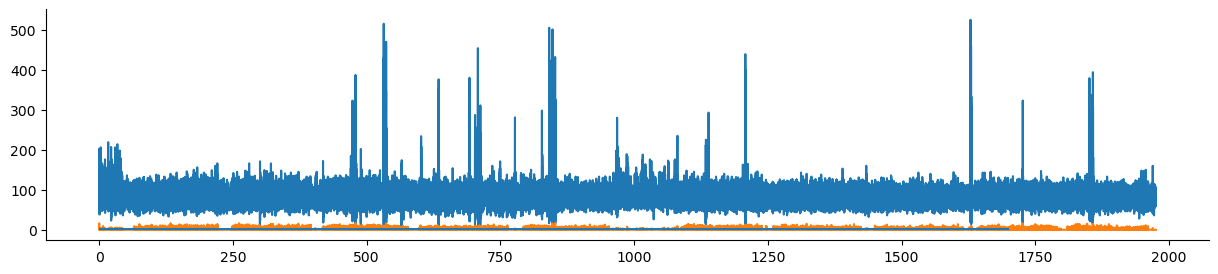

P20 B2 01


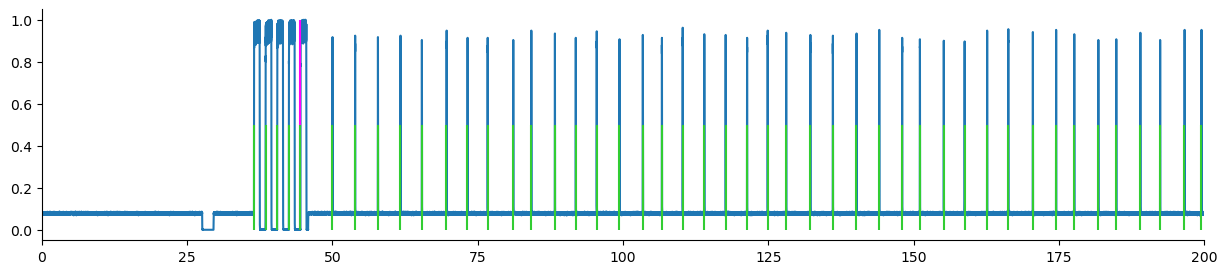

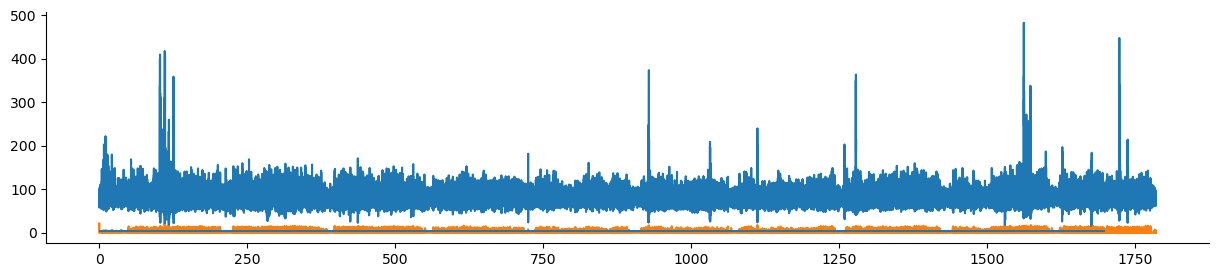

P21 B1 01


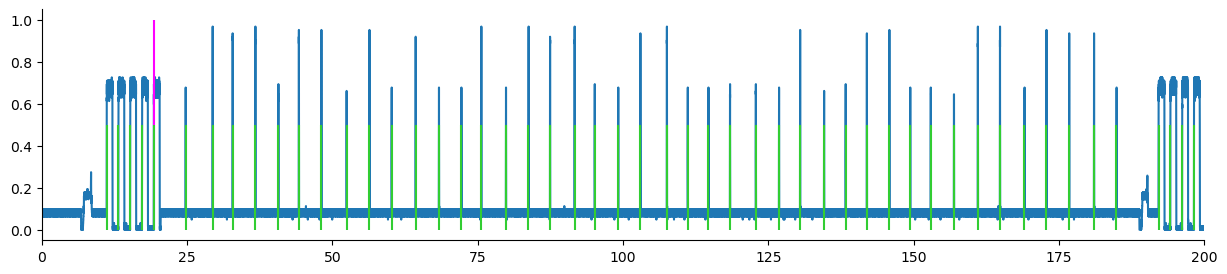

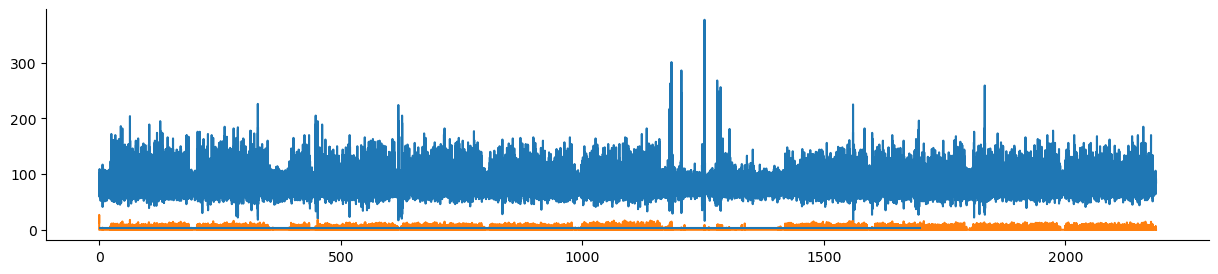

P21 B2 01


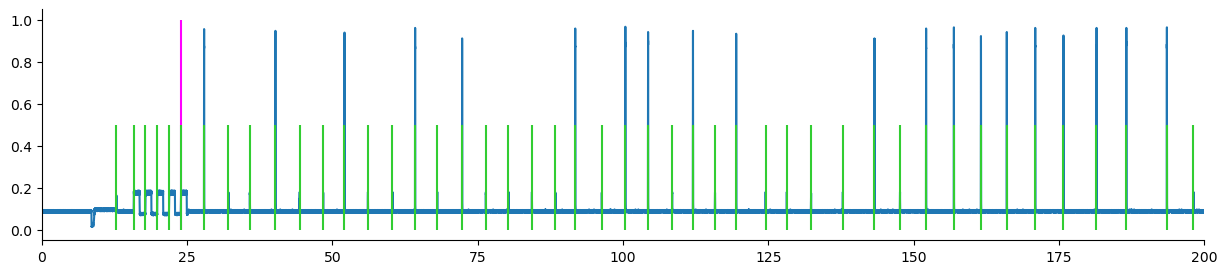

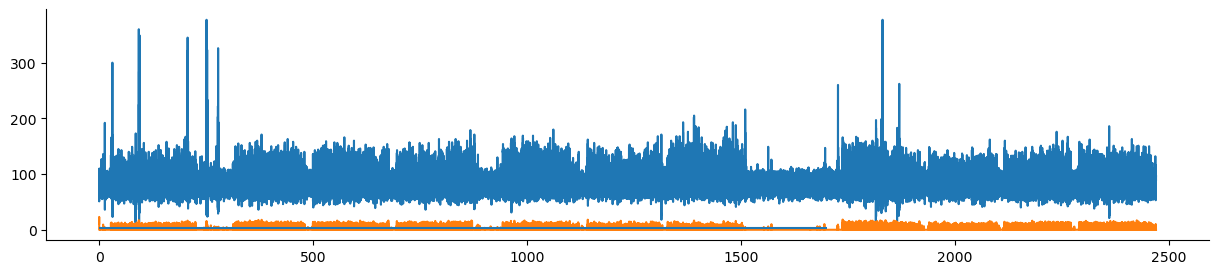

In [24]:
meta_info = pd.read_csv(f'{meta_path}/gaze_meta_info.csv')
# loop through all participants
all_blocks = pd.DataFrame()
all_events = pd.DataFrame()
all_taps = pd.DataFrame()

for p in participants:
    p_code = p.split('P')[1]
    p_info = meta_info[meta_info.participant == p]
    # loop through all sessions - this is one folder
    for s in sessions:
        s_info = p_info[p_info.session == s]
        # loop through recordings - this in one file
        for r in recordings:
            try:
                light_data = pd.read_csv(f'{data_path}/raw/{p}/{s}/{p_code}_{s}_{r}_light.csv')
                sound_data = pd.read_csv(f'{data_path}/raw/{p}/{s}/{p_code}_{s}_{r}_loud.csv')
                r_info = s_info[s_info.recording == int(r)]
                
                if r_info.parse.values:
                    print(p, s, r)
                    light_data['adjusted_timestamp'] = light_data[' timestamp']-light_data[' timestamp'][0]
                    light_data['adjusted_value'] = light_data[' light_value']/max(light_data[' light_value'])
                    sound_data['adjusted_timestamp'] = sound_data[' timestamp'] - sound_data[' timestamp'][0]
                    sound_data['adjusted_value'] = sound_data[' loud_value']

                    fig, axs = plt.subplots(1,1, figsize = (15, 3))
                    axs.plot(light_data['adjusted_timestamp'], light_data['adjusted_value'])
                    
                    events = ld.detect_change_signal(light_data['adjusted_timestamp'], light_data['adjusted_value'], threshold = r_info.detection_threshold.values)
                    events = events[events.duration <= 1.1].reset_index(drop = True)    
    
                    distance_to_next = pd.Series(events[0:-1]['end_time'].values - events['start_time'][1:].values, 
                                                 name = 'distance_to_next',
                                                index = events.index[0:-1])
    
                    events = pd.concat([events, distance_to_next], axis = 1)
                    events = events[abs(events.distance_to_next) >= 0.1].reset_index(drop = True)
                    
                    if type(r_info.missing_blocks.values[0]) == str:
                        drop_blocks = [int(x) for x in r_info.missing_blocks.values[0].split(',')]
                        include_blocks = [x for x in regular_blocks if x not in drop_blocks]
                    elif np.isnan(r_info.missing_blocks.values[0]):
                        include_blocks = [x for x in regular_blocks]

                    add_blocks = []
                    if type(r_info.reloaded_blocks.values[0]) == str:
                        add_blocks = [int(x) for x in r_info.reloaded_blocks.values[0].split(',')]
                    elif np.isnan(r_info.reloaded_blocks.values[0]):
                        pass
                    elif type(r_info.reloaded_blocks.values[0]) == np.float64:
                        add_blocks = [r_info.reloaded_blocks.values[0]]
                    else:
                        print(type(r_info.reloaded_blocks.values[0]))
                    
                    for b in add_blocks:
                        include_blocks.append(b)
                    include_blocks.sort()
                    
                    try:
                        blocks = ld.get_block_onsets(events.start_time.values, events.duration.values, include_blocks)
                        events['block'] = np.nan
                        for idx in blocks.index:
                            block = blocks.loc[idx, 'block_number']
                            onset = blocks.loc[idx, 'onset']
                            axs.vlines(onset, 0, 1, color = 'magenta')
                            try:
                                offset = blocks.loc[idx+1, 'onset'] - 9
                            except KeyError:
                                offset = max(events.start_time)
                            blocks.loc[idx, 'offset'] = offset
    
                            events.loc[events.start_time.between(onset, offset),'block'] = block
                    except:
                        pass

                    axs.vlines(events.start_time, 0, 0.5, color = 'limegreen')
                    axs.set_xlim(0,200)
                    plt.show()

                    events['potential_change_onset'] = events.duration < 0.2
                    
                    # sound
                    fig, axs = plt.subplots(1,1, figsize = (15, 3))
                    axs.plot(sound_data['adjusted_timestamp'], sound_data['adjusted_value'])

                    fs = 1/np.median(np.diff(sound_data['adjusted_timestamp']))
                    lowcut = r_info.iloc[-1]['lowcut']
                    highcut = r_info.iloc[-1]['highcut']
                    noise_threshold = r_info.iloc[-1]['noise_threshold']

                    filtered_sound, raw_filtered = sd.filter_events(sound_data['adjusted_value'], lowcut, highcut, fs, threshold = noise_threshold)
                    sound_data['filtered_values'] = filtered_sound
                    axs.plot(sound_data['adjusted_timestamp'], filtered_sound)
                    axs.hlines(noise_threshold, 0, 1700)
                    detected_touches = sd.detect_touch_events(sound_data['adjusted_timestamp'], sound_data['filtered_values'])
                    
                    #axs.vlines(block_taps[block_taps.start_time.between(60, 90)].start_time, 0, 300, color = 'magenta')
                    
                    # block structure to both
                    for idx in blocks.index:
                        block = blocks.loc[idx, 'block_number']
                        block_events = events[events.start_time.between(blocks.loc[idx, 'onset'], blocks.loc[idx, 'offset'])]
                        block_sound = sound_data[sound_data.adjusted_timestamp.between(blocks.loc[idx, 'onset'] - 10, blocks.loc[idx, 'offset'])]
                        block_taps = detected_touches[detected_touches.start_time.between(blocks.loc[idx, 'onset'], blocks.loc[idx, 'offset'])]
                        block_light = light_data[light_data.adjusted_timestamp.between(blocks.loc[idx, 'onset'] - 10, blocks.loc[idx, 'offset'])]
                        detected_touches.loc[detected_touches.start_time.between(blocks.loc[idx, 'onset'] - 10, blocks.loc[idx, 'offset']), 'block_number'] = block

                    plt.show()
                    
                    events['participant'] = p
                    events['session'] = s
                    events['recording'] = r

                    all_events = pd.concat([all_events, events], ignore_index = True)

                    blocks['participant'] = p
                    blocks['session'] = s
                    blocks['recording'] = r

                    all_blocks = pd.concat([all_blocks, blocks], ignore_index = True)

                    detected_touches['participant'] = p
                    detected_touches['session'] = s
                    detected_touches['recording'] = r

                    all_taps = pd.concat([all_taps, detected_touches], ignore_index = True)
            
            except FileNotFoundError as e:
                if r == '01':
                    print(e)
        
                pass

In [25]:
all_events.to_csv(f'{data_path}/preprocessed/light_diode_events.csv', index = False)
all_blocks.to_csv(f'{data_path}/preprocessed/light_diode_blocks.csv', index = False)
all_taps.to_csv(f'{data_path}/preprocessed/sound_sensor_taps.csv', index = False)

In [26]:
meta_info = pd.read_csv(f'{meta_path}/gaze_meta_info.csv')
full_data['event_onset_in_block'] = np.nan

P02 B1


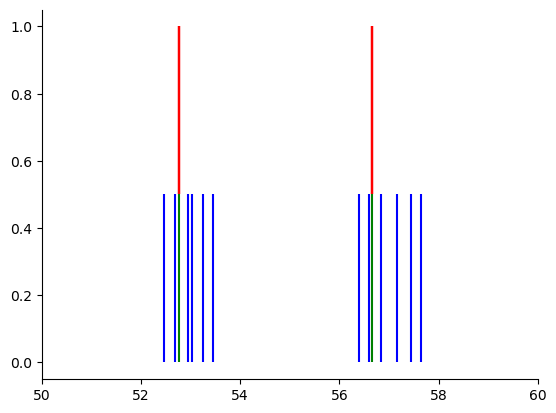

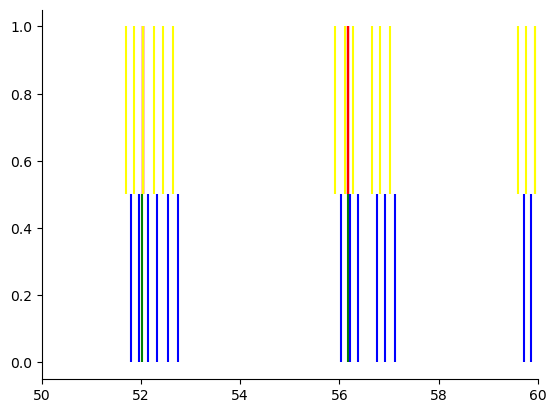

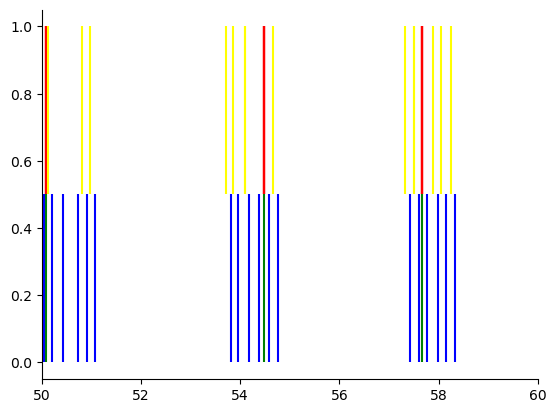

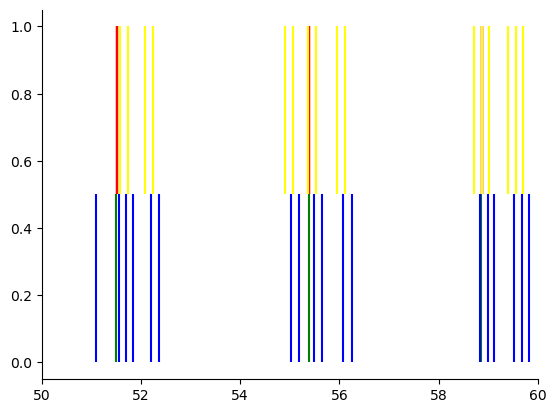

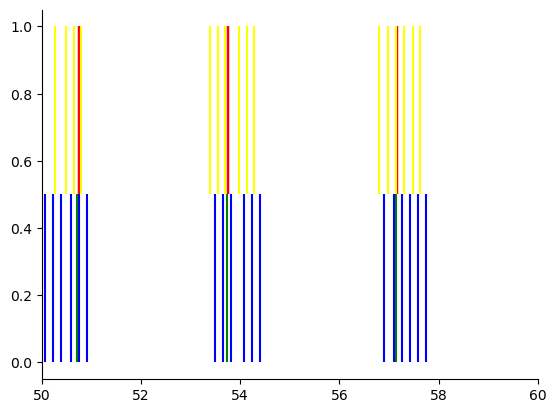

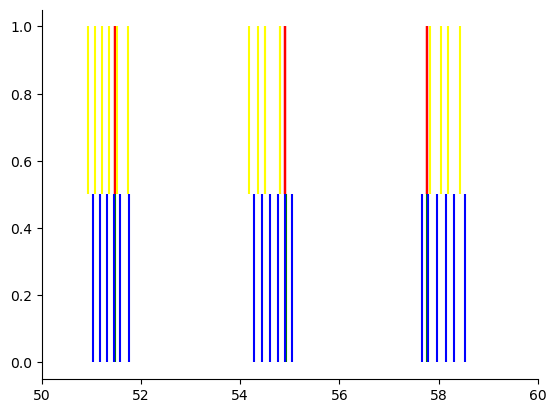

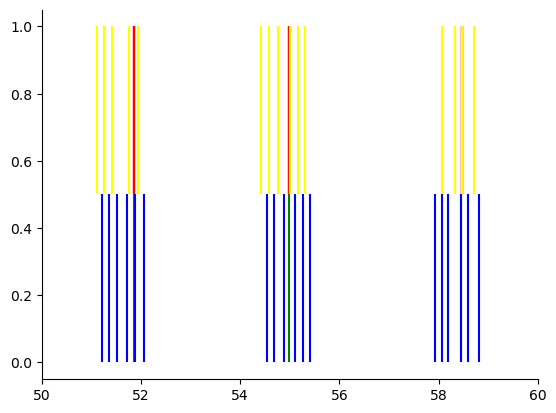

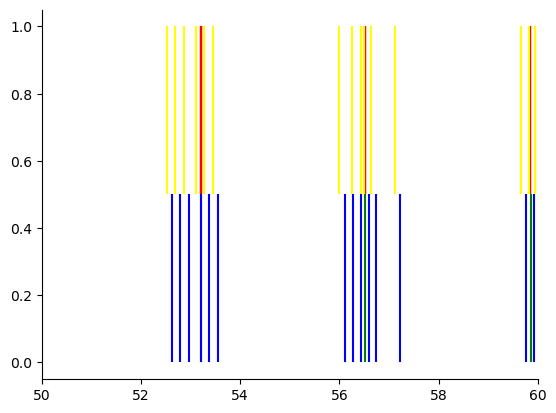

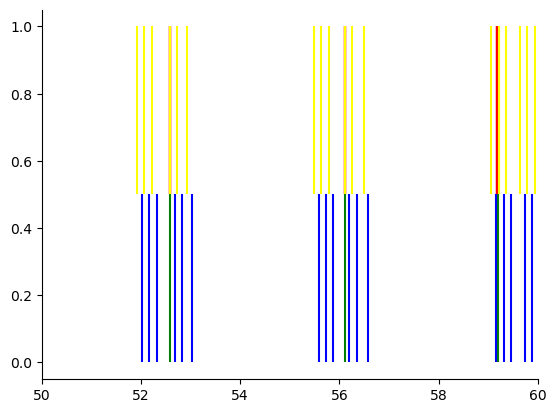

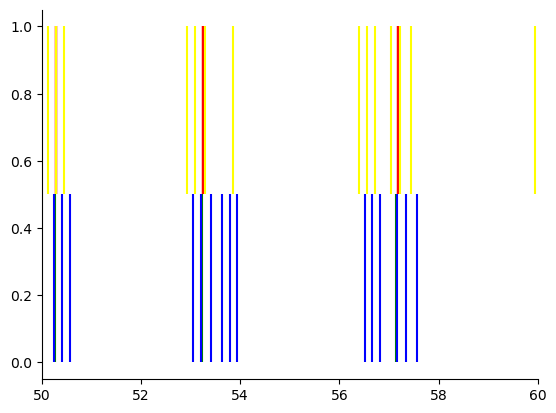

P02 B2


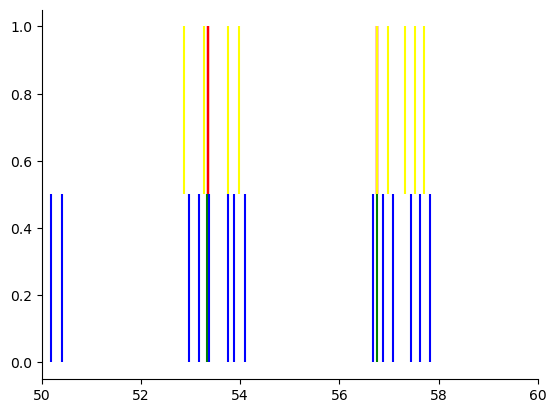

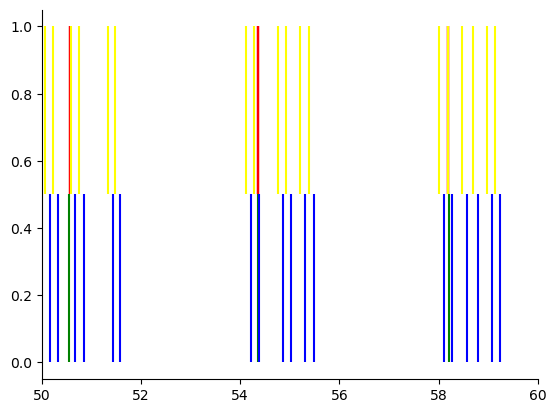

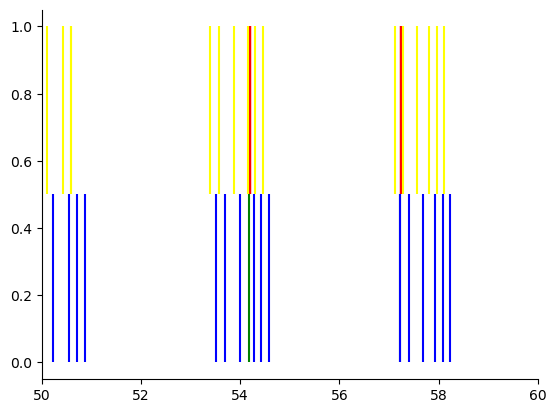

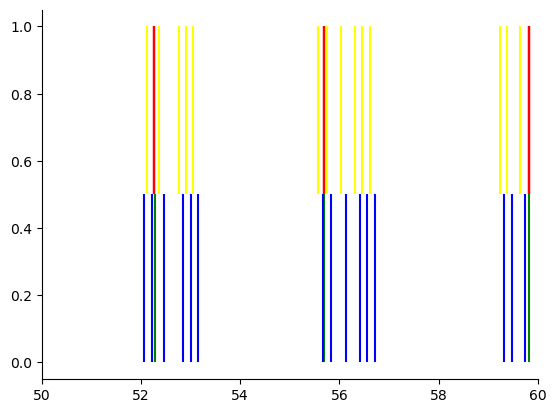

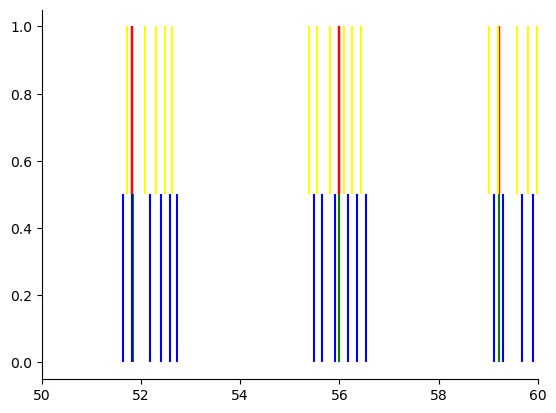

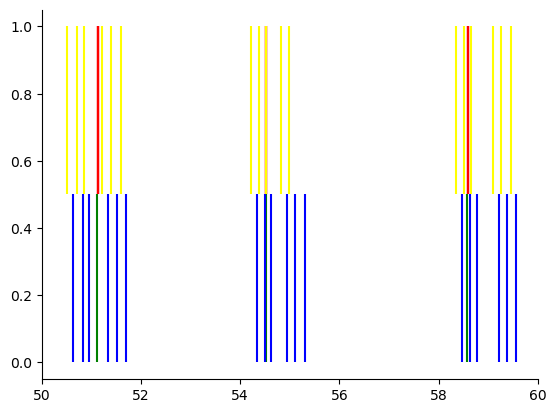

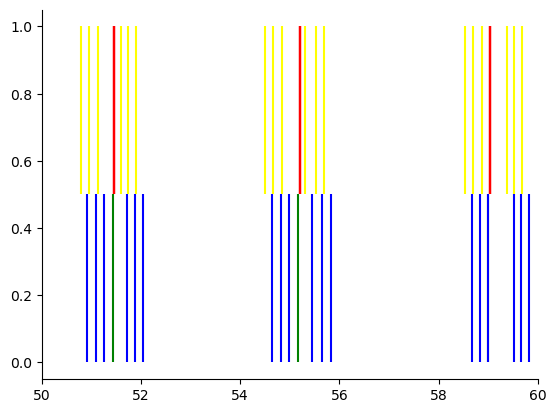

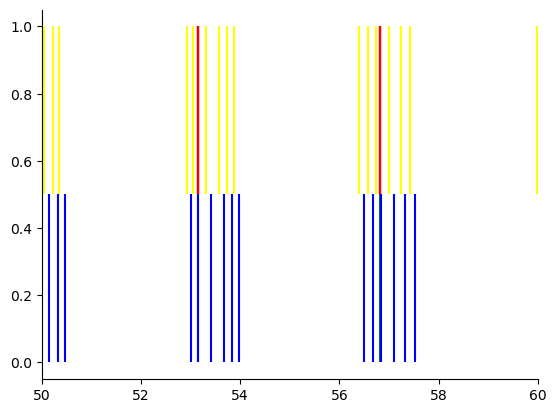

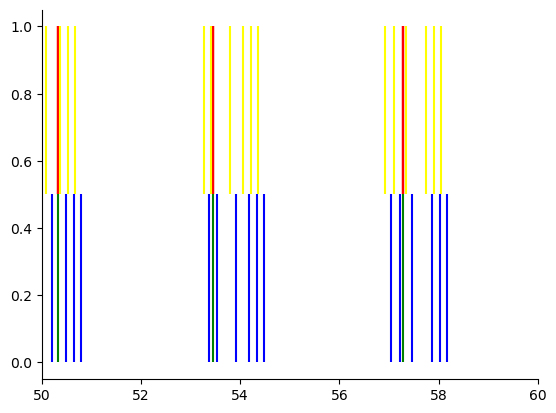

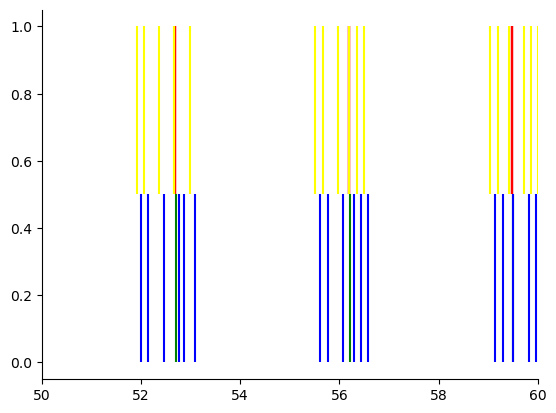

P03 B1


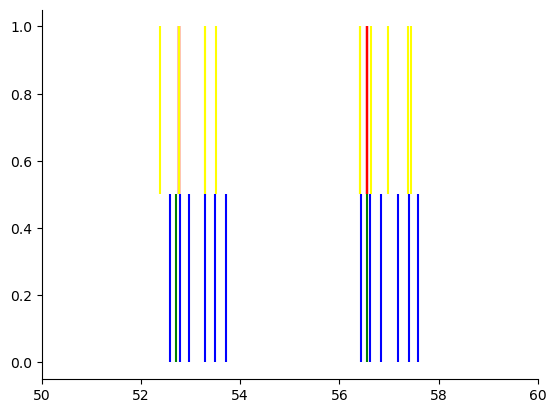

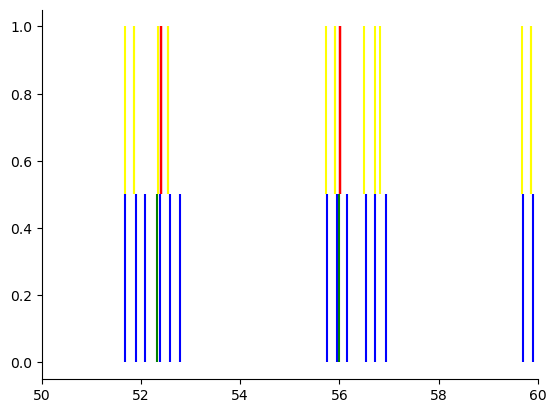

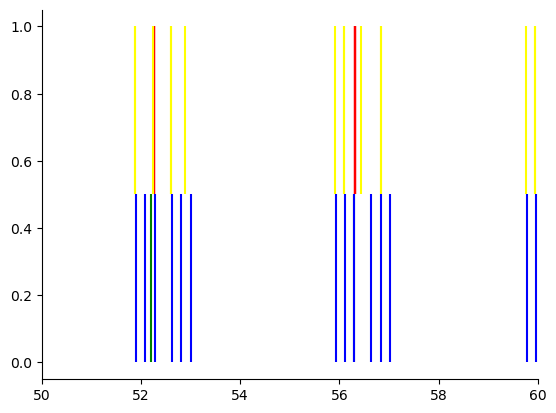

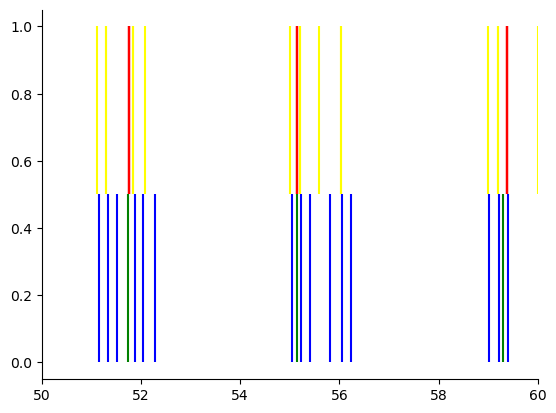

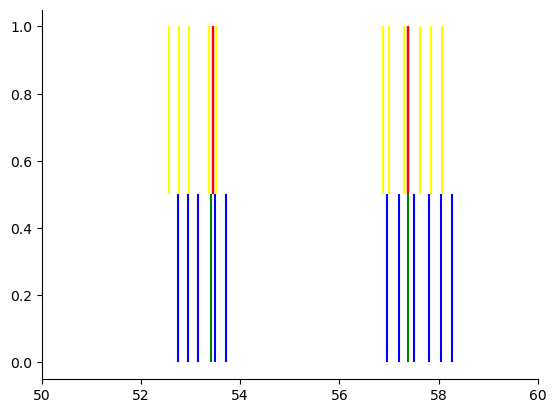

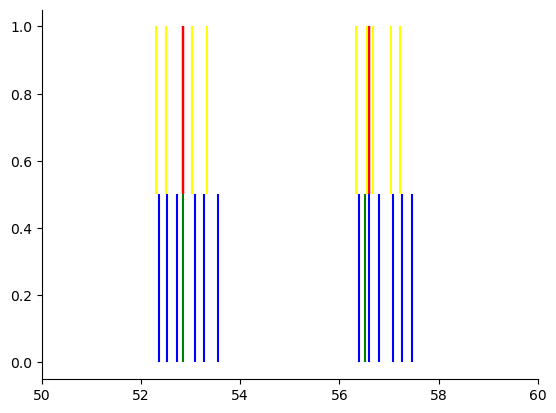

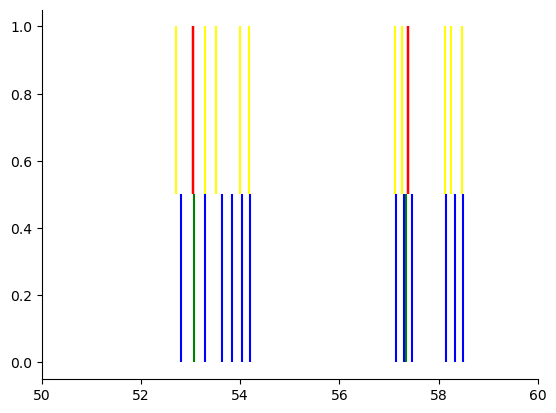

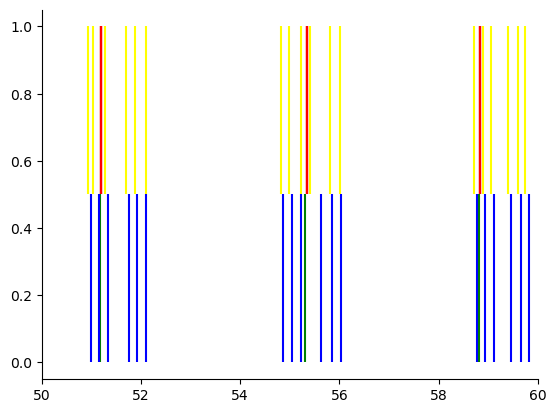

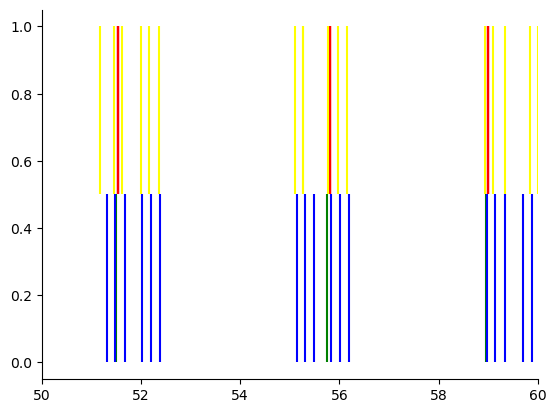

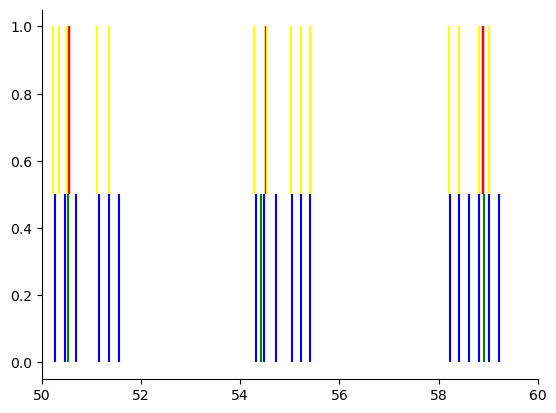

P03 B2


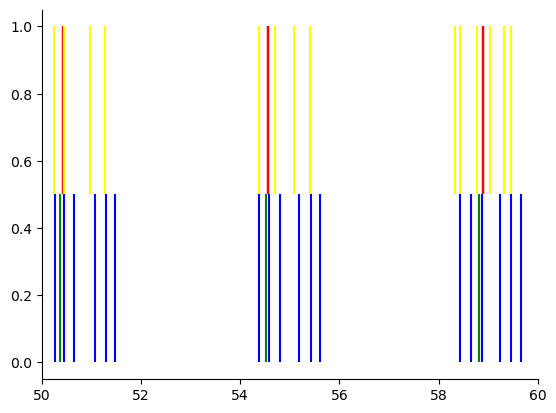

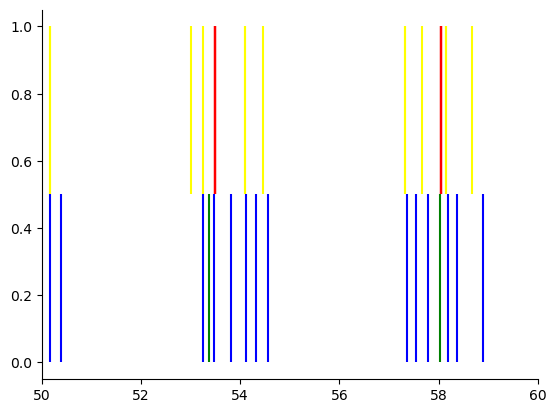

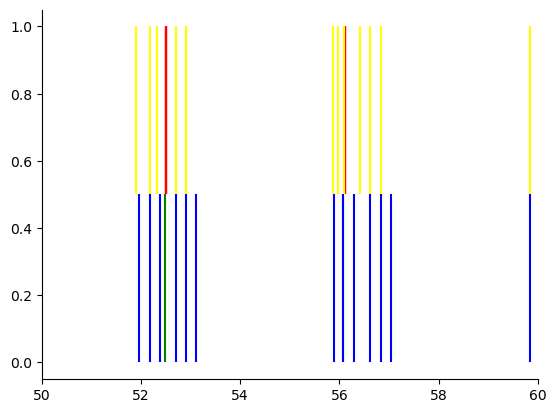

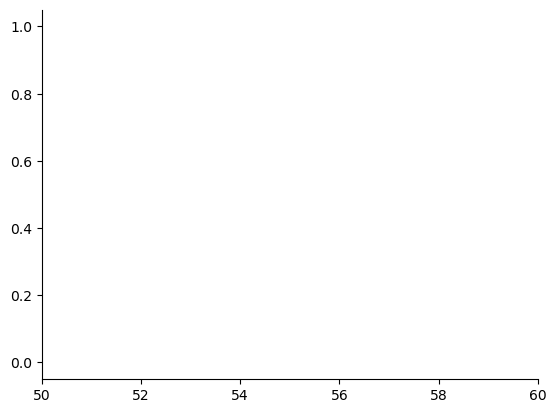

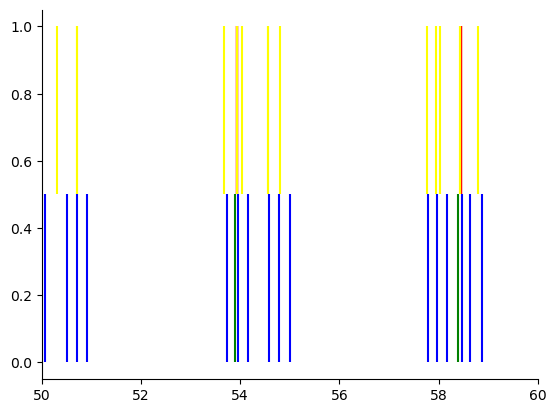

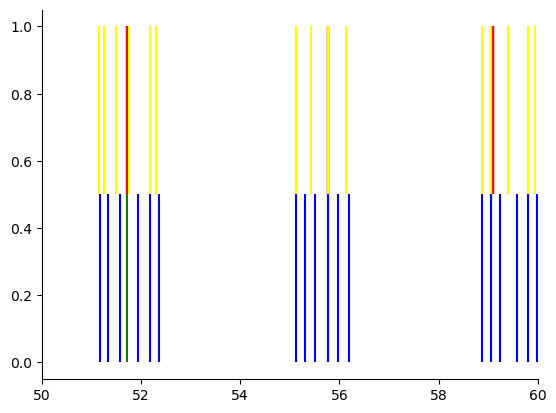

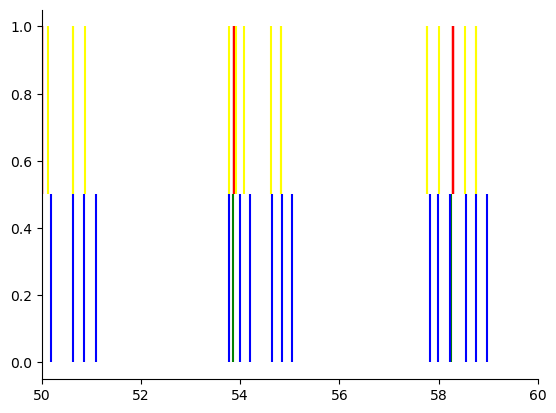

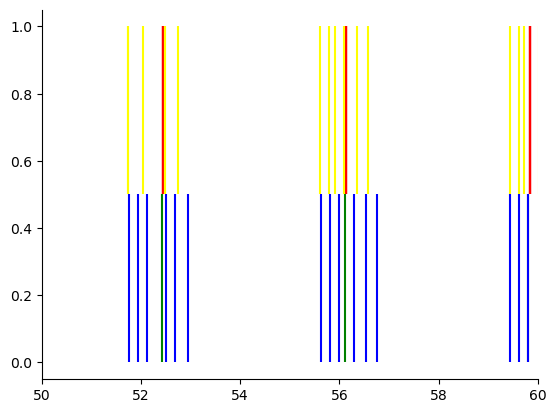

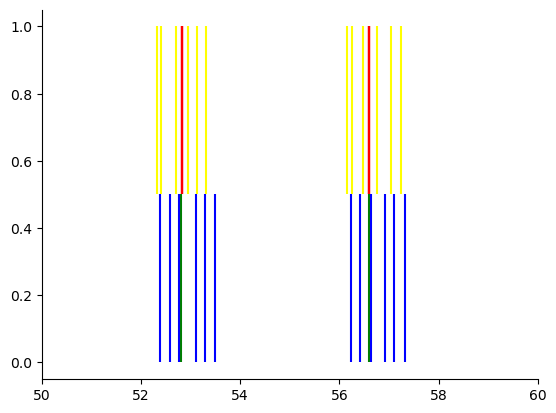

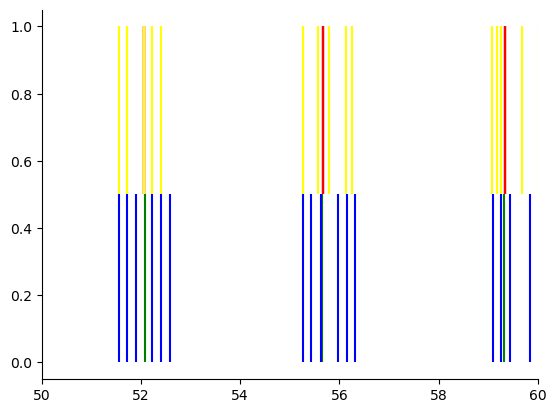

P04 B1


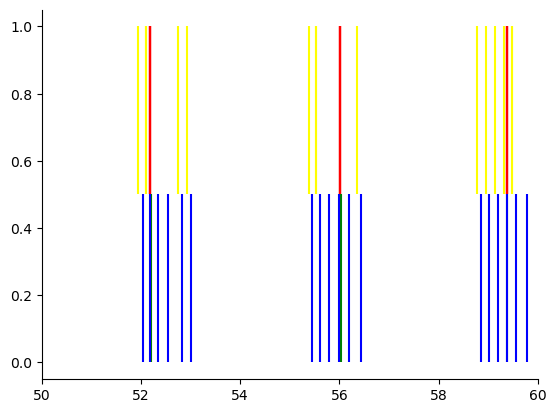

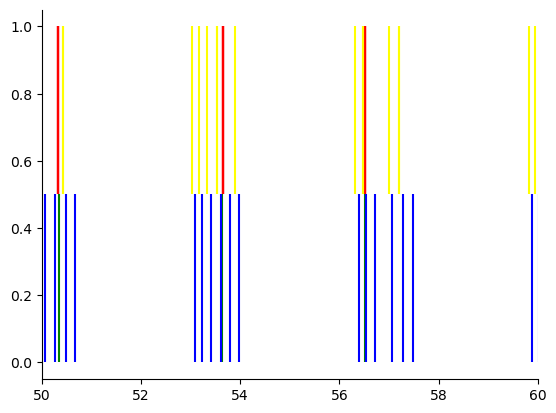

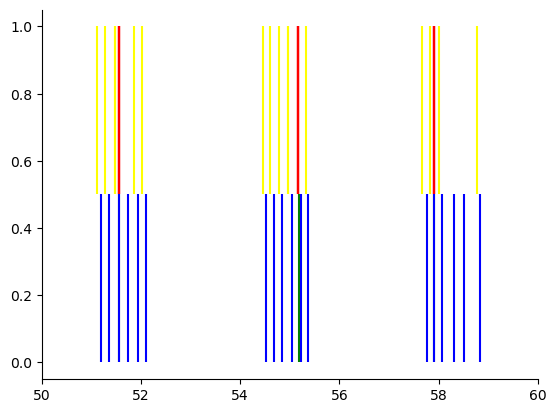

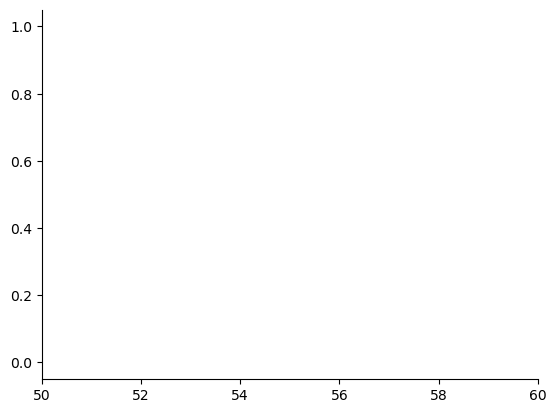

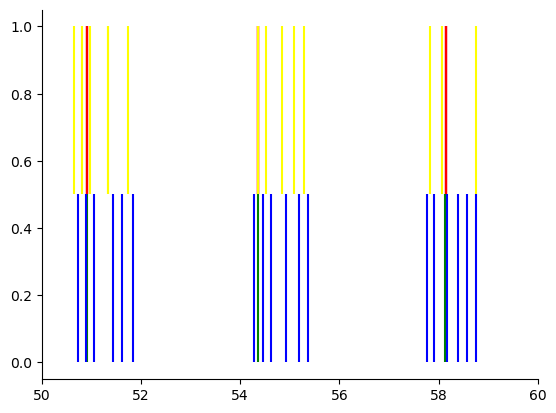

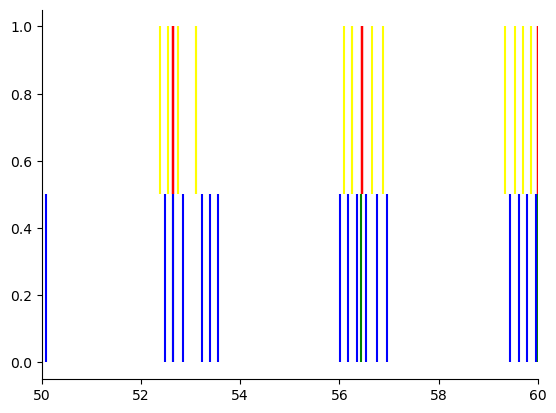

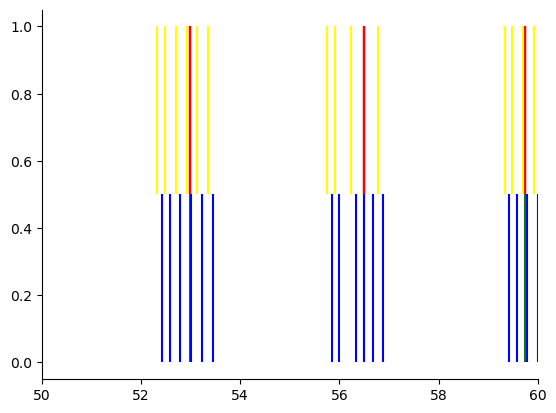

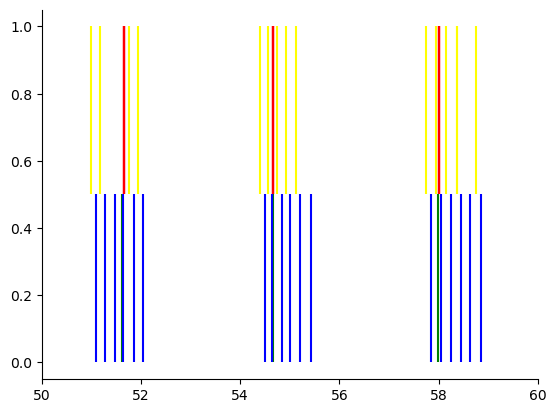

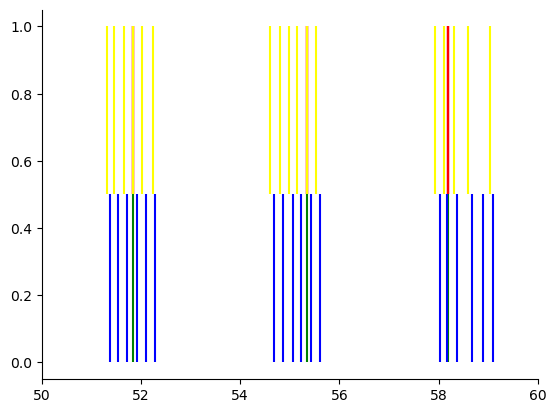

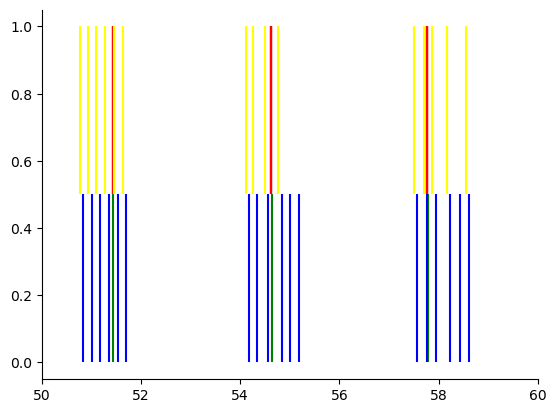

P04 B2


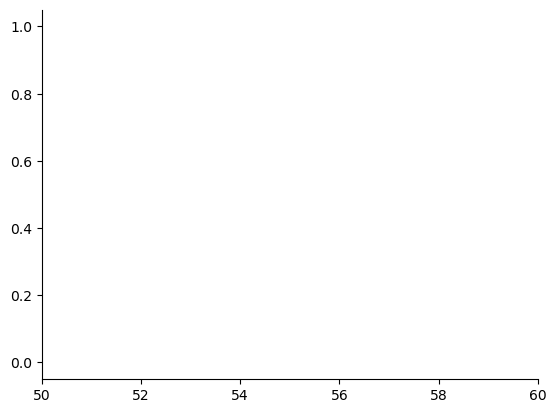

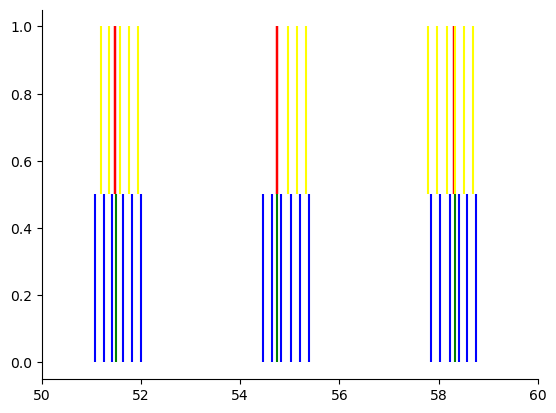

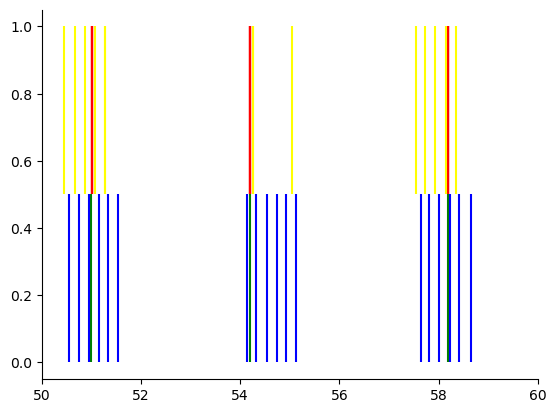

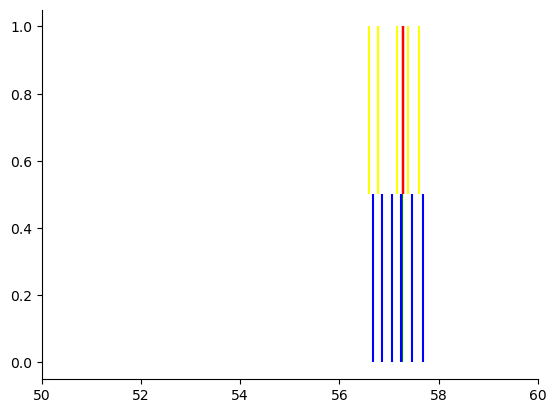

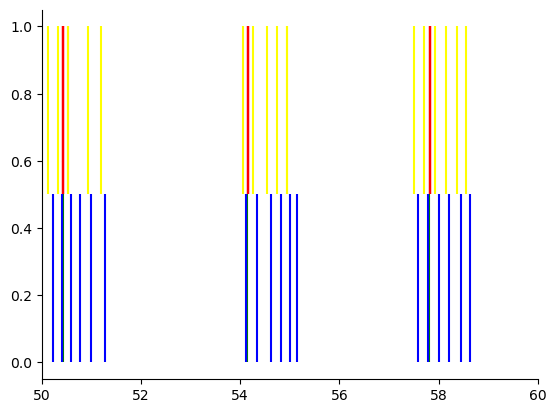

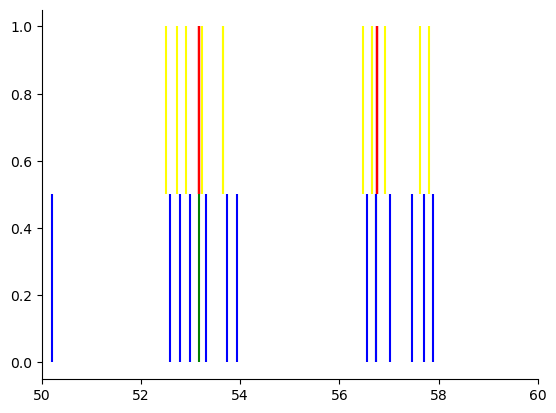

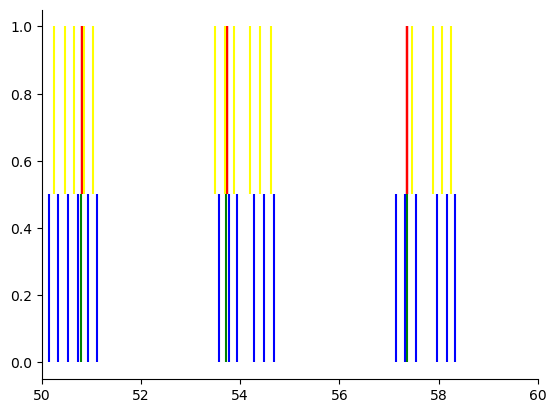

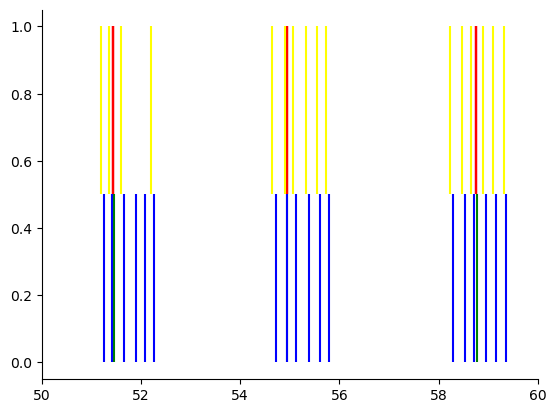

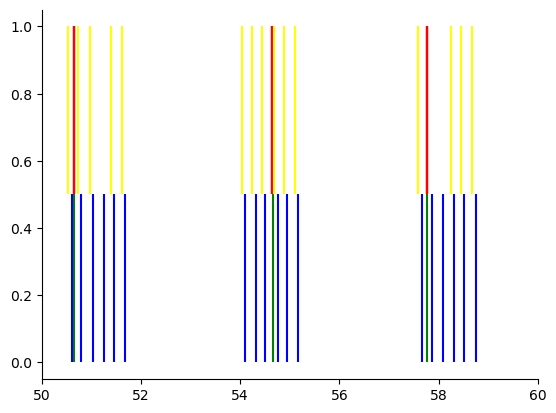

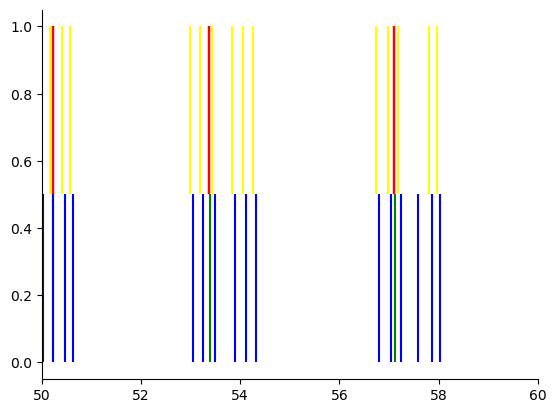

P05 B1


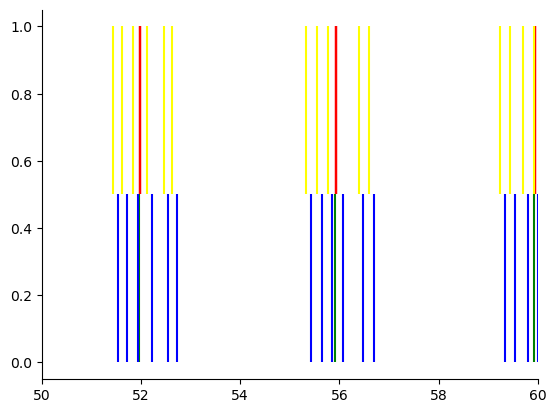

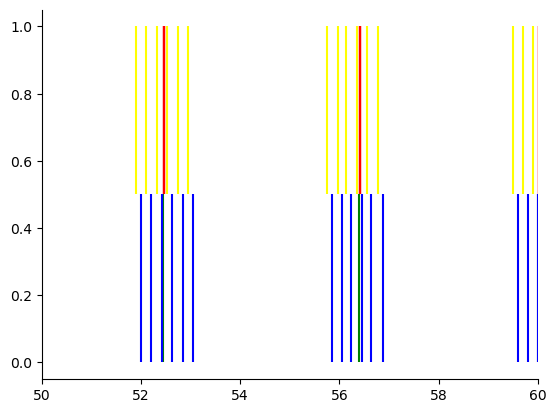

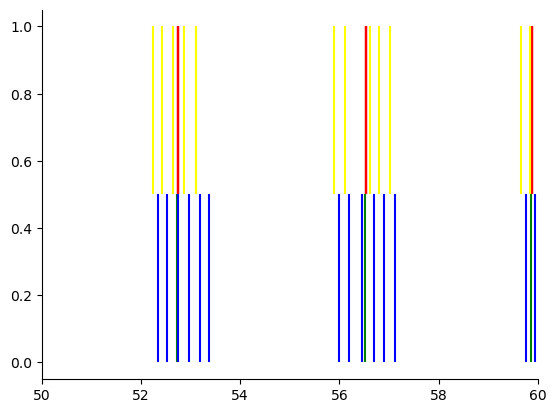

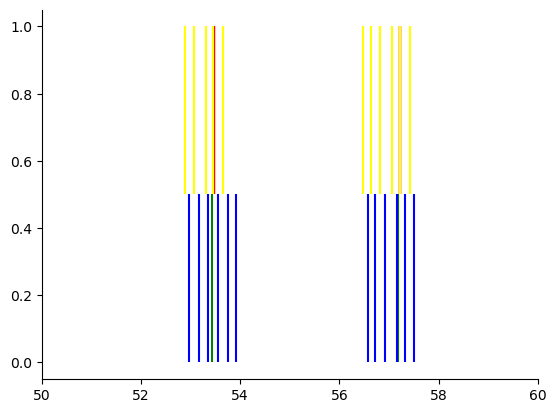

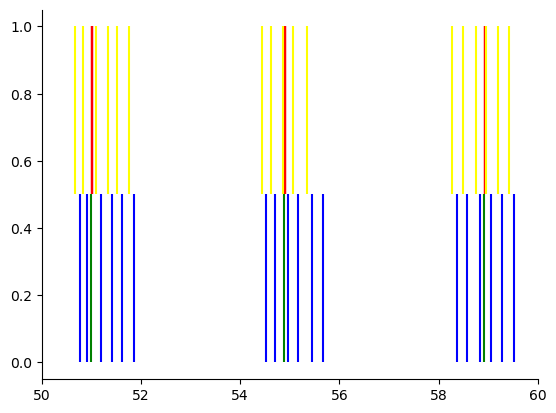

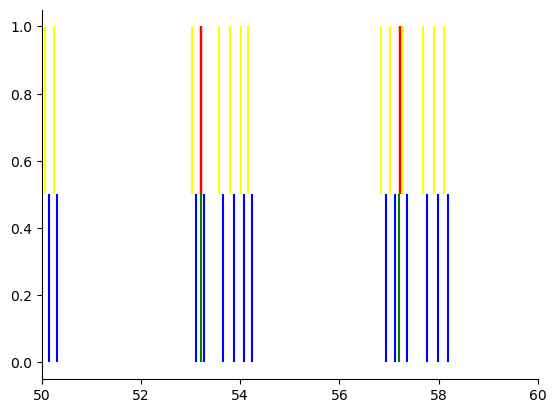

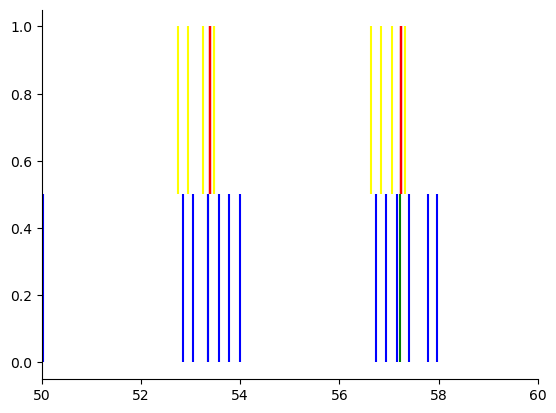

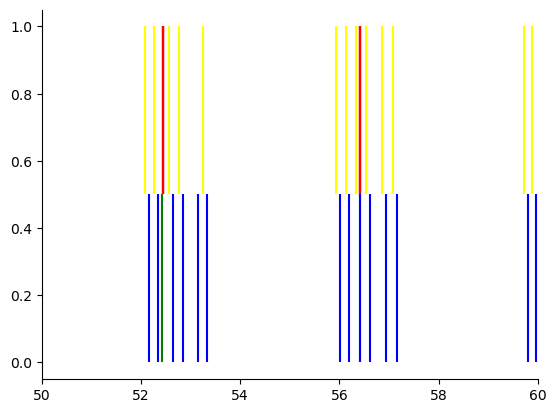

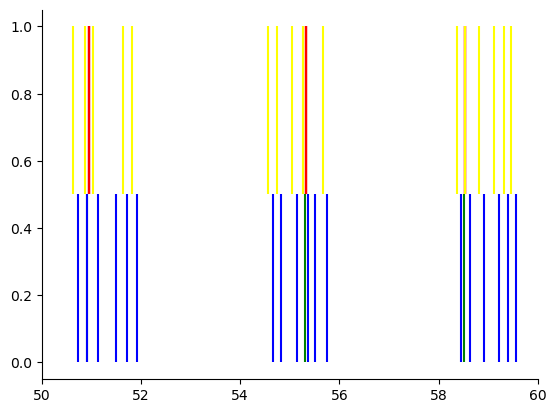

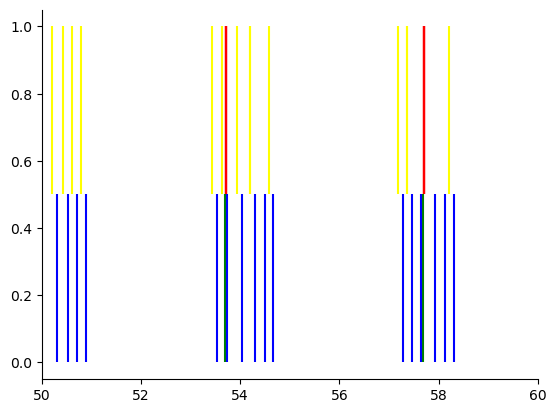

P05 B2


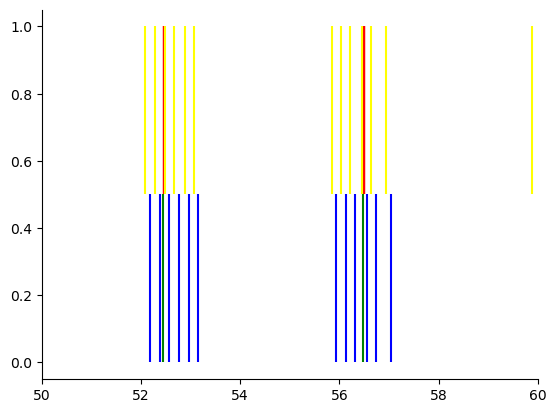

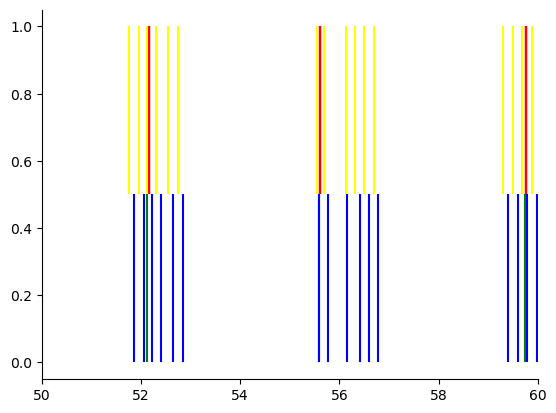

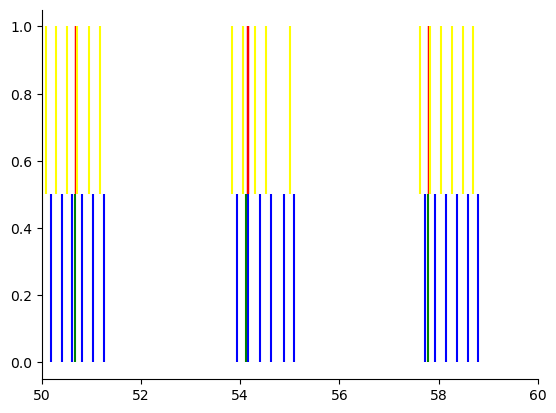

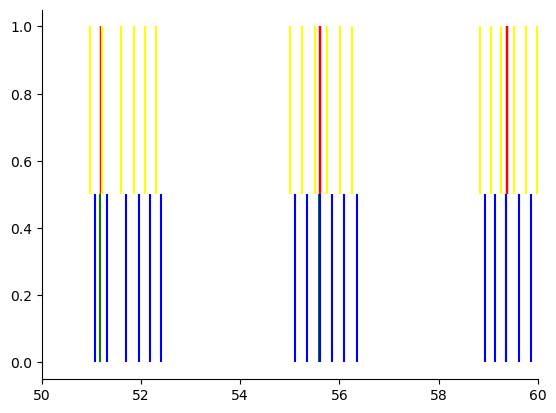

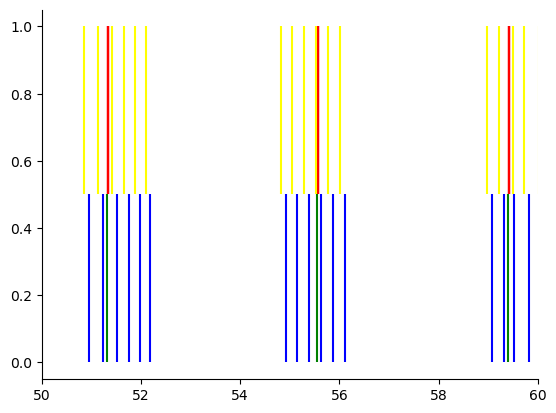

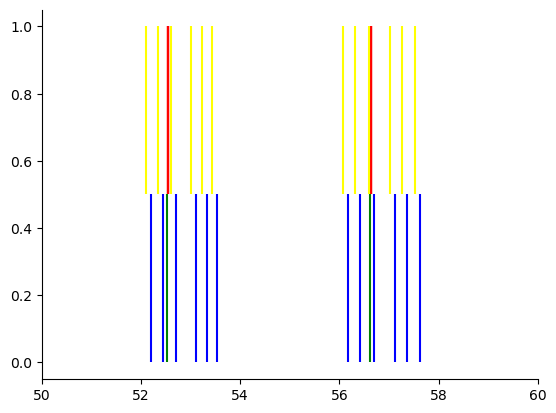

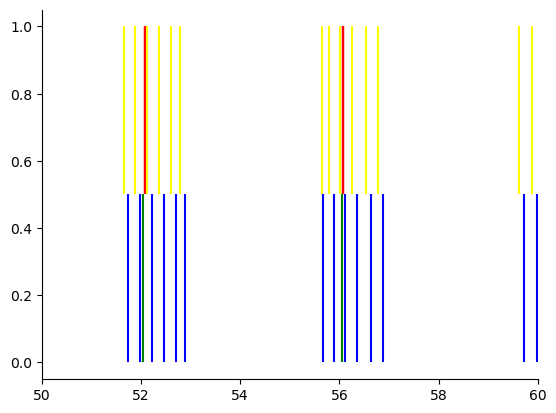

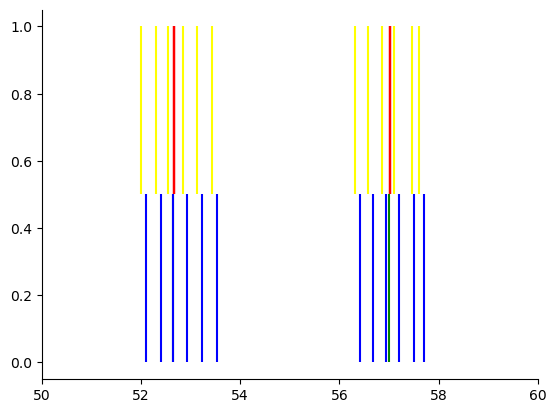

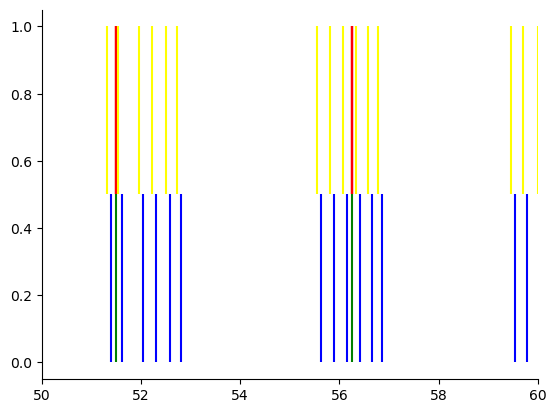

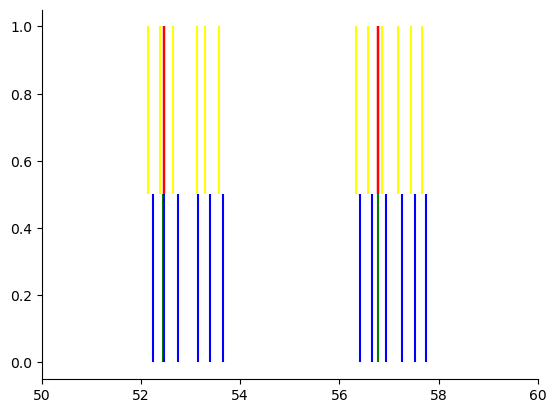

P06 B1
P06 B2
P07 B1


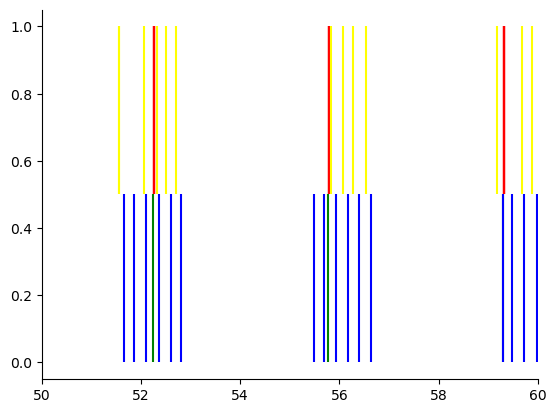

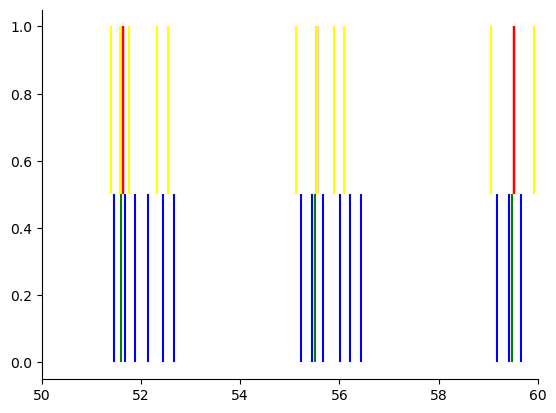

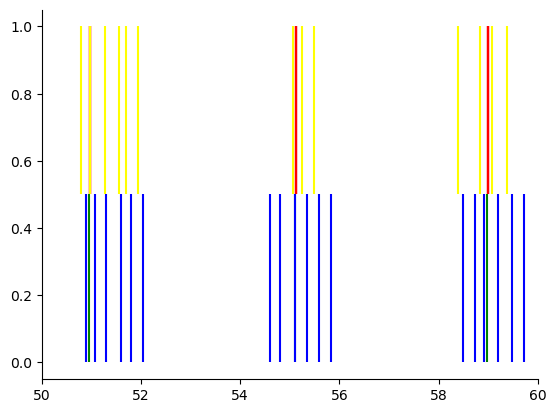

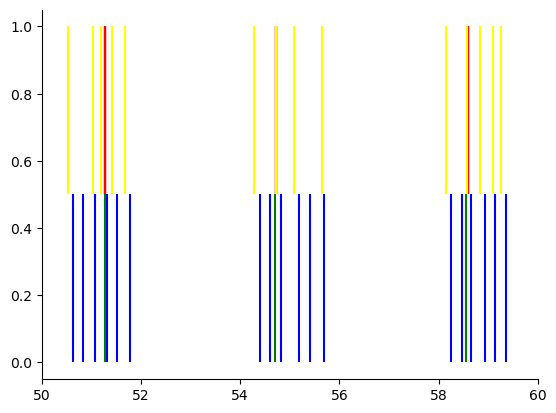

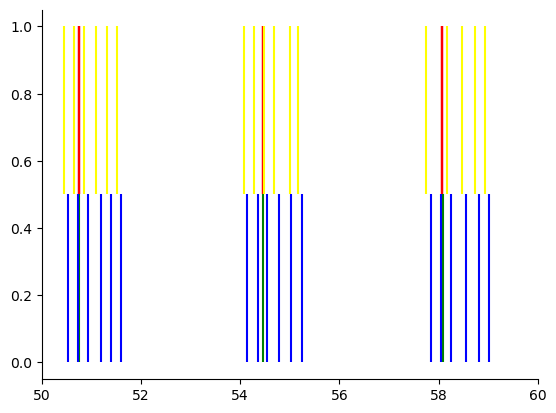

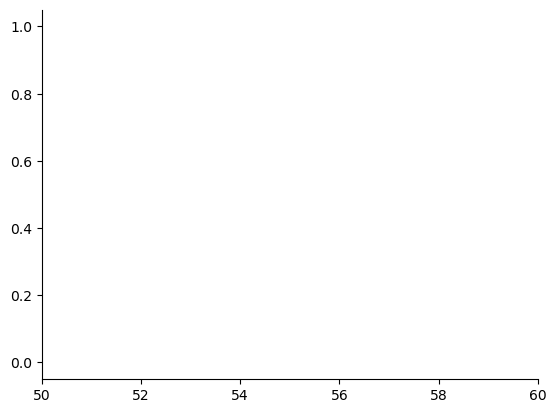

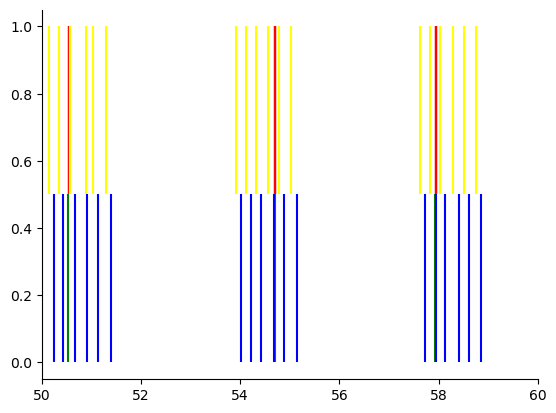

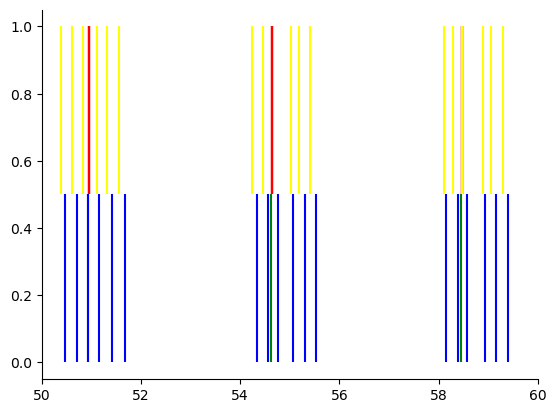

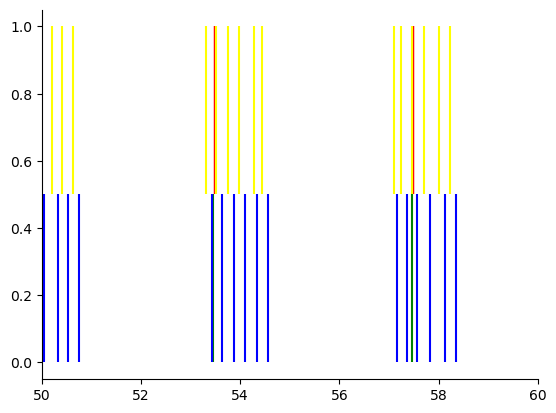

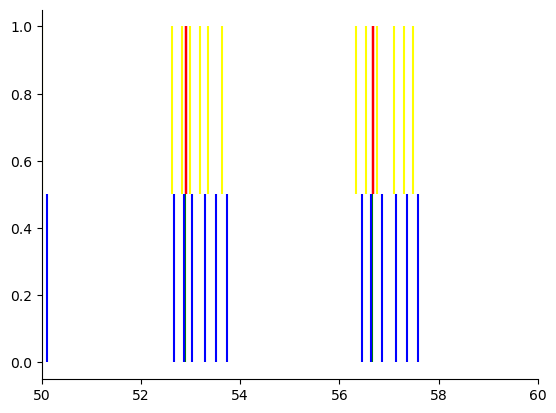

P07 B2


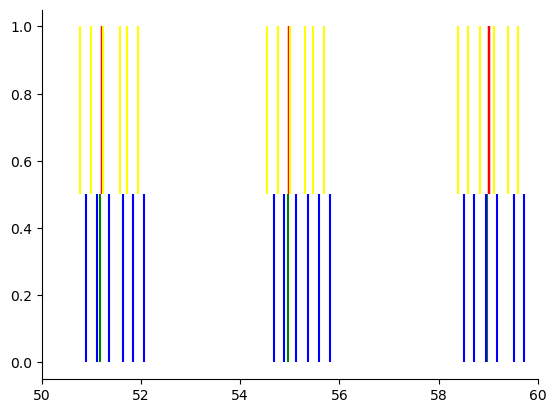

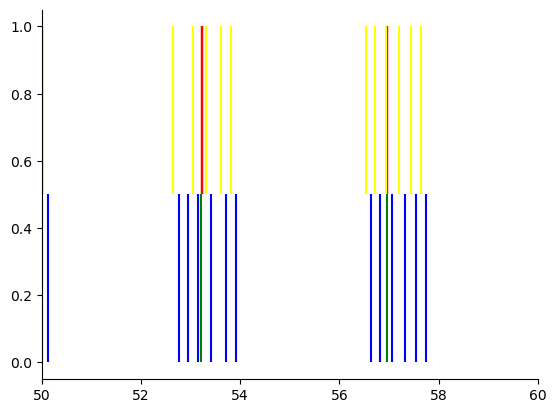

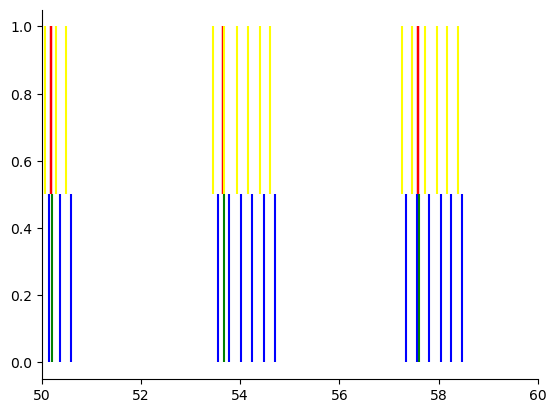

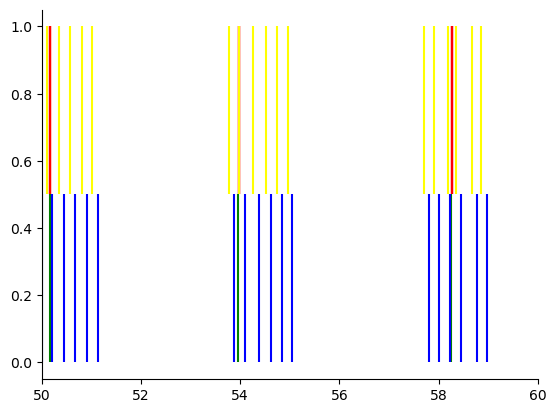

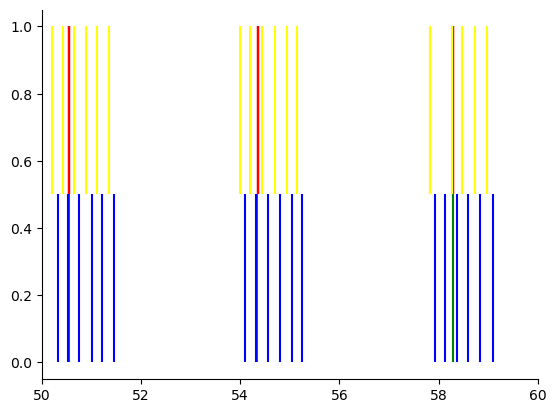

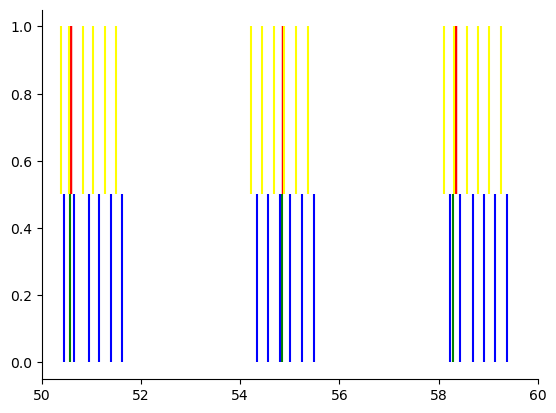

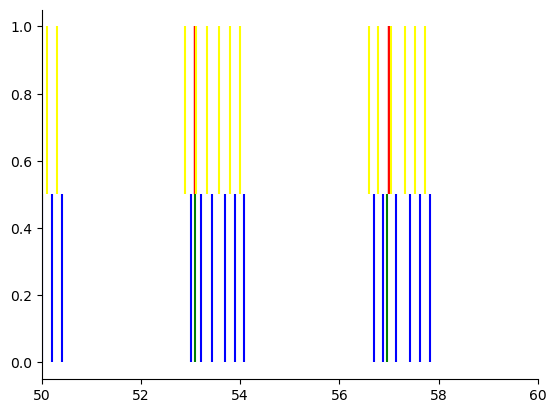

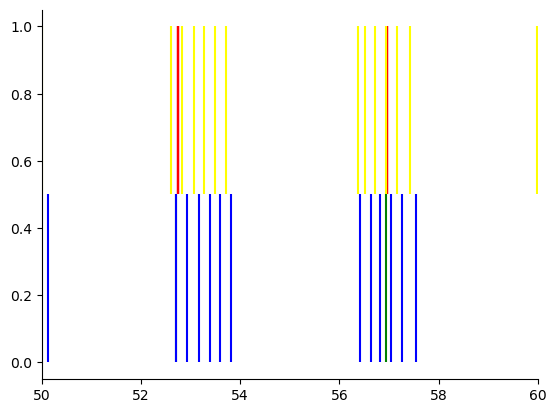

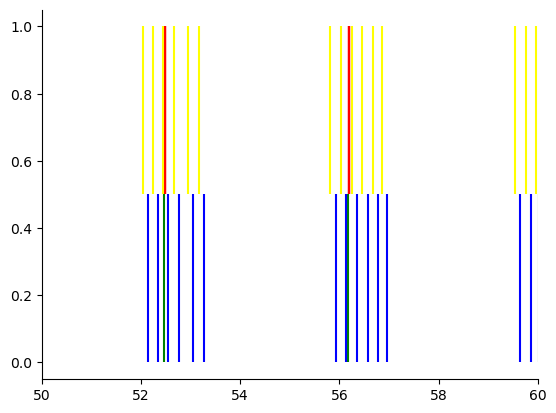

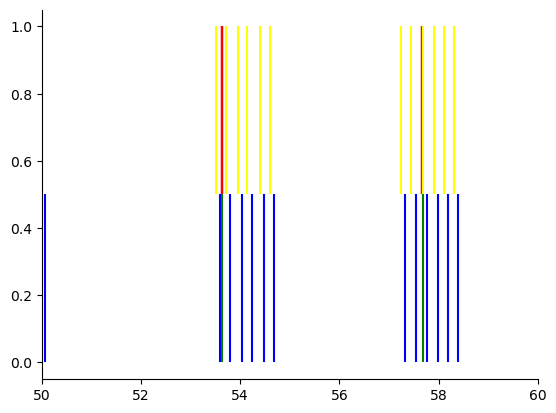

P08 B1


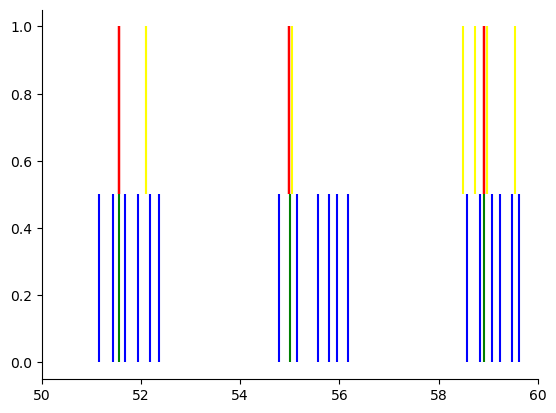

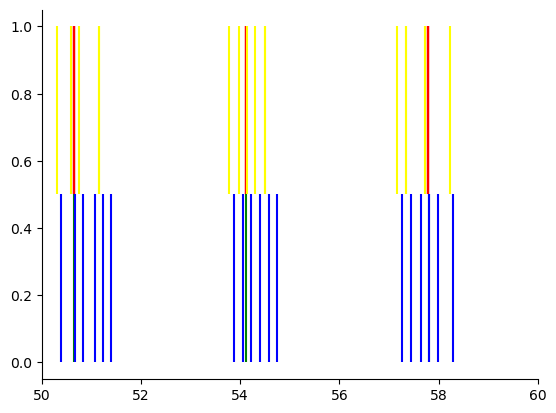

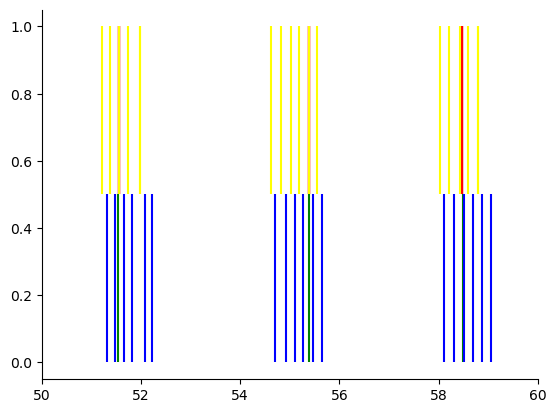

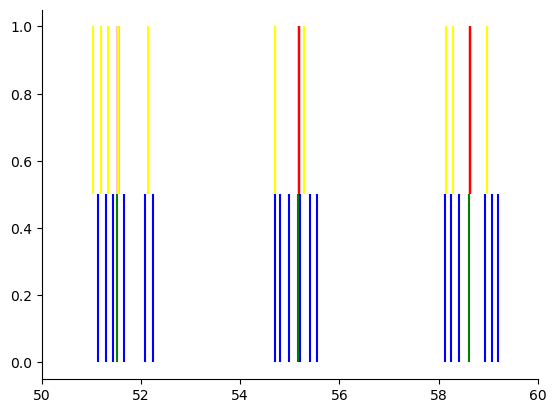

P08 B2


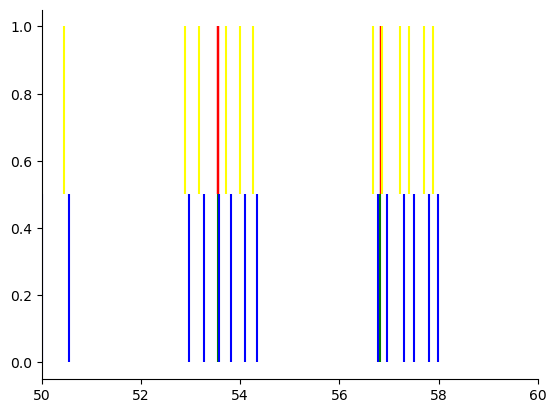

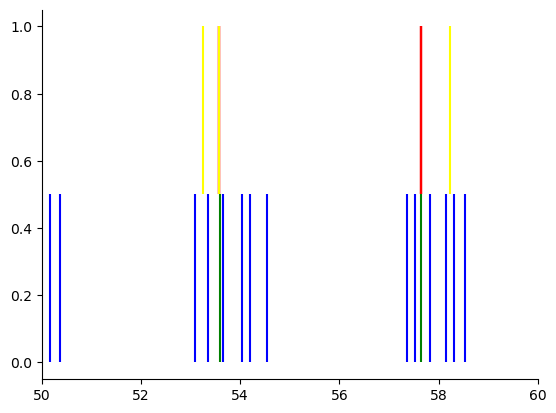

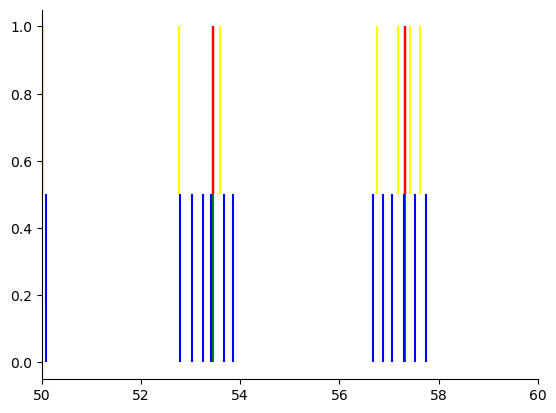

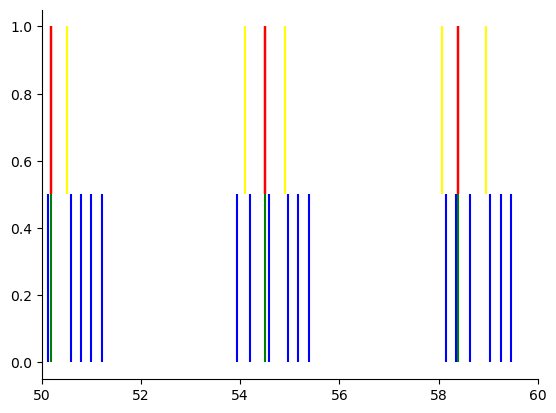

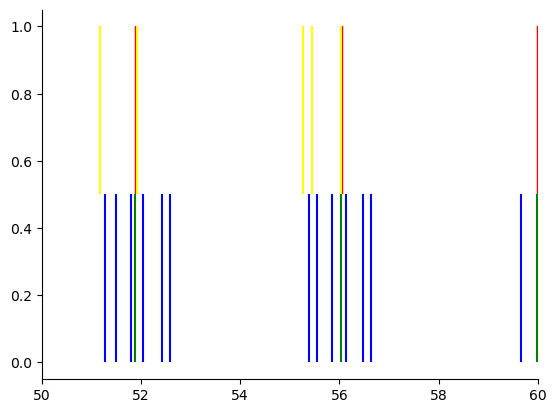

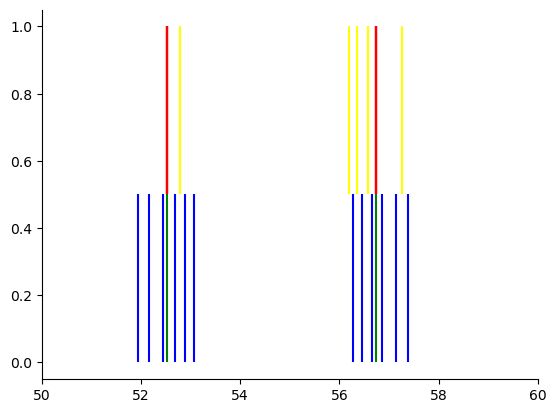

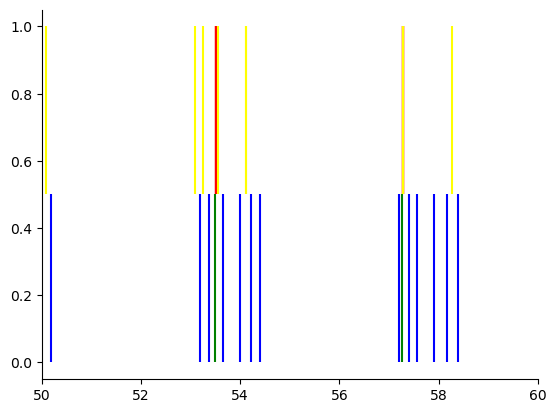

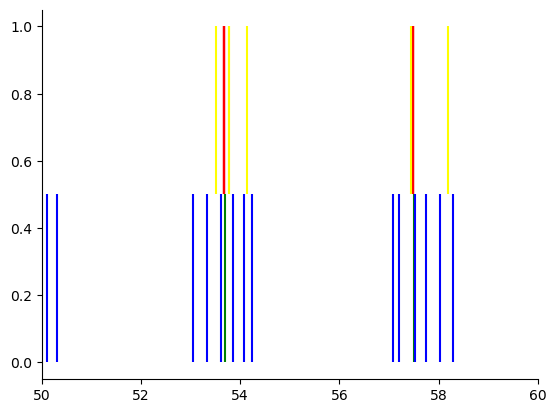

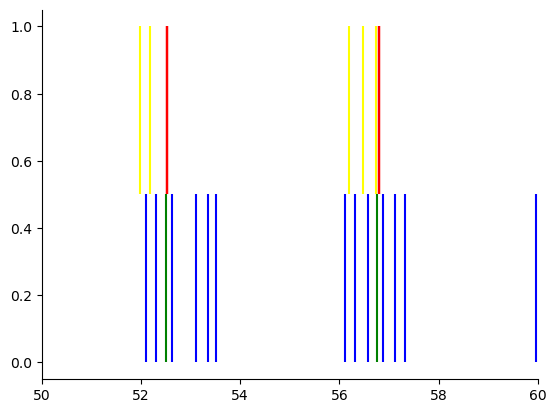

P09 B1


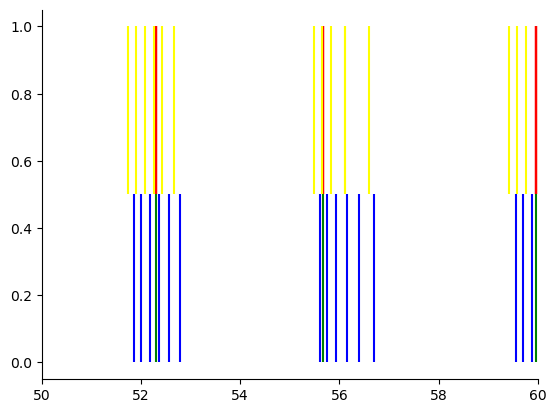

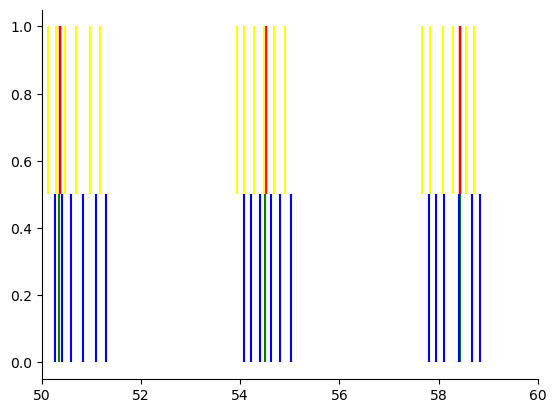

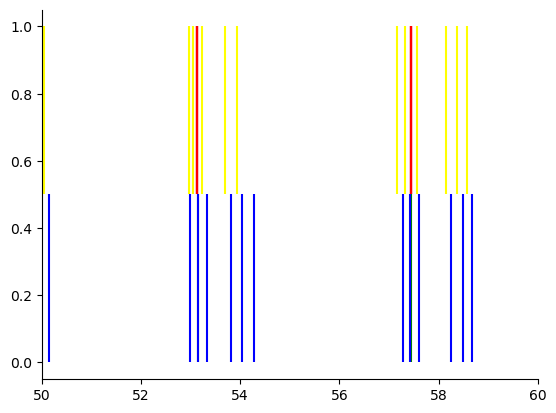

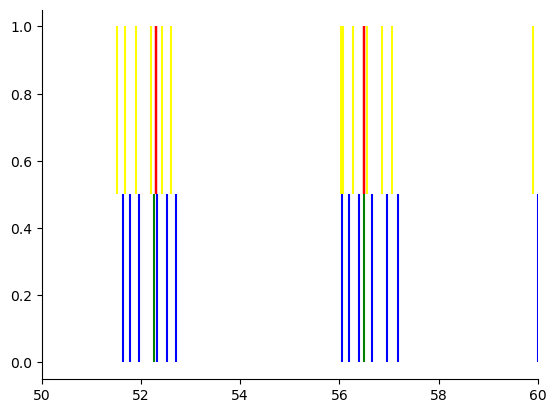

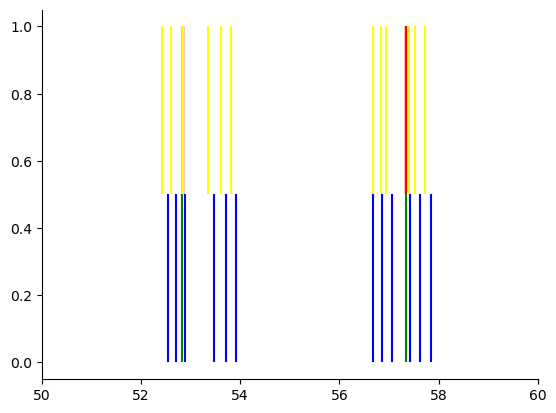

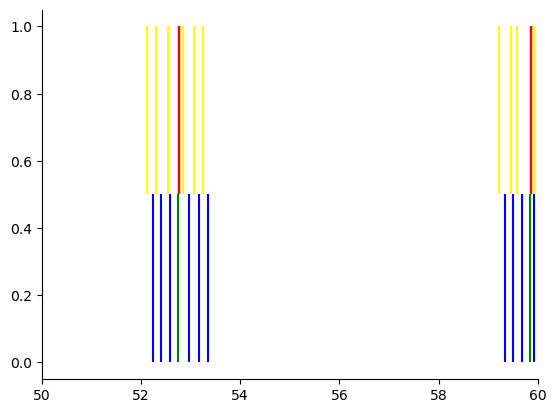

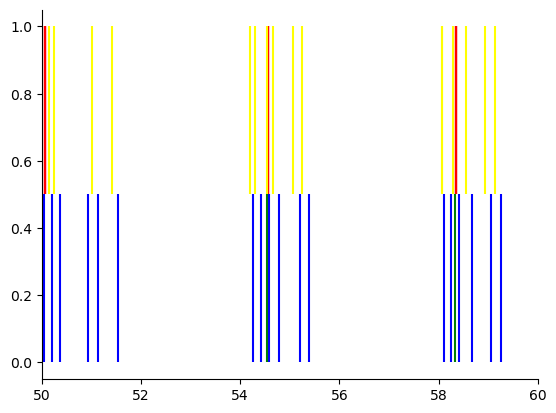

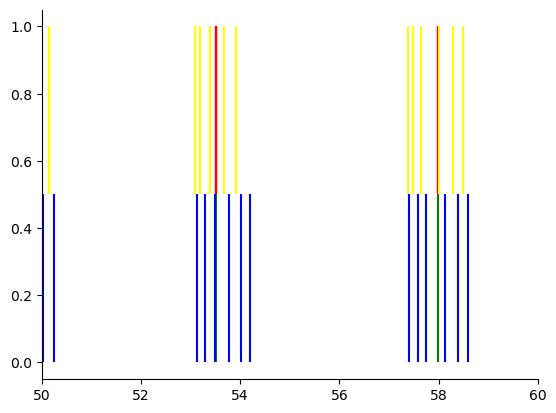

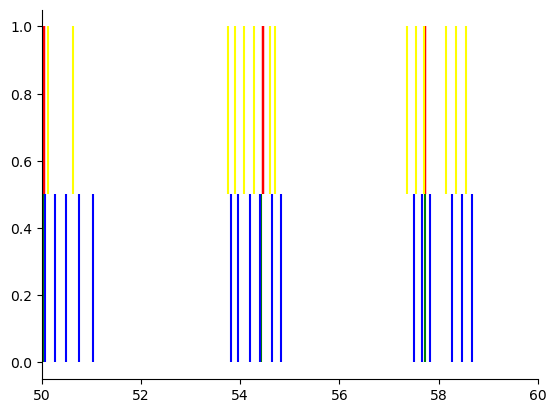

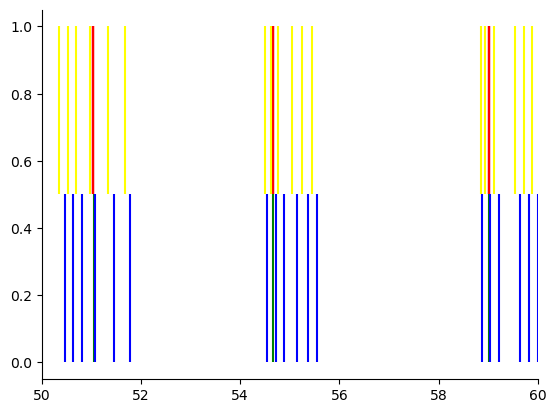

P09 B2


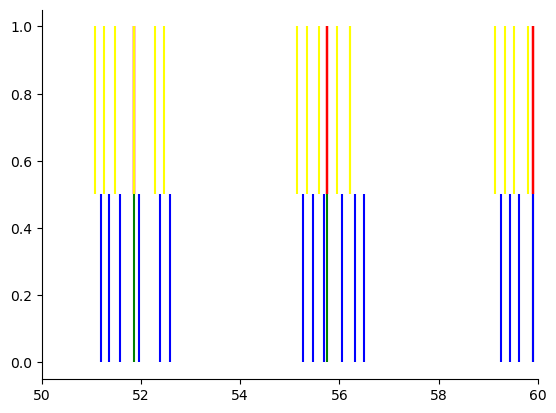

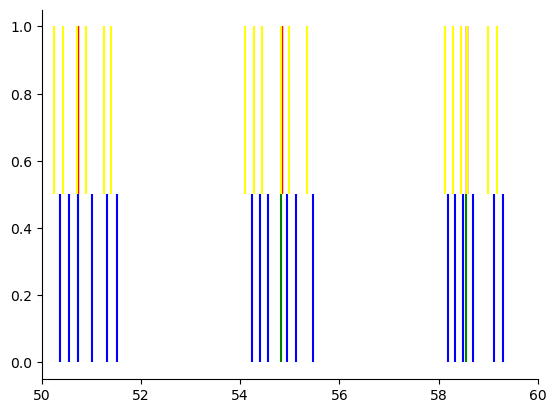

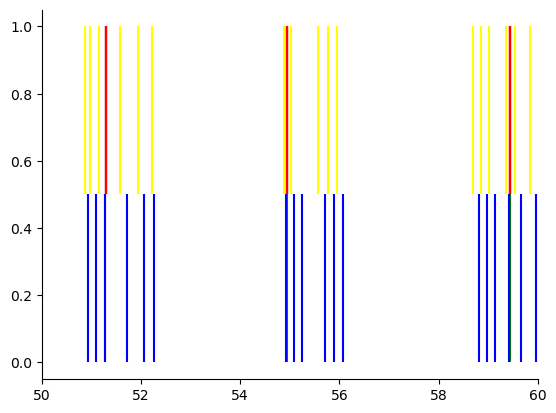

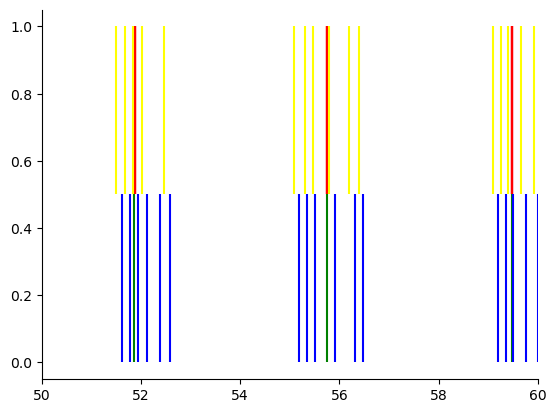

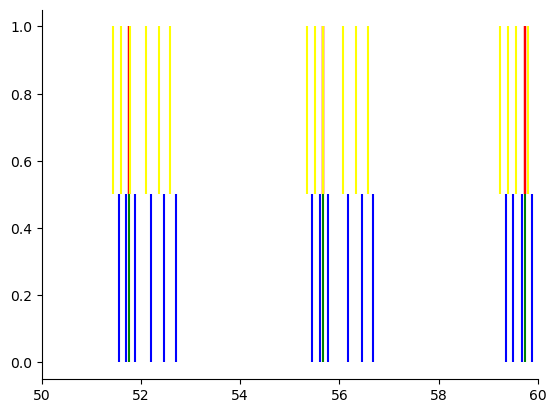

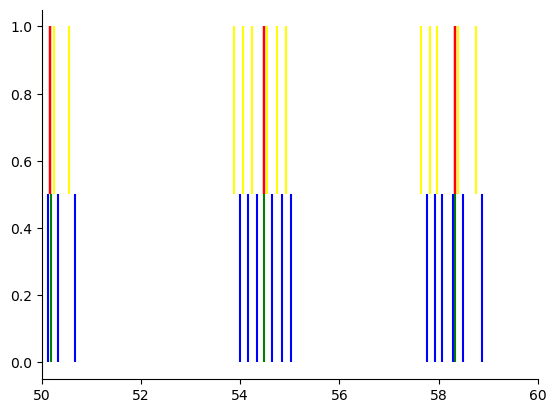

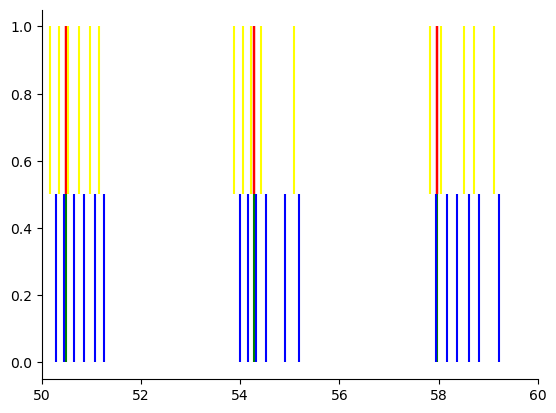

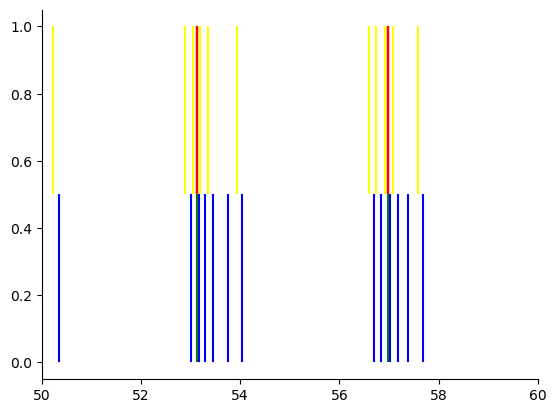

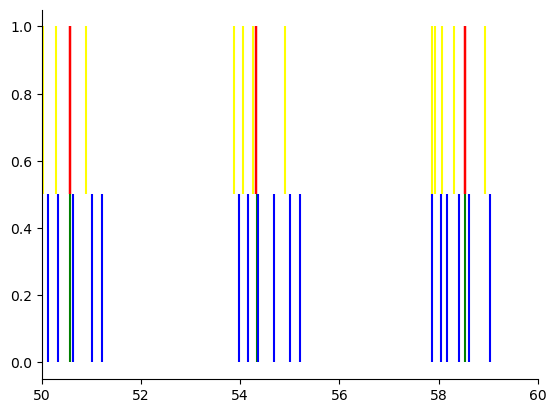

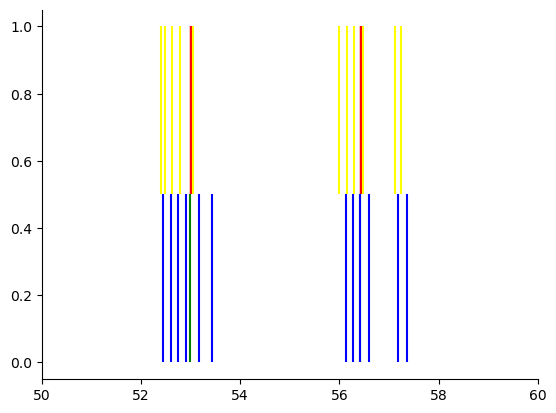

P10 B1


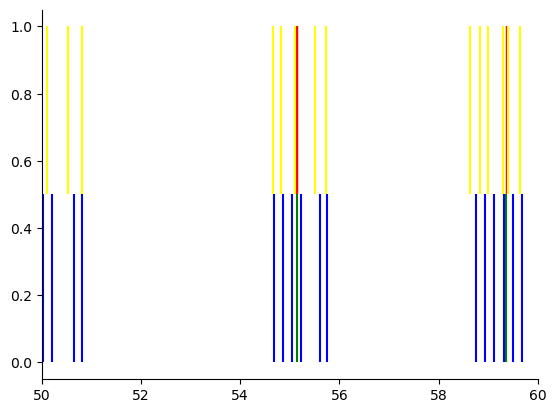

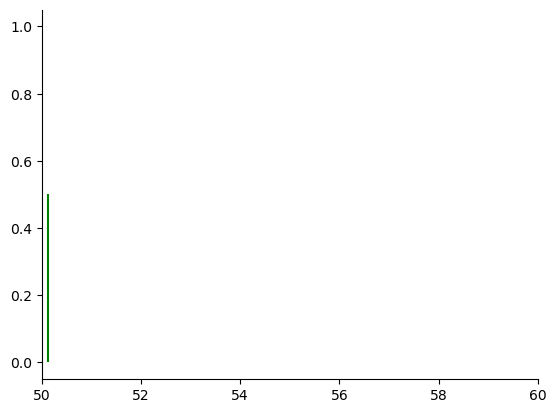

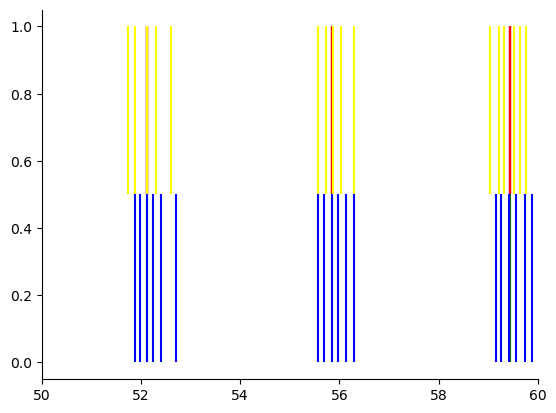

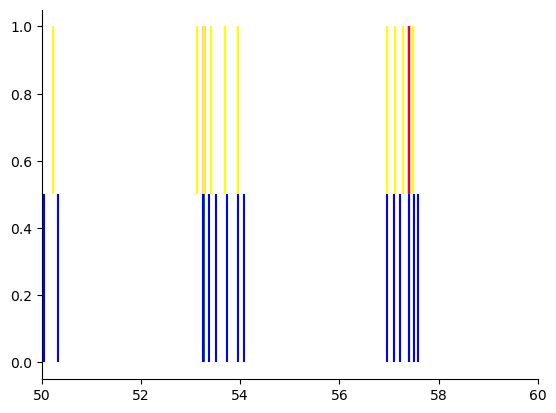

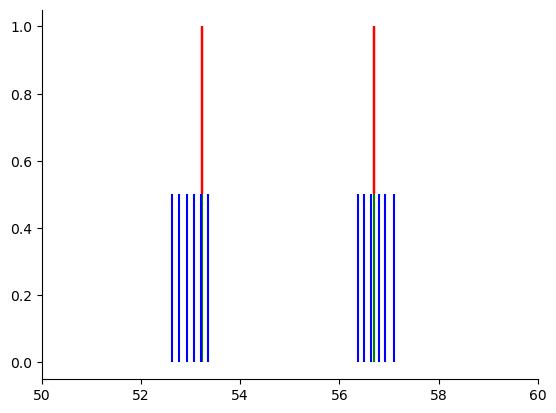

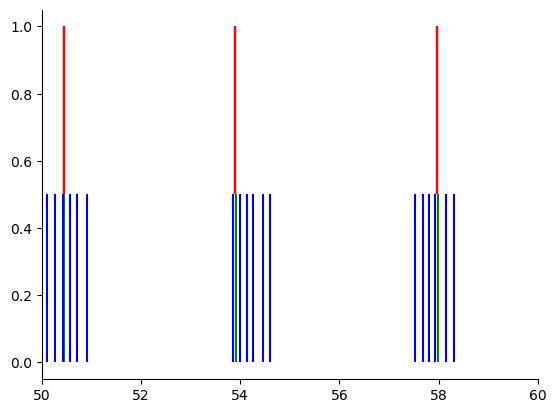

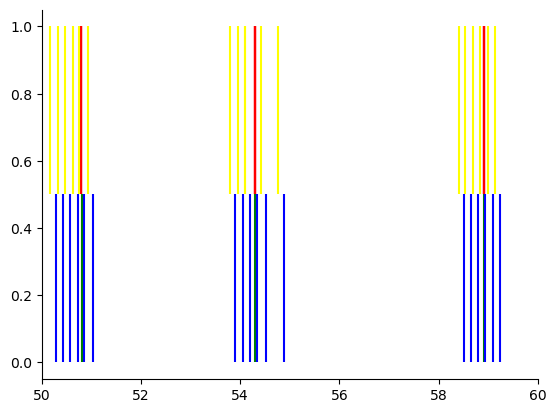

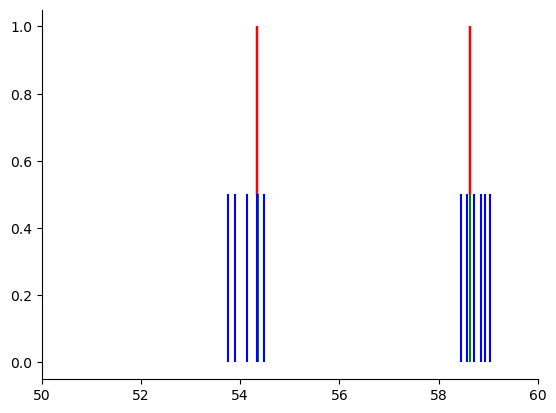

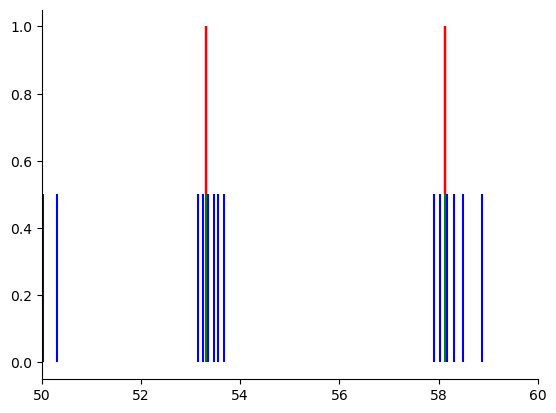

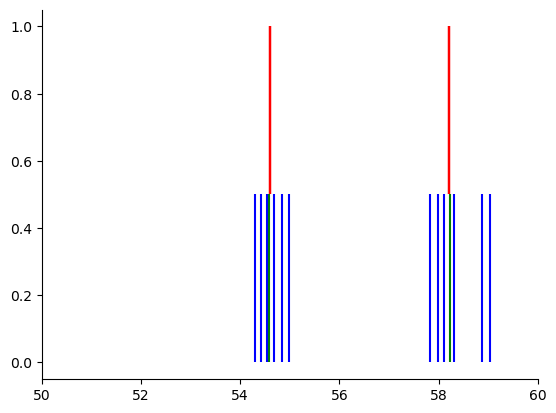

P10 B2
P11 B1


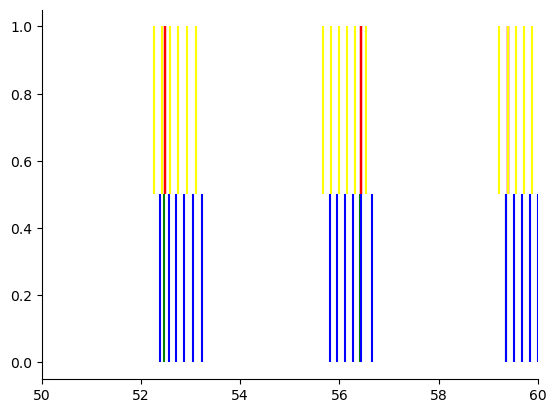

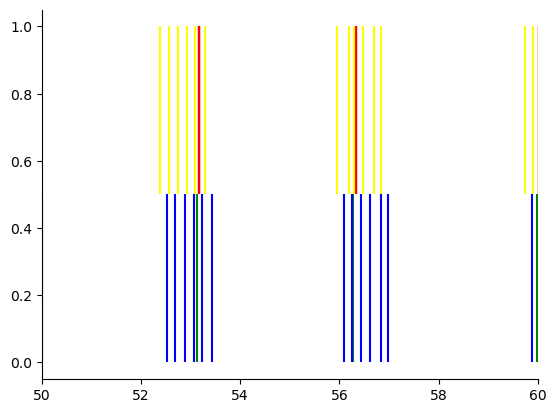

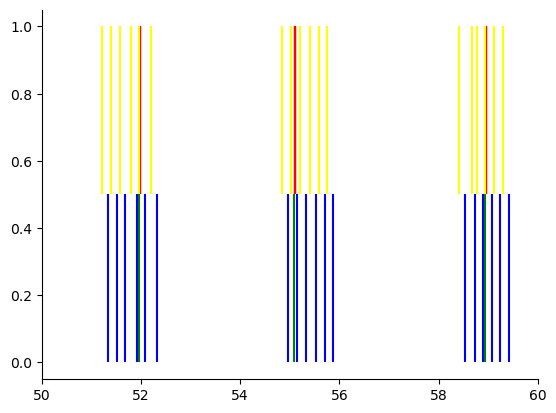

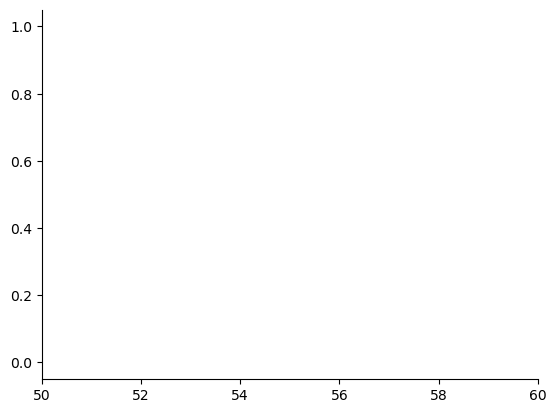

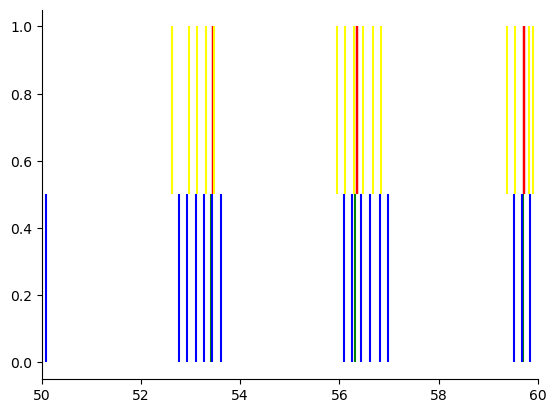

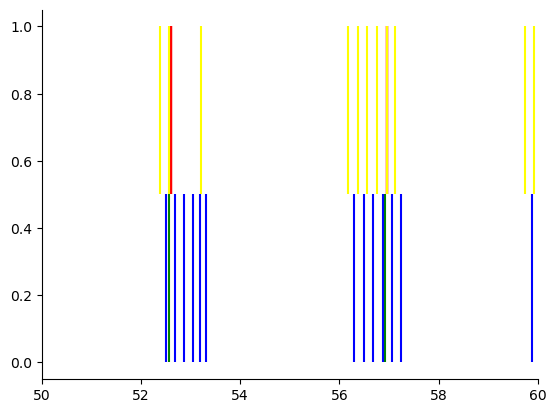

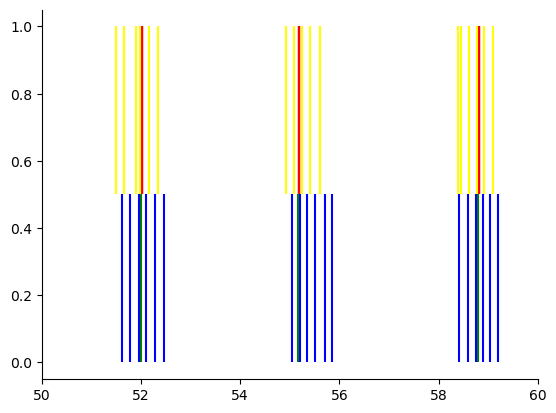

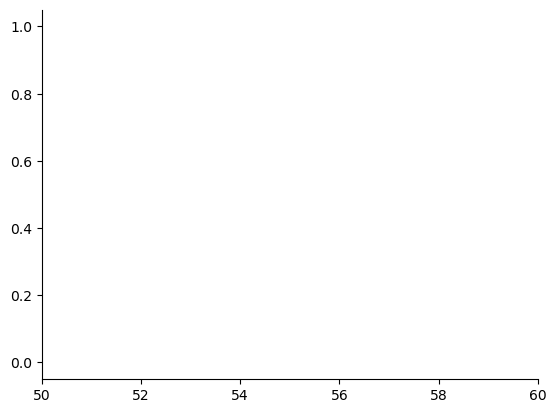

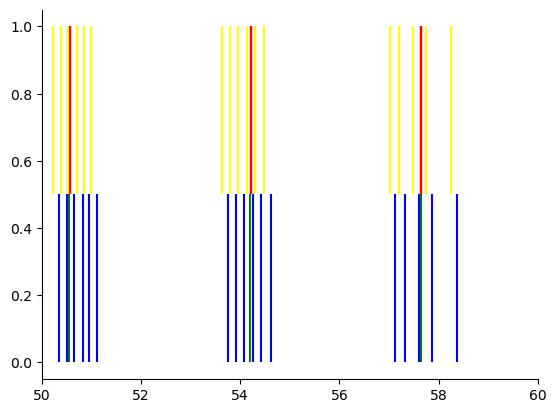

P11 B2


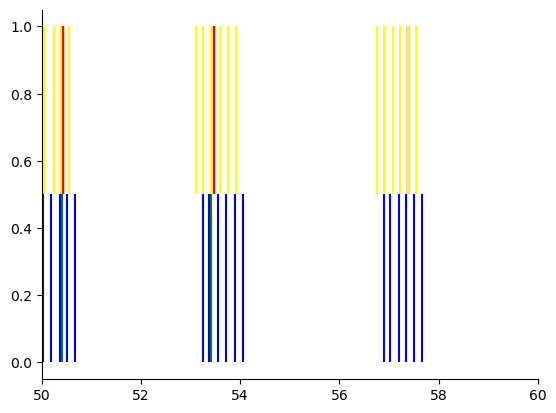

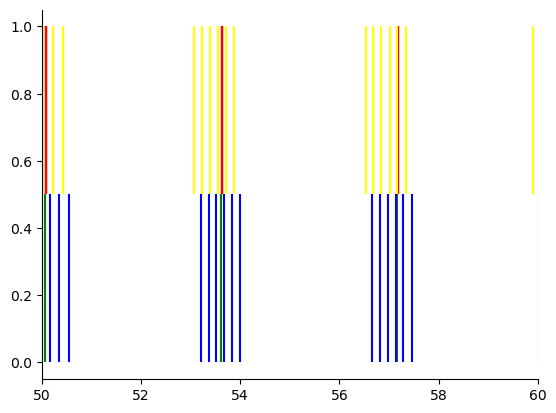

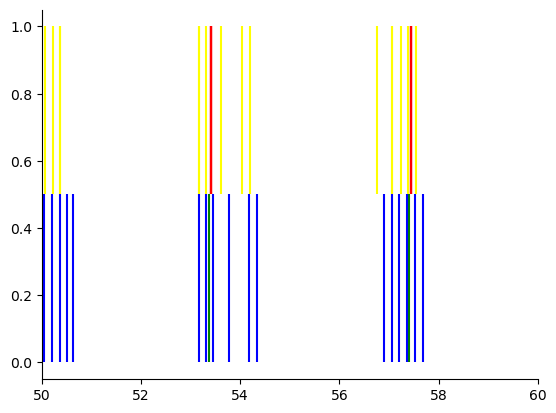

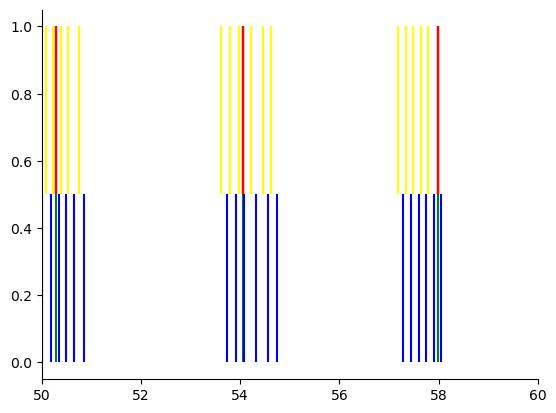

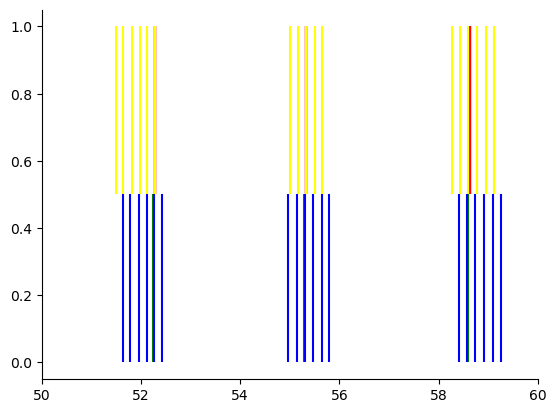

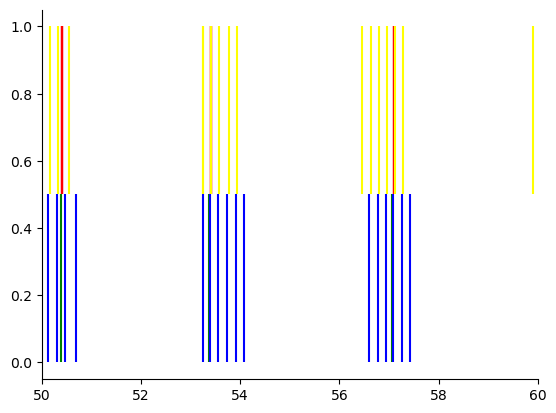

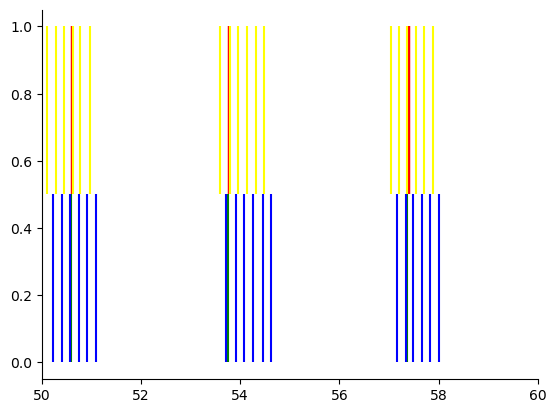

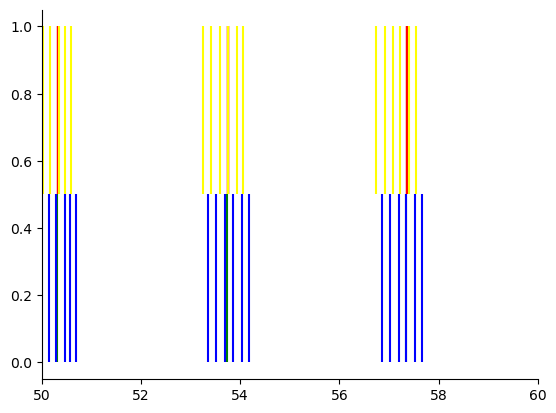

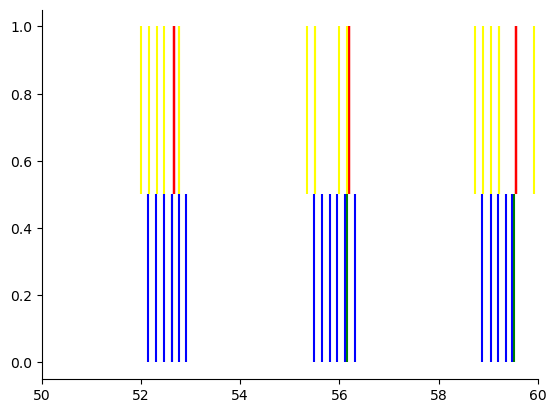

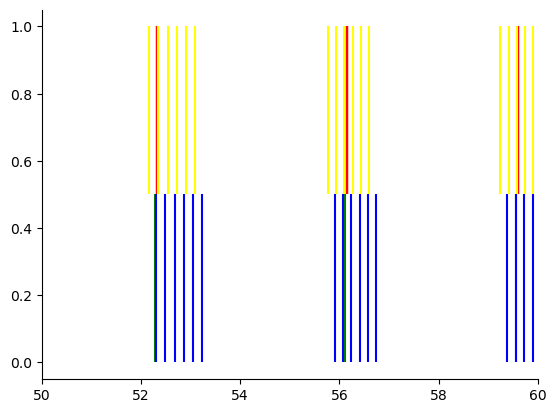

P12 B1


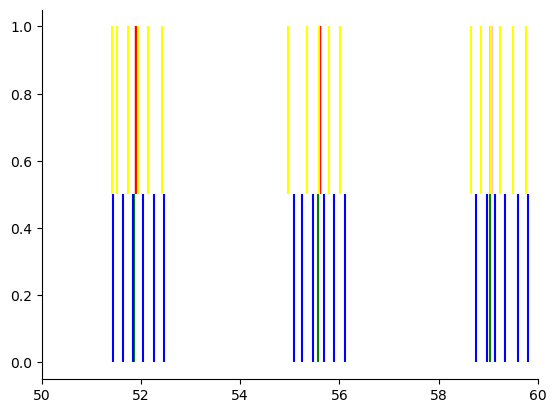

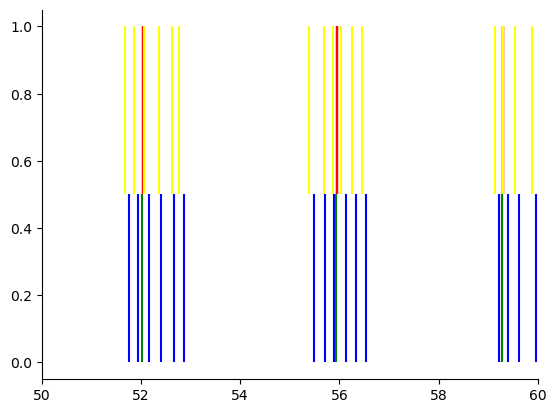

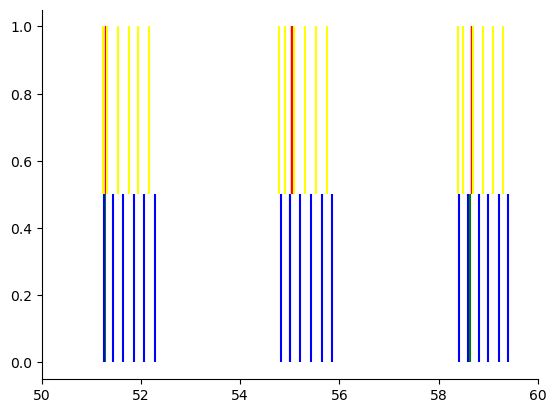

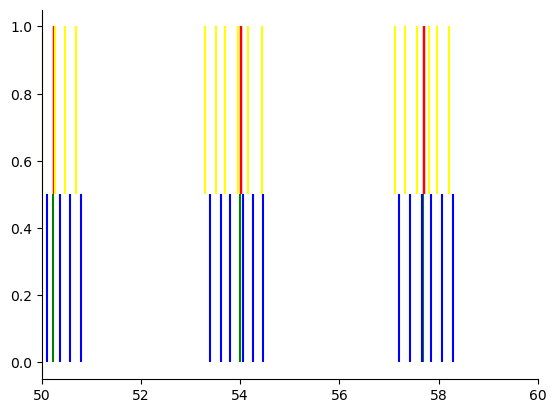

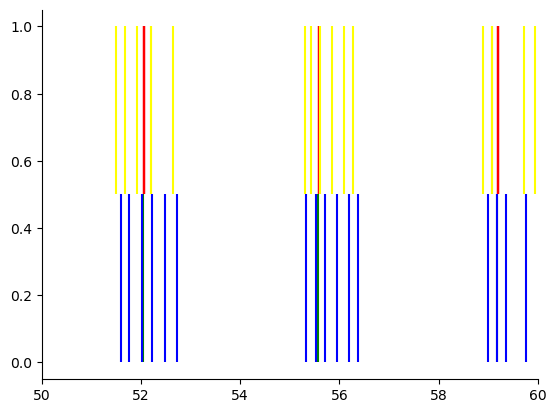

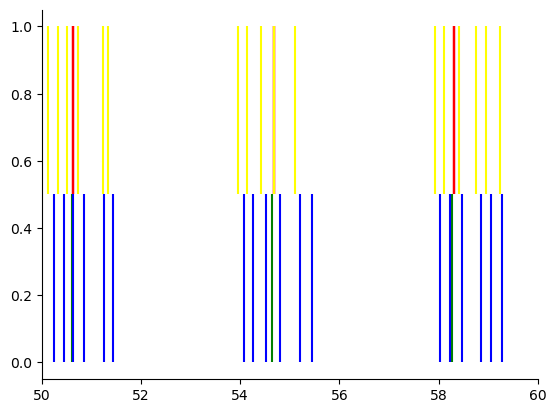

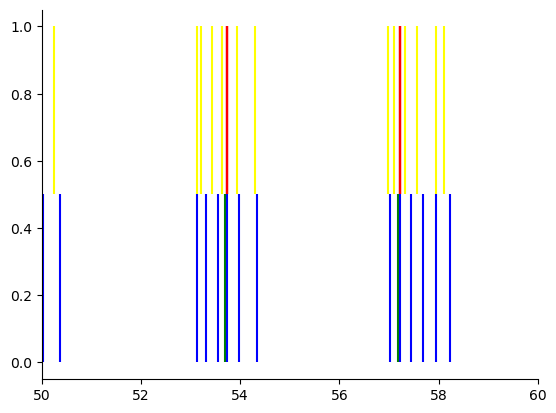

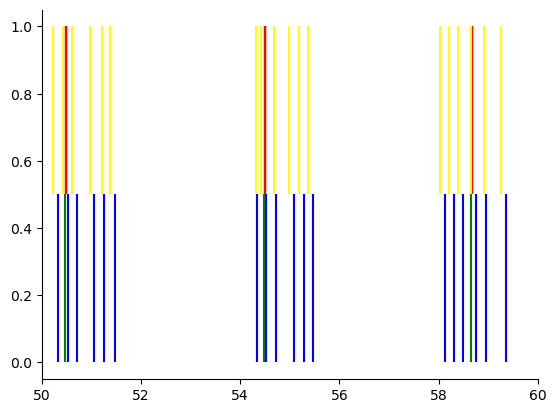

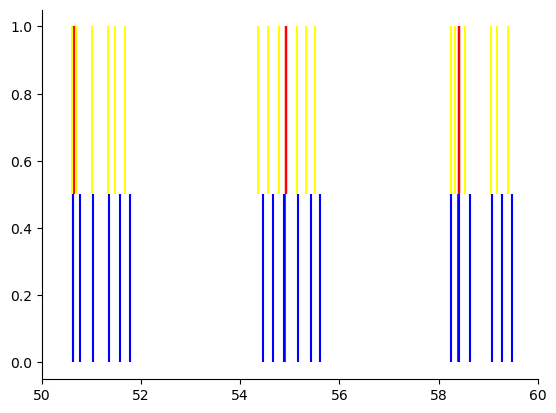

P12 B2


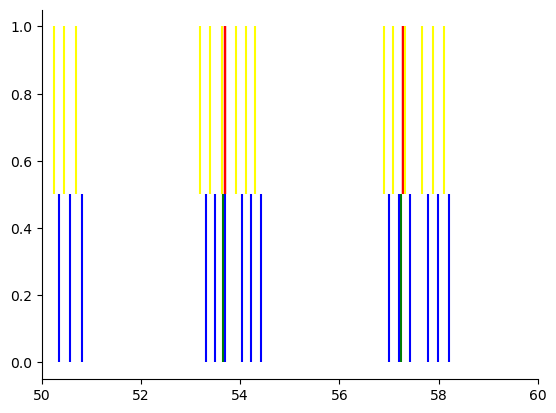

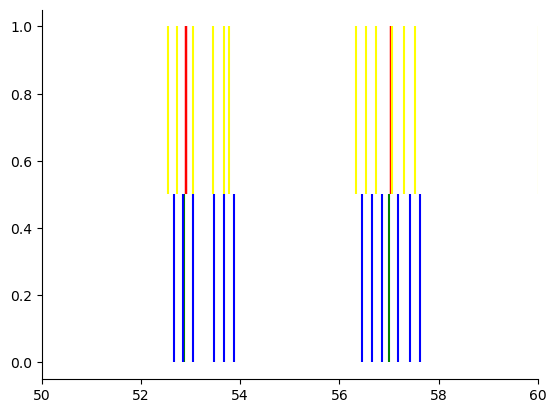

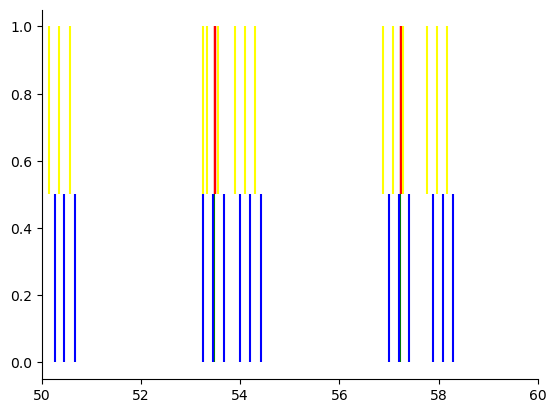

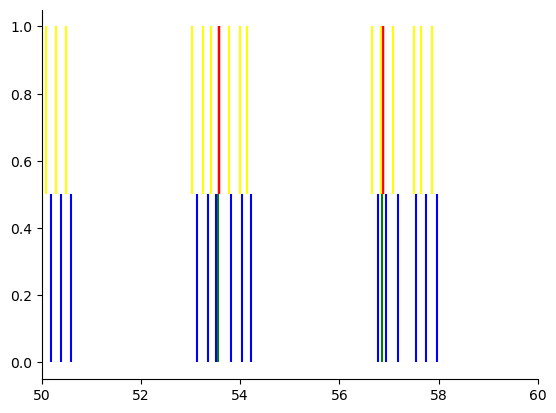

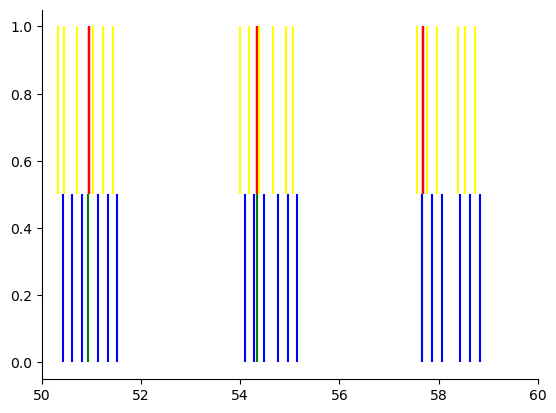

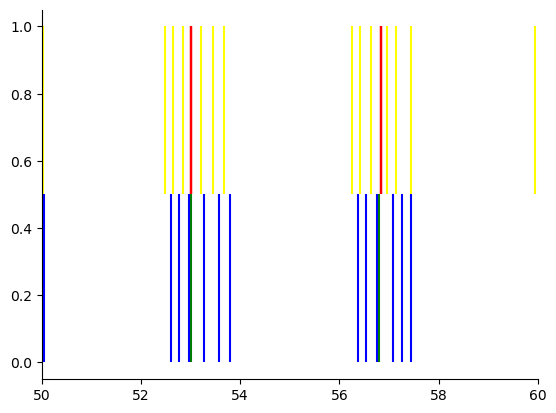

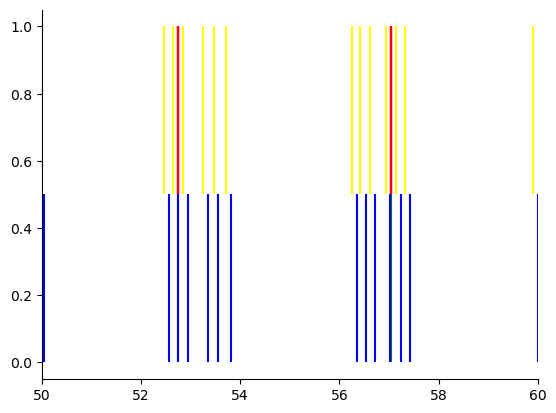

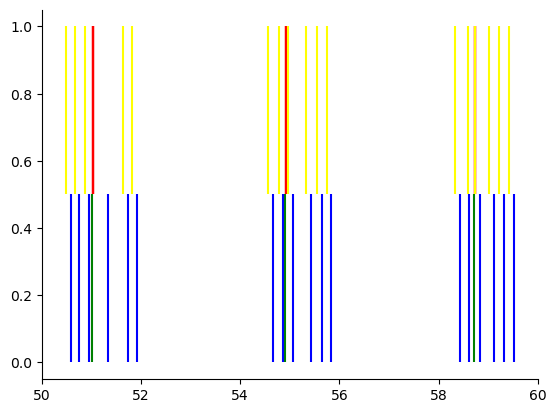

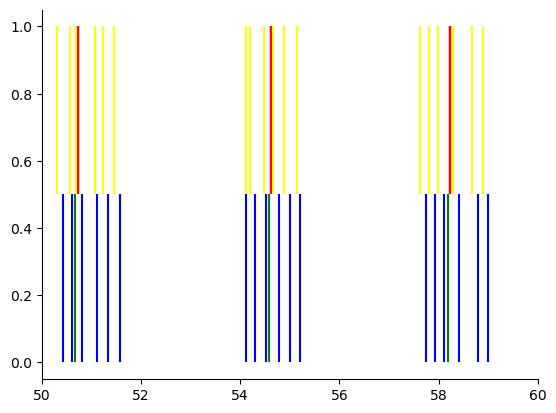

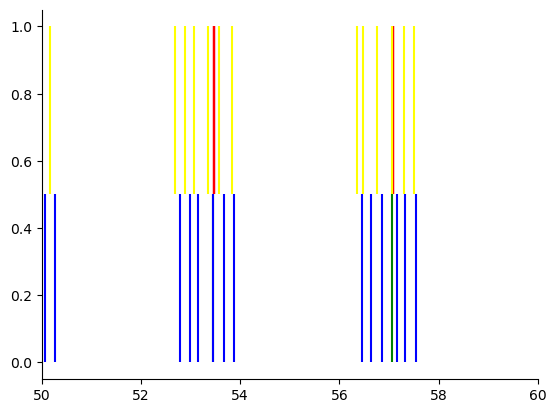

P13 B1


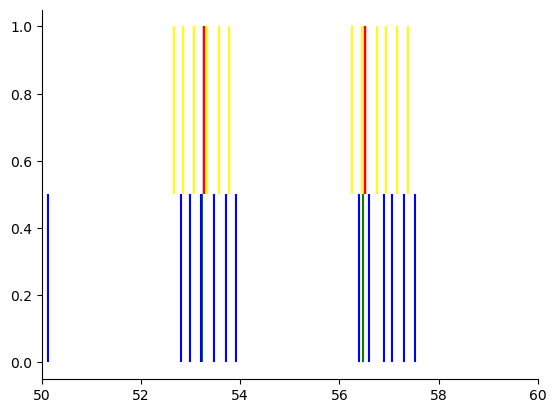

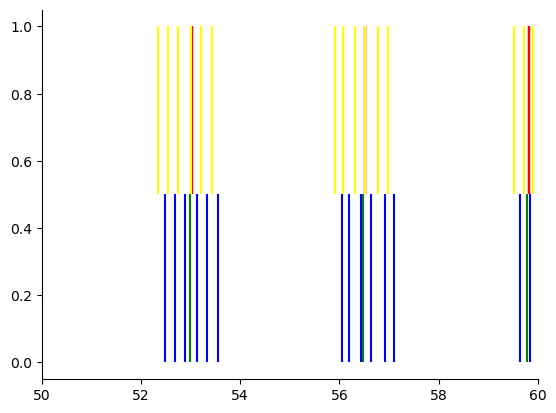

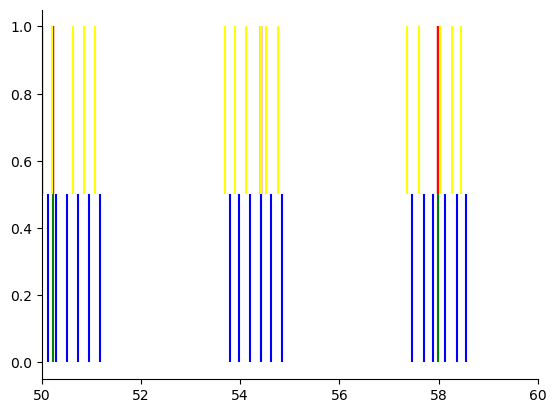

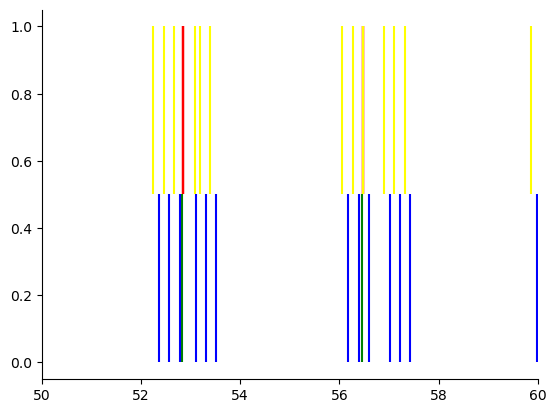

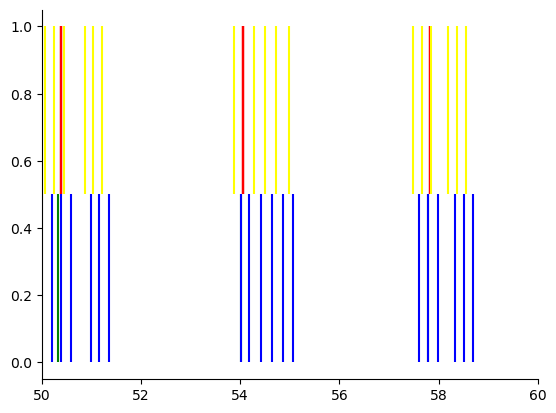

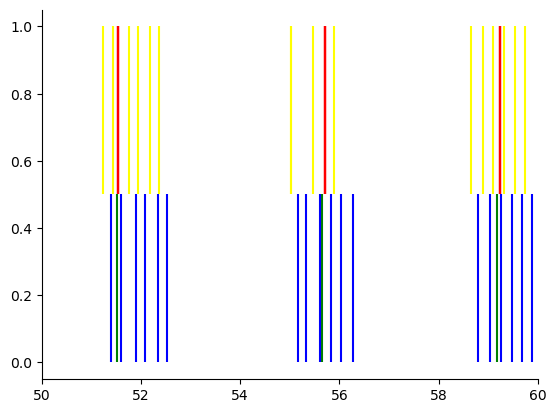

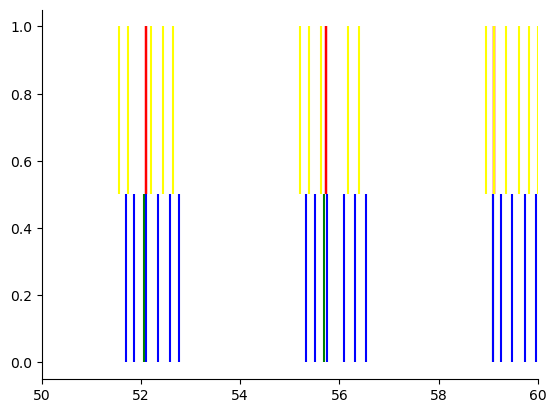

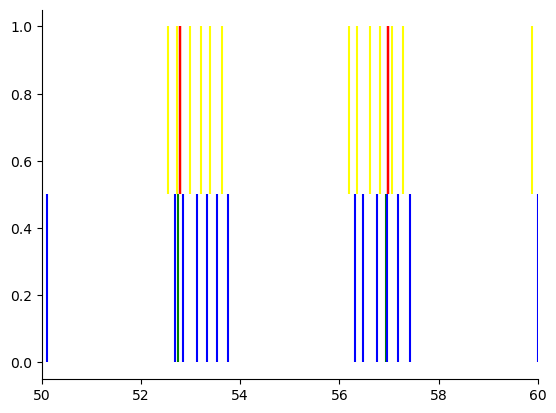

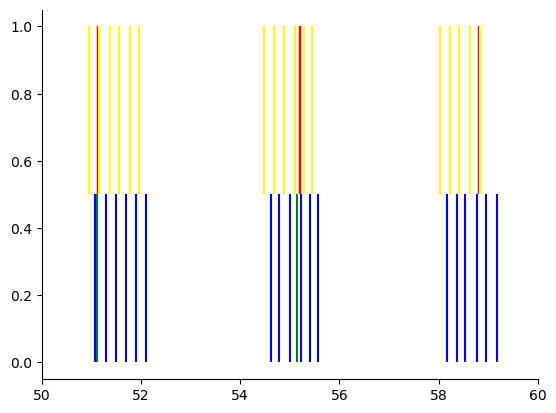

P13 B2


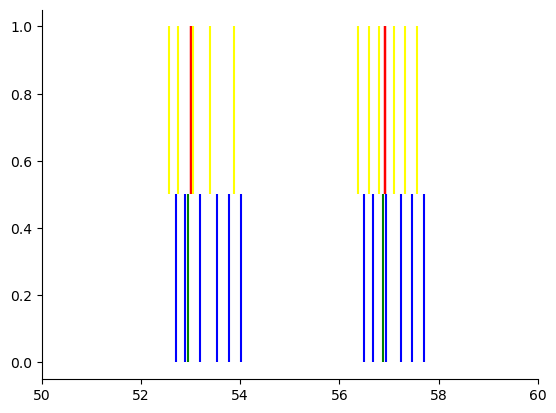

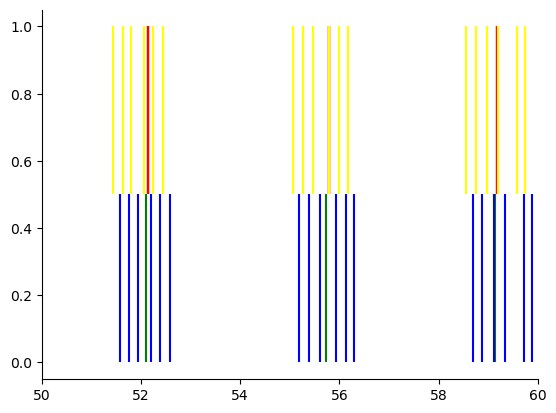

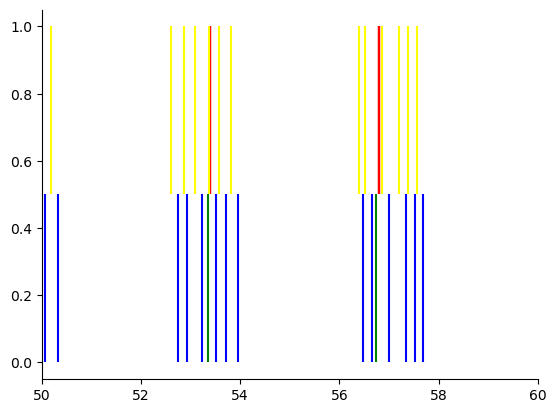

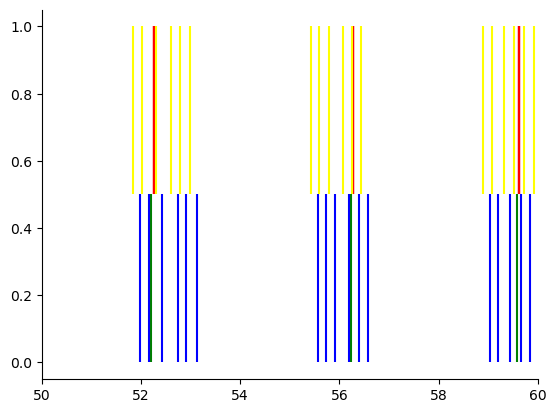

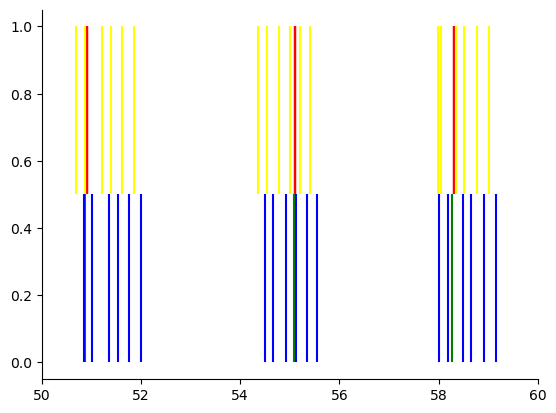

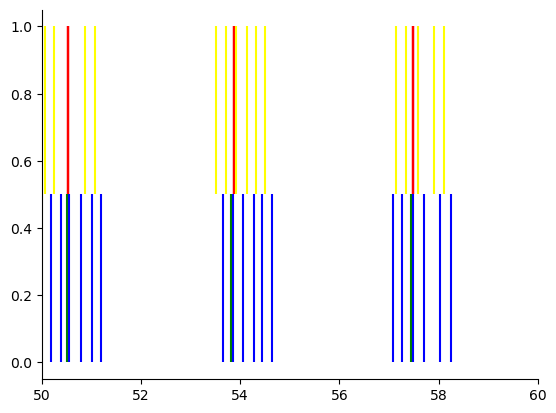

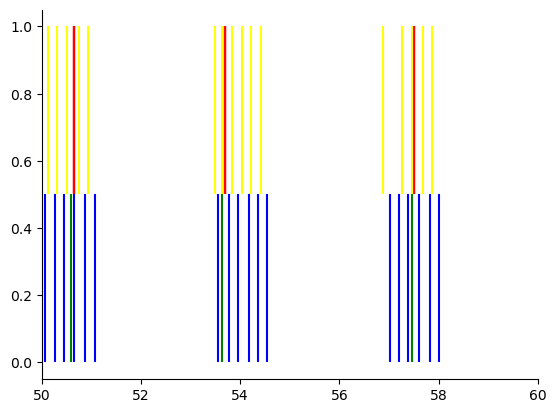

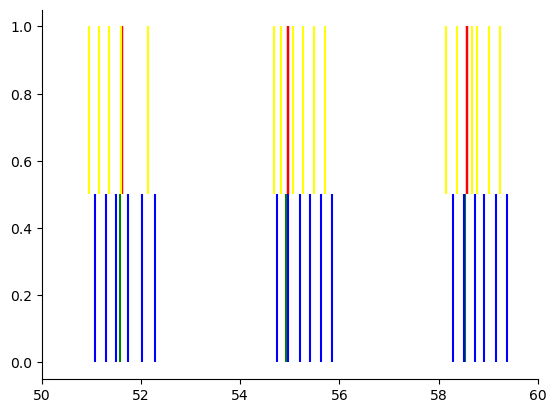

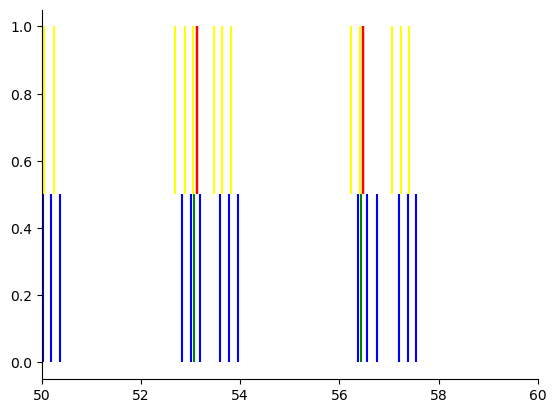

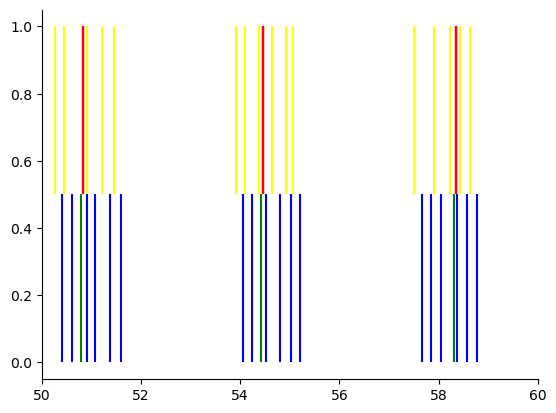

P14 B1


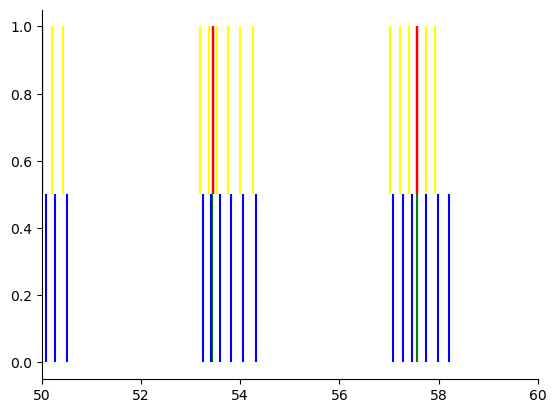

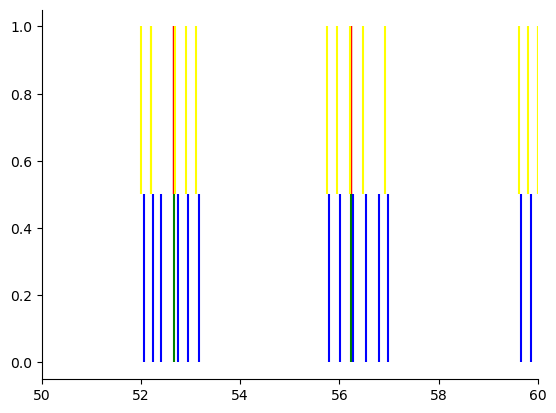

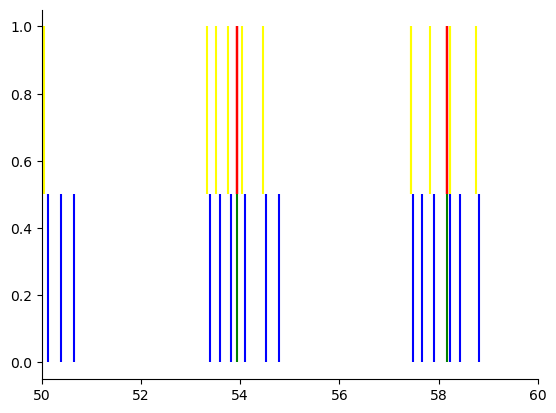

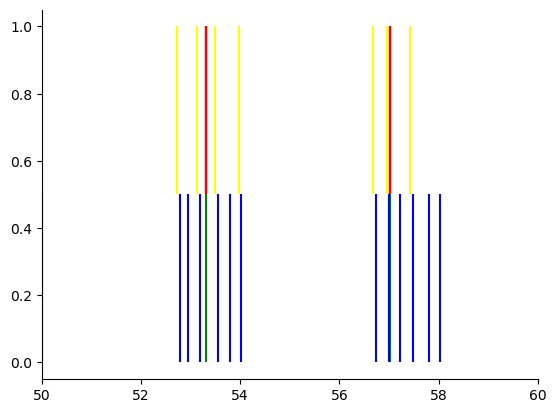

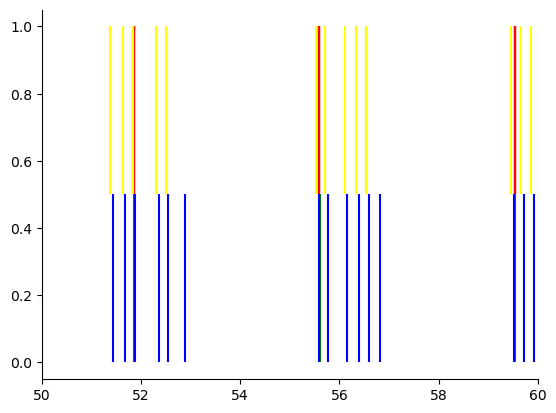

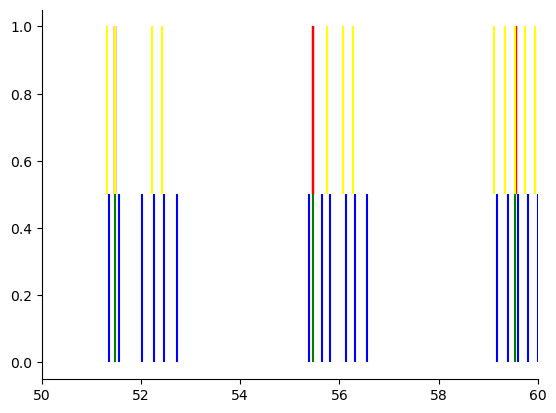

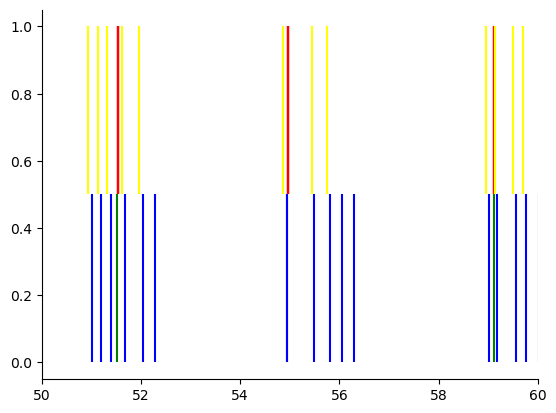

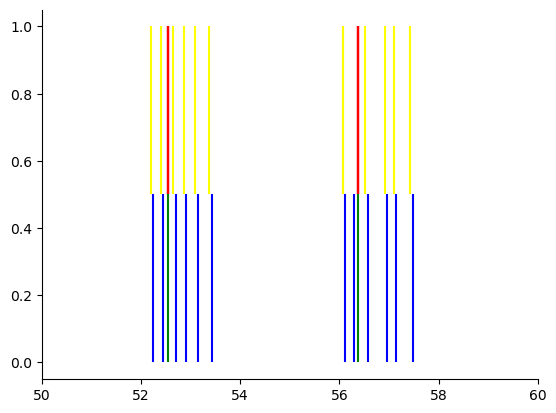

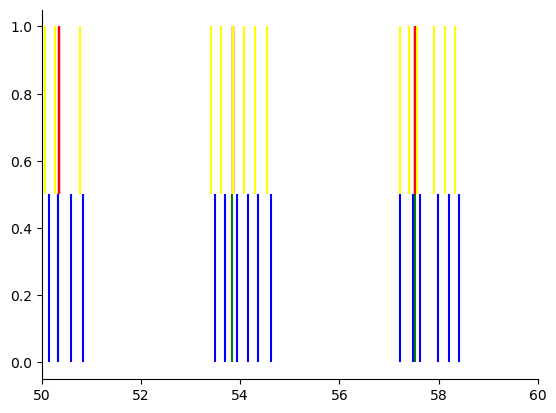

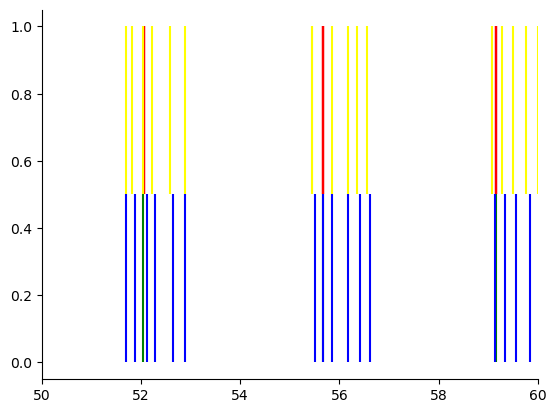

P14 B2


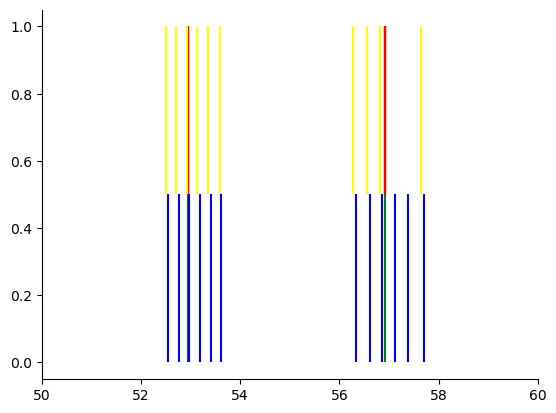

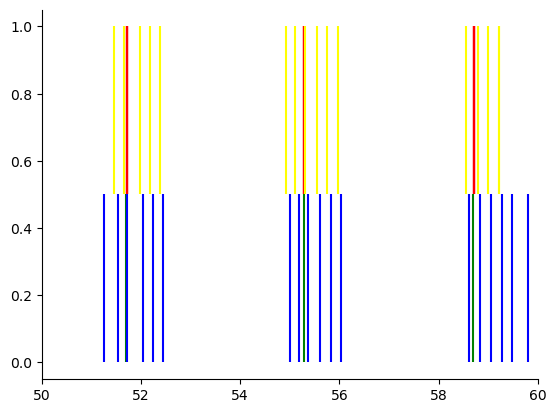

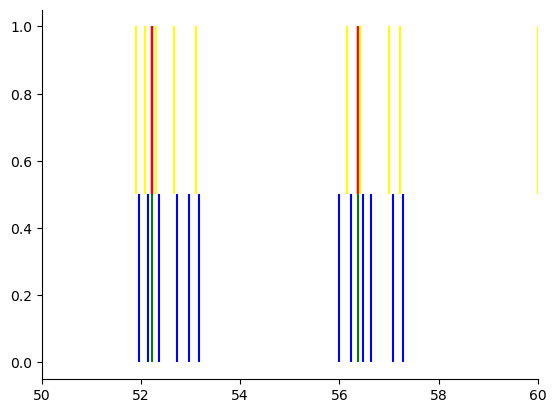

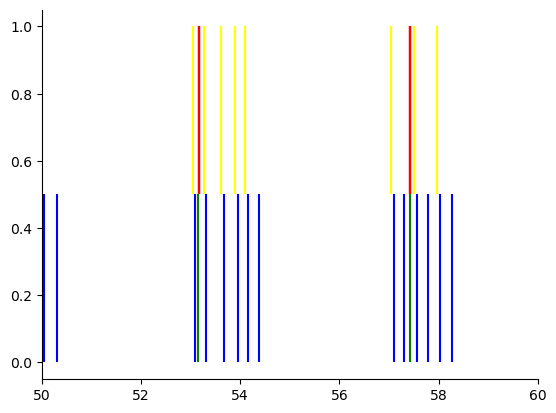

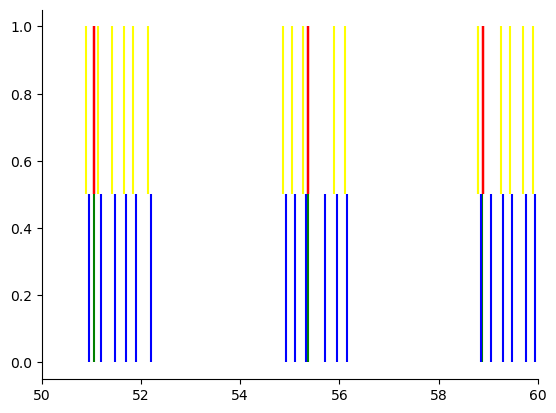

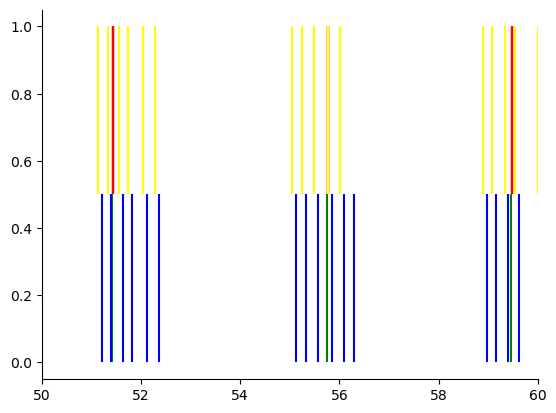

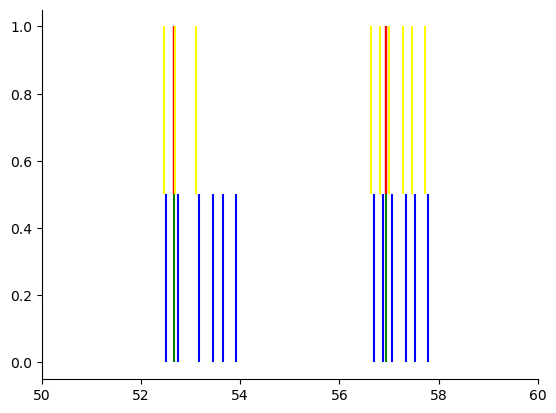

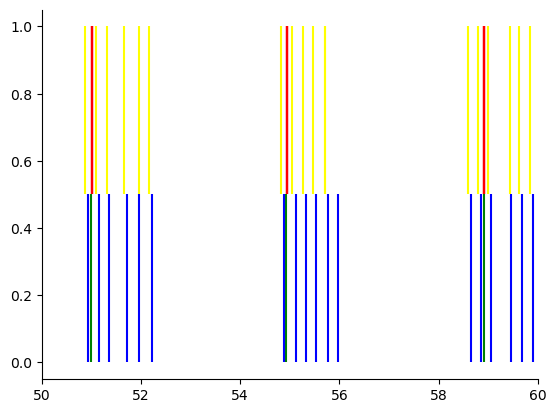

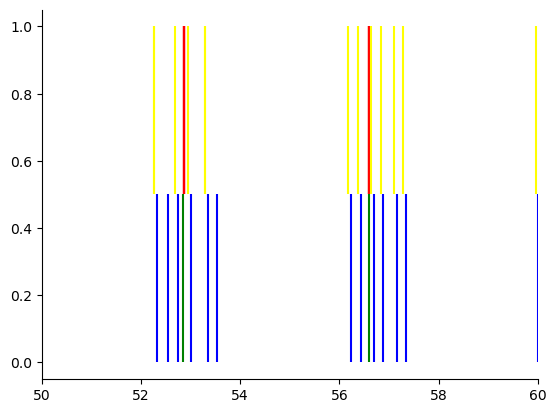

P15 B1


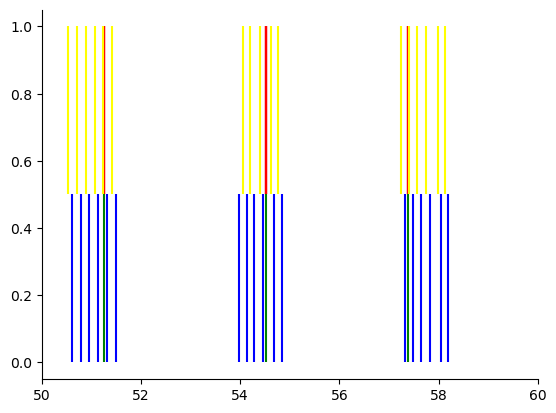

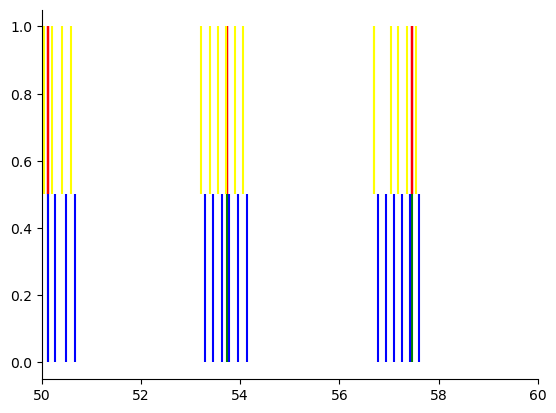

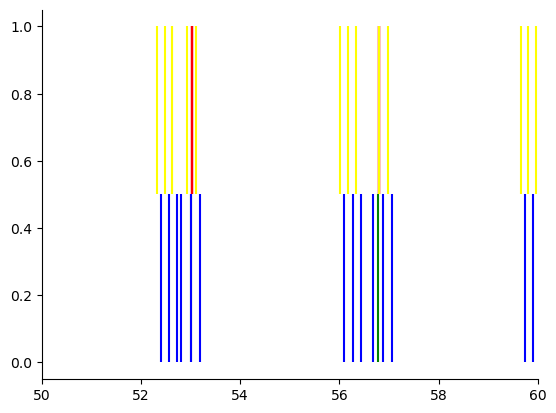

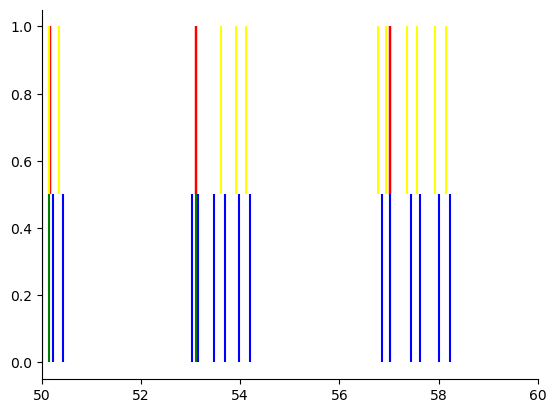

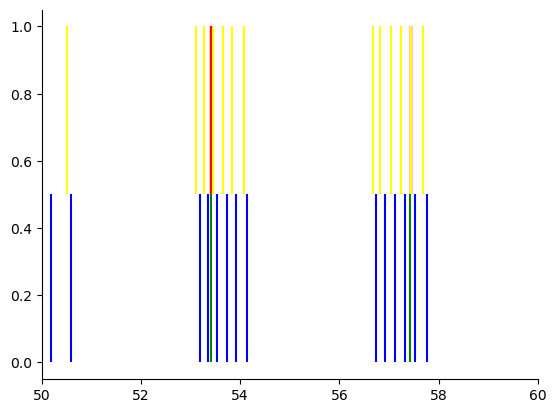

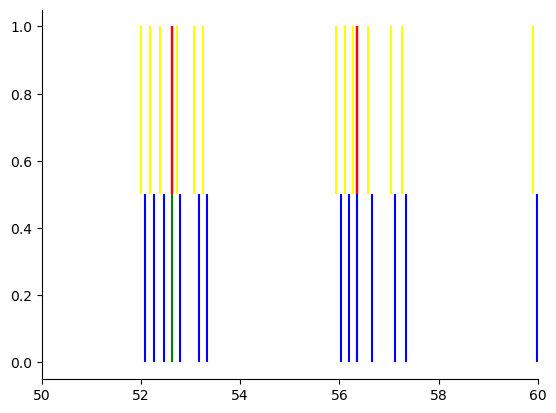

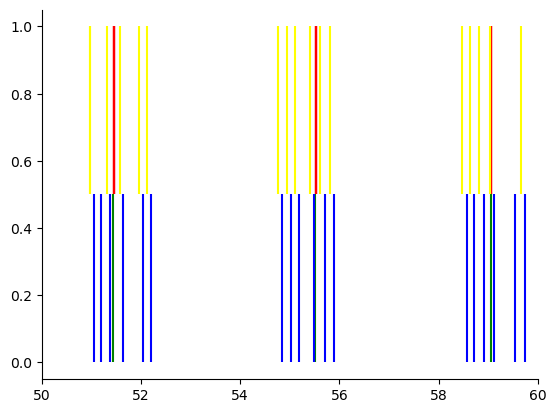

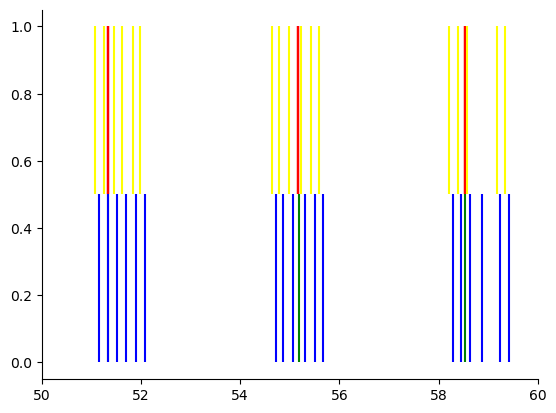

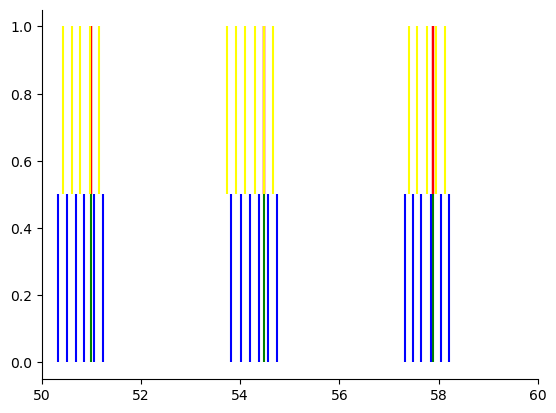

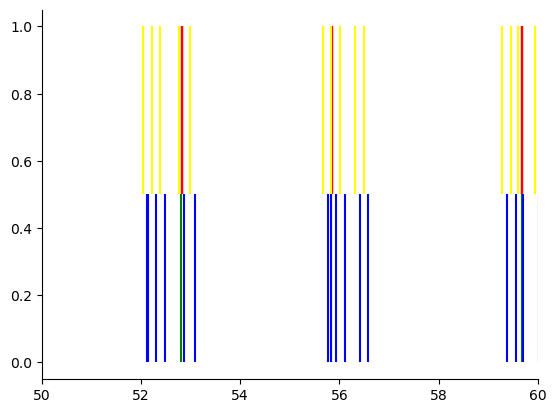

P15 B2
P16 B1


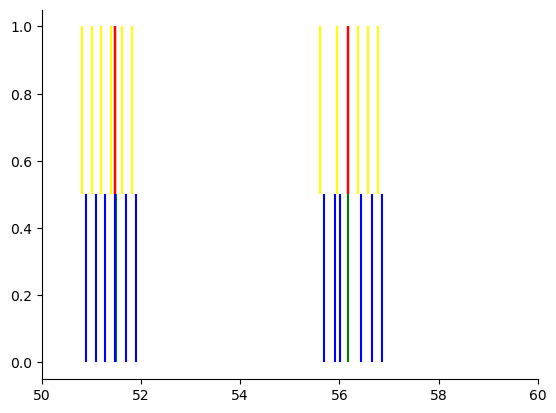

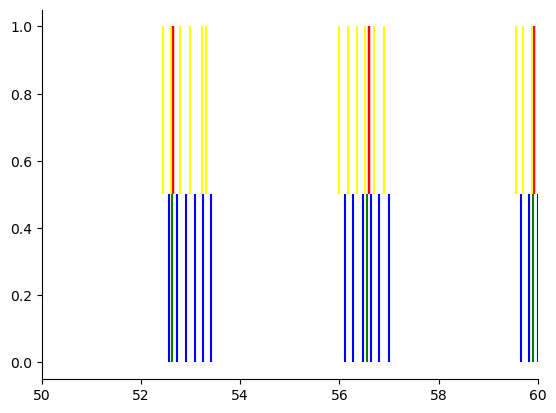

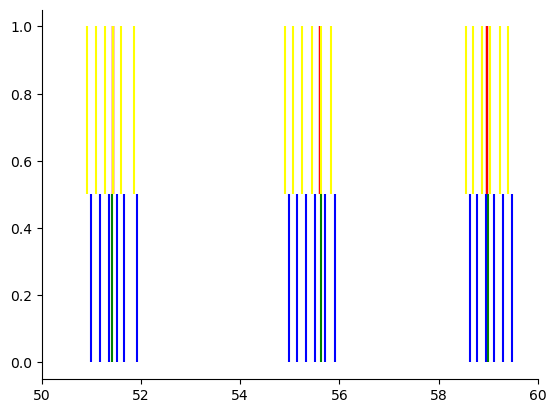

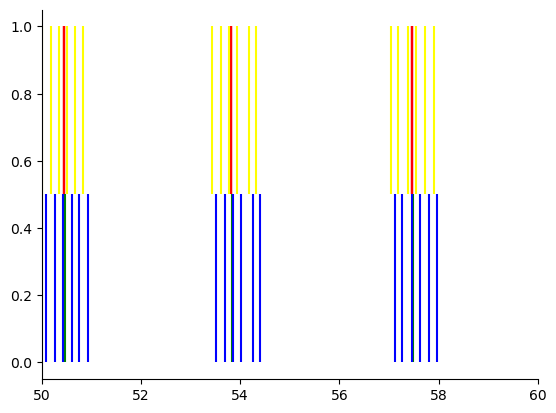

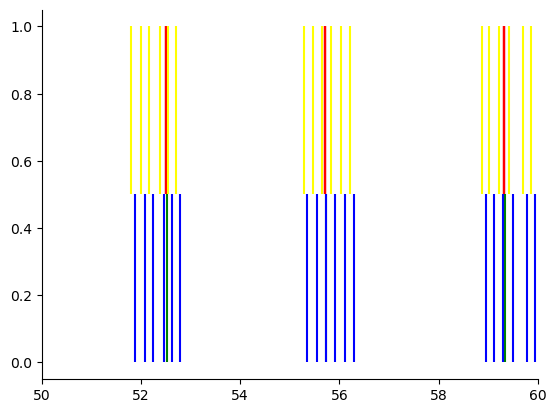

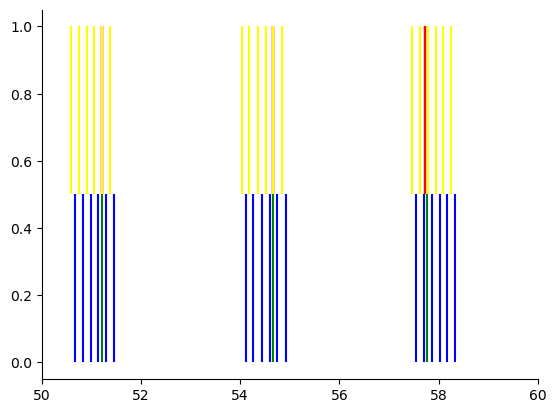

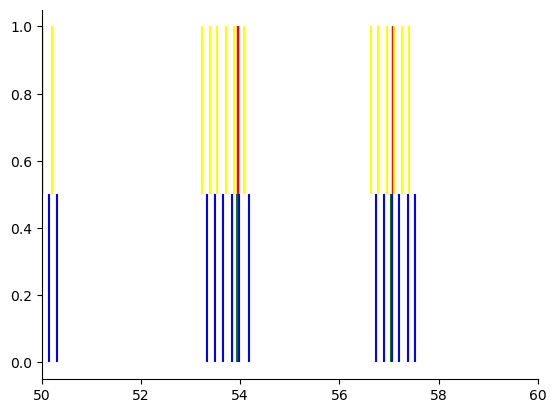

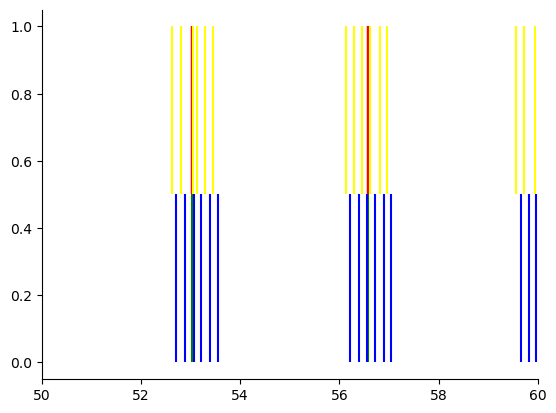

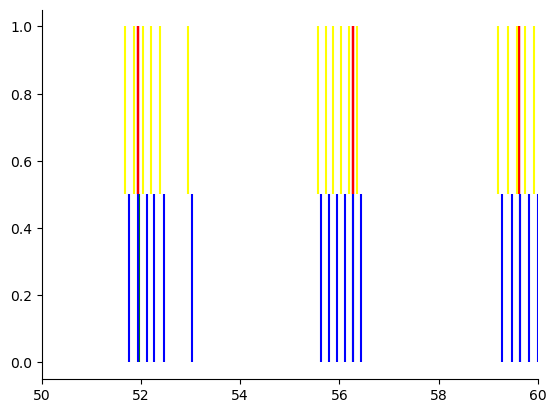

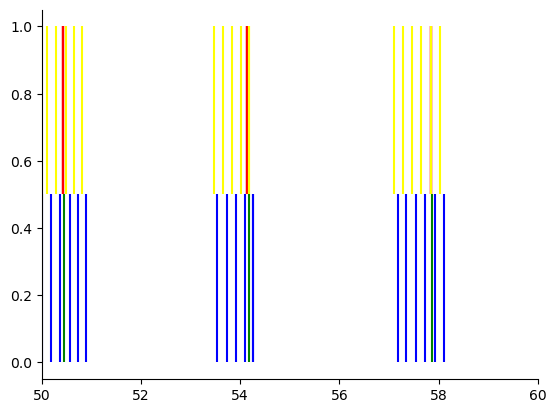

P16 B2


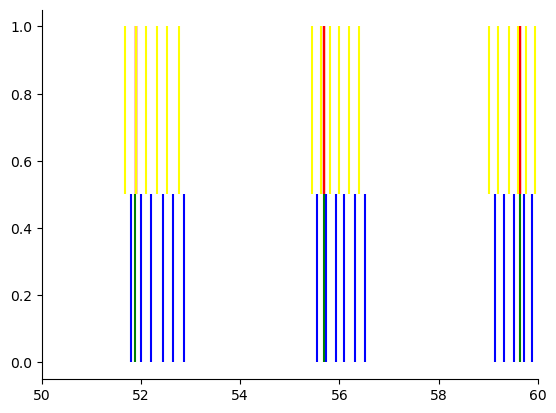

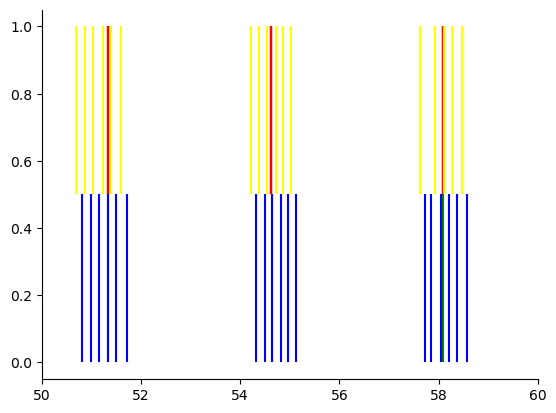

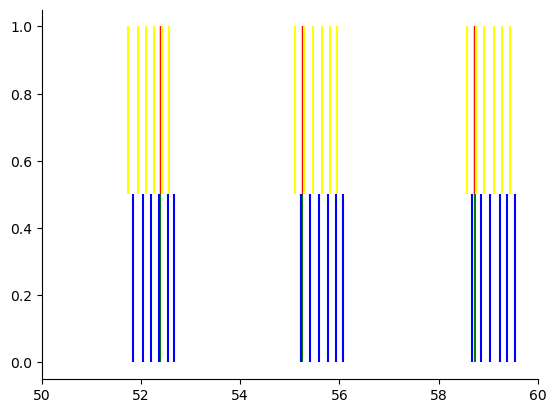

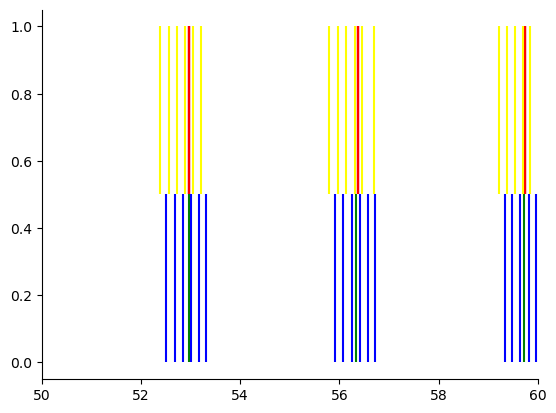

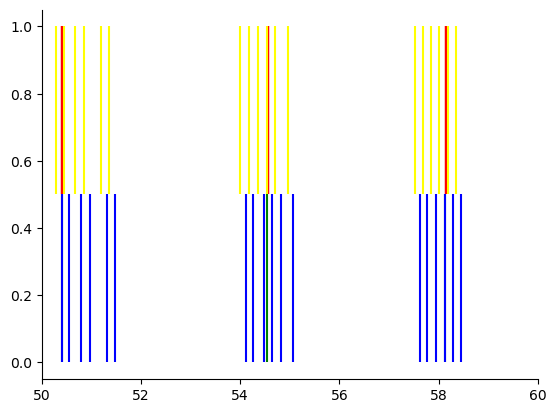

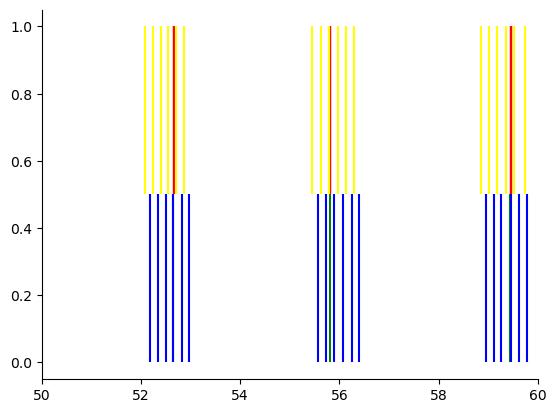

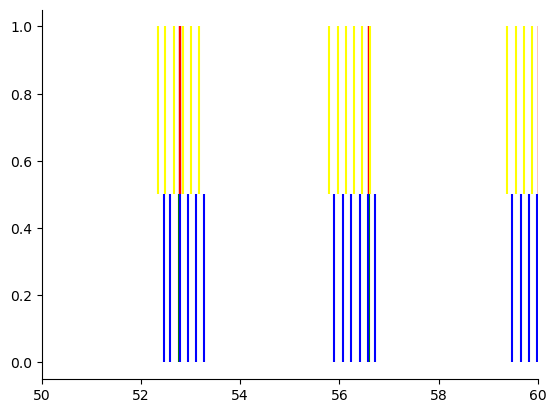

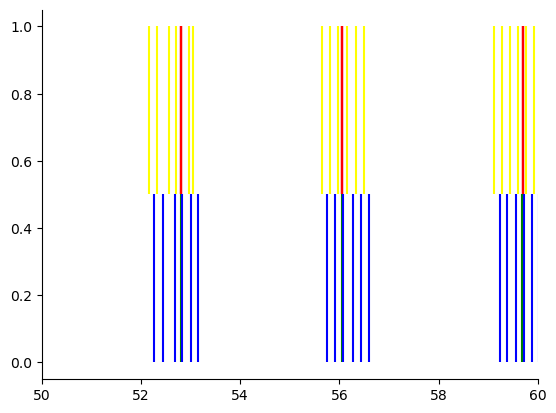

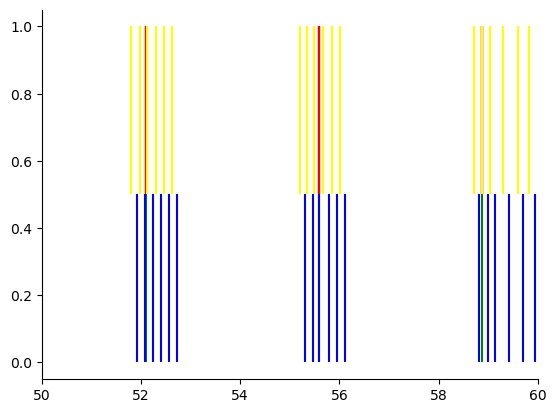

P17 B1


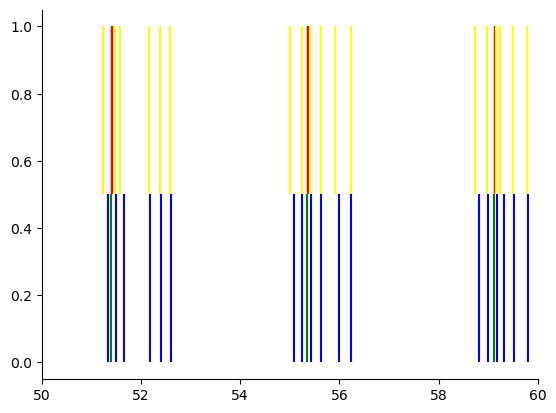

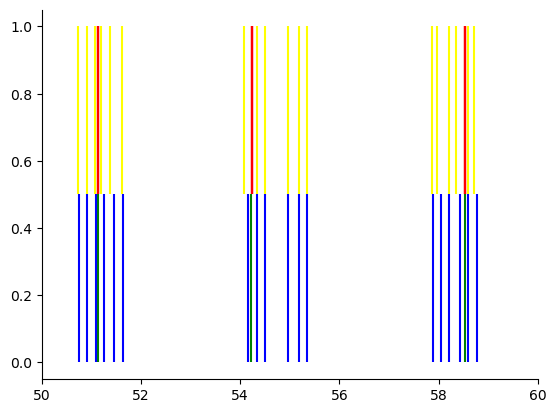

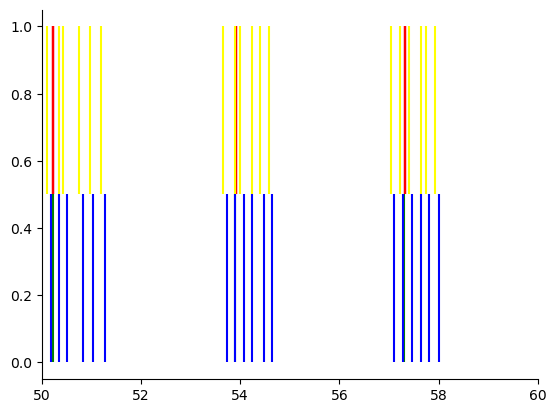

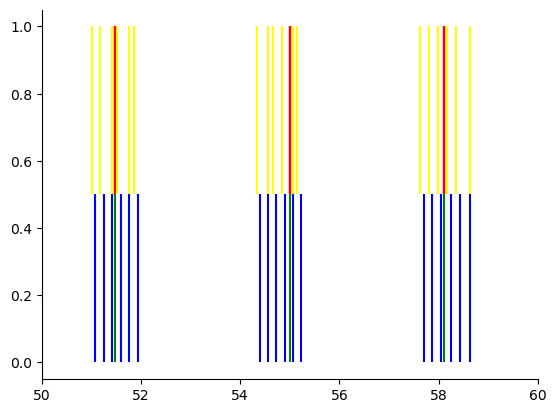

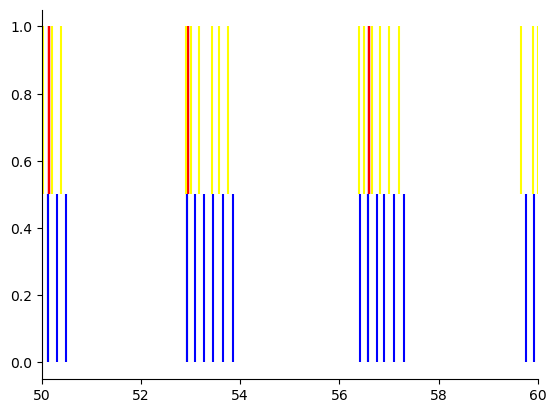

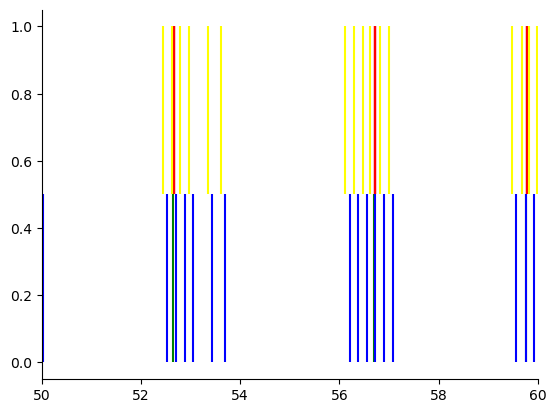

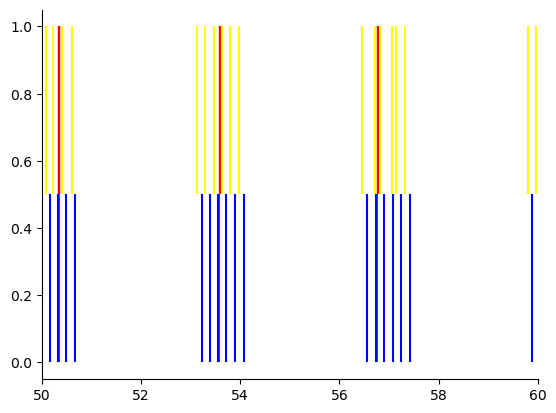

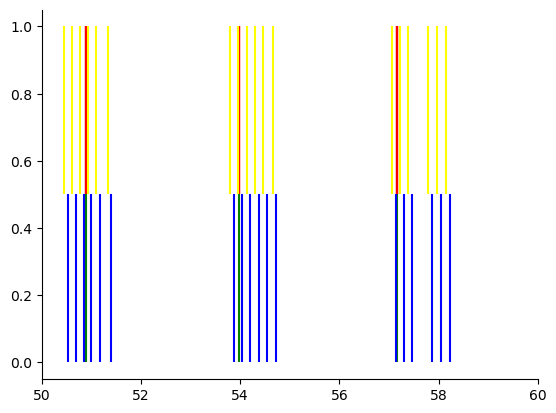

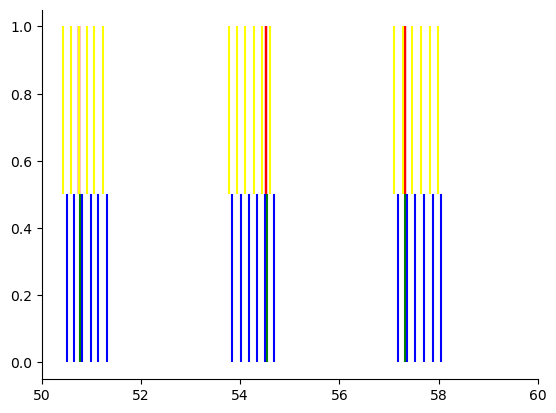

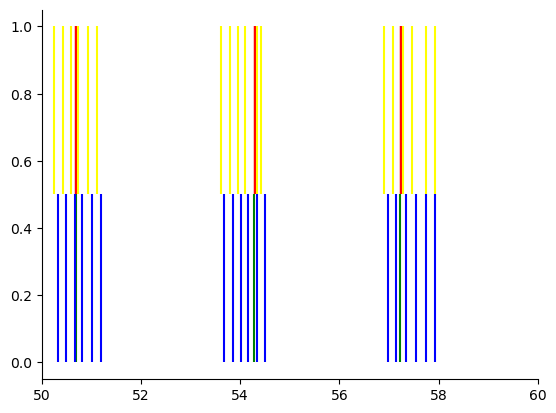

P17 B2


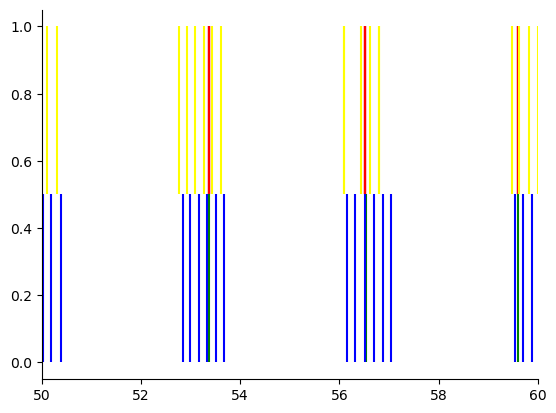

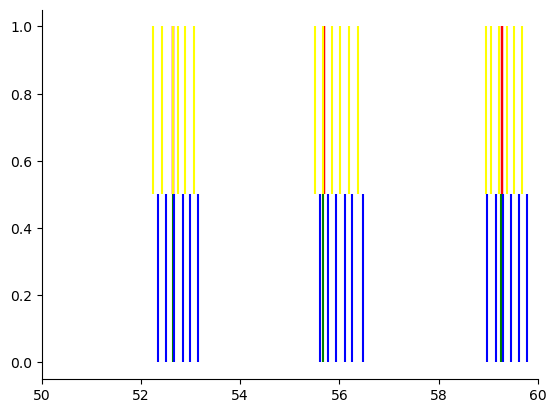

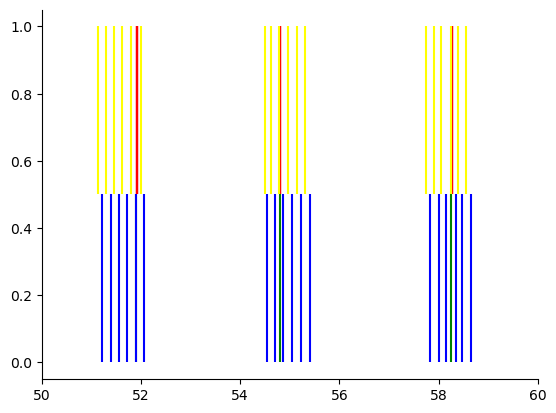

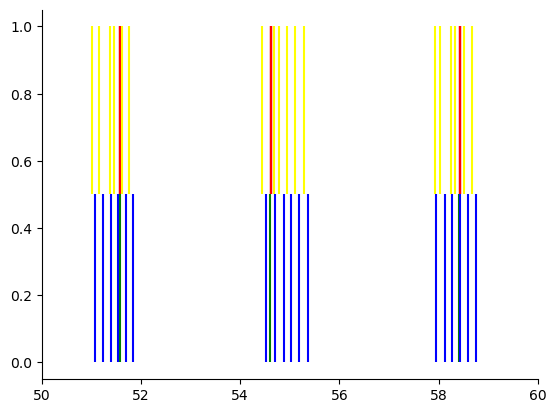

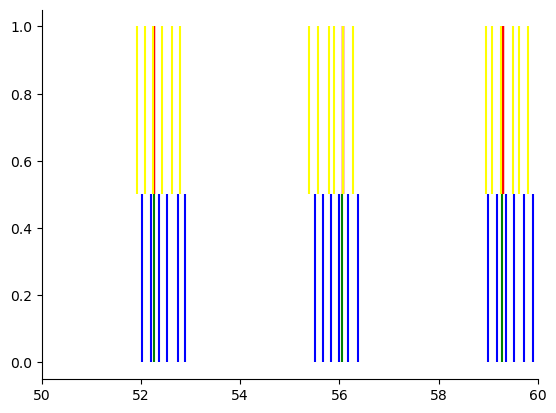

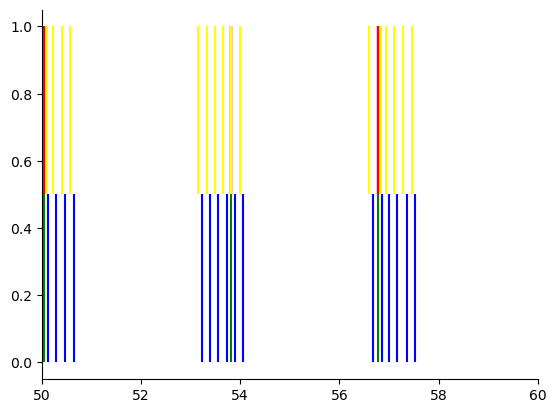

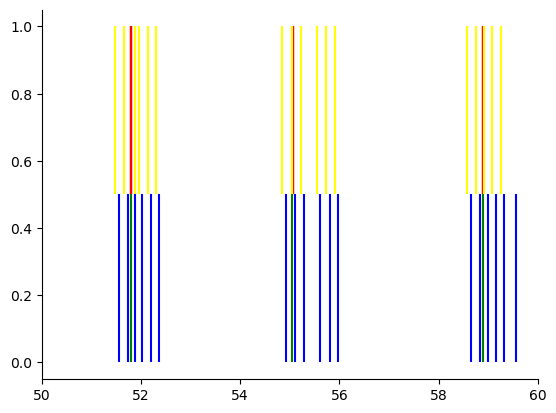

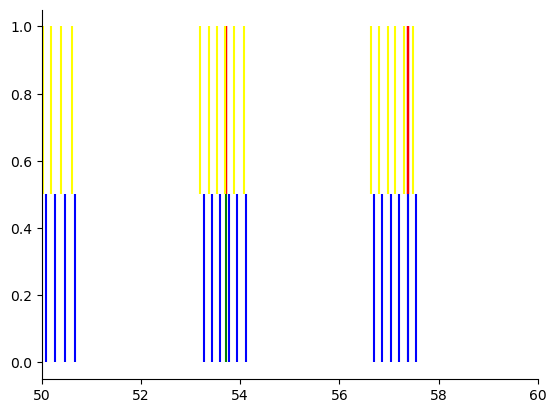

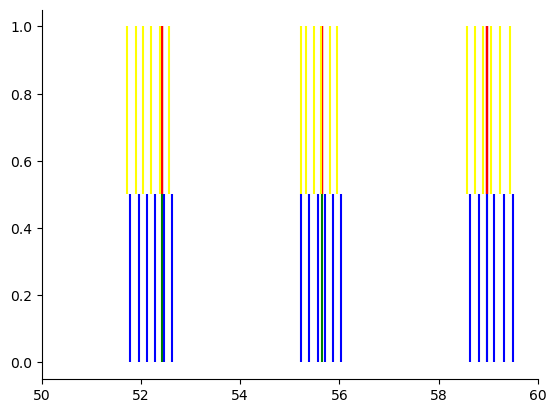

P18 B1


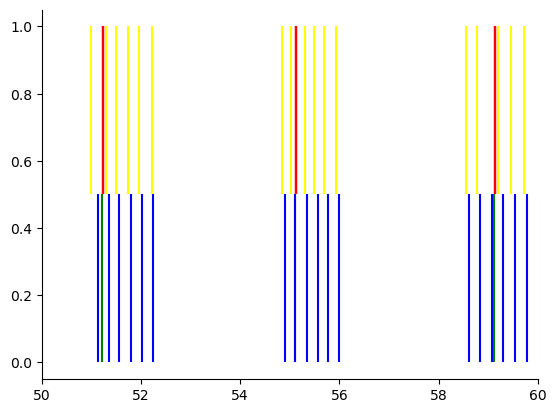

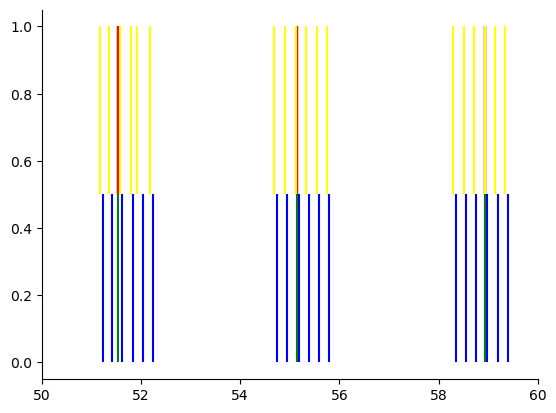

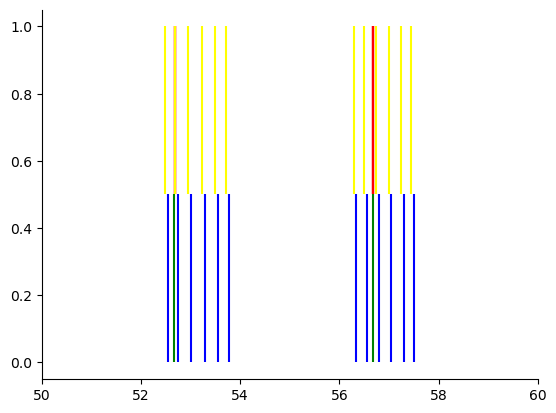

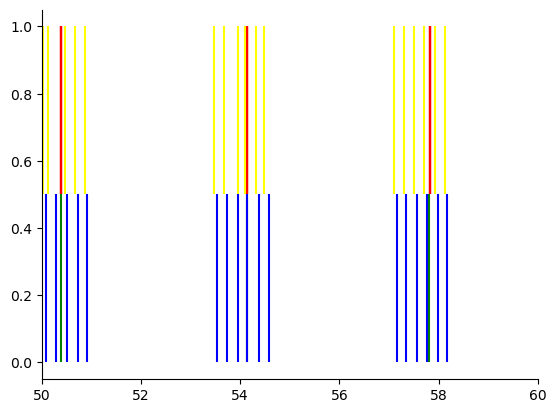

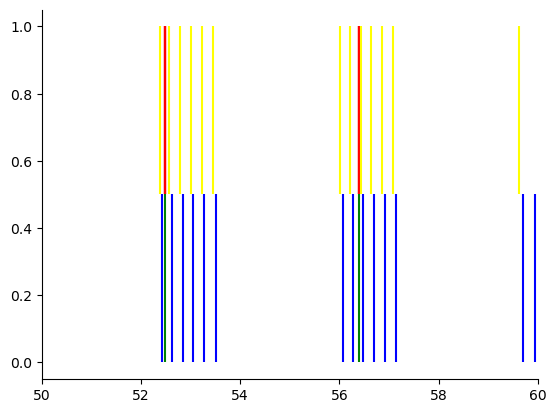

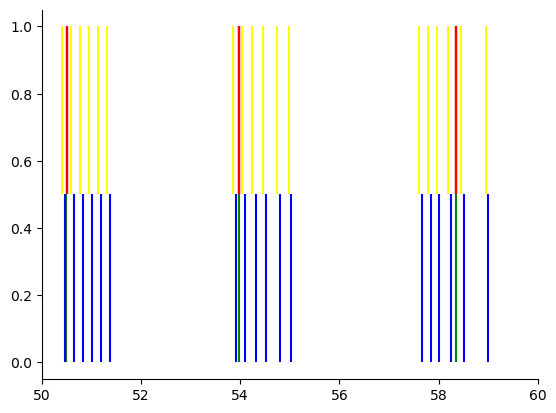

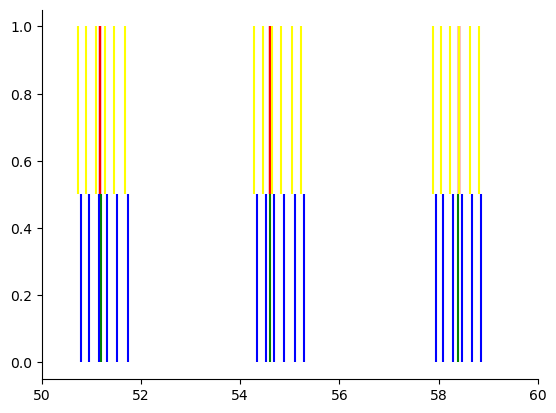

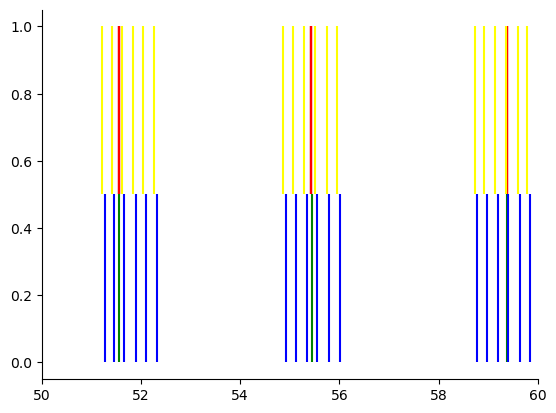

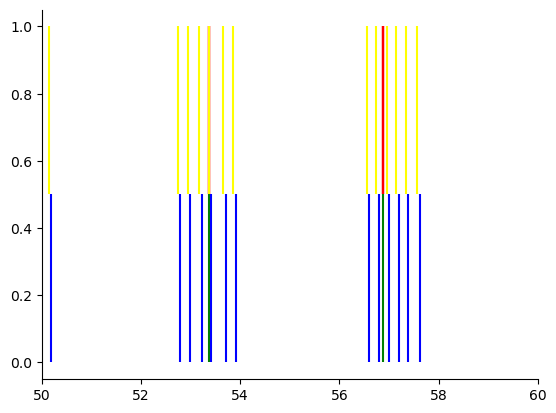

P18 B2


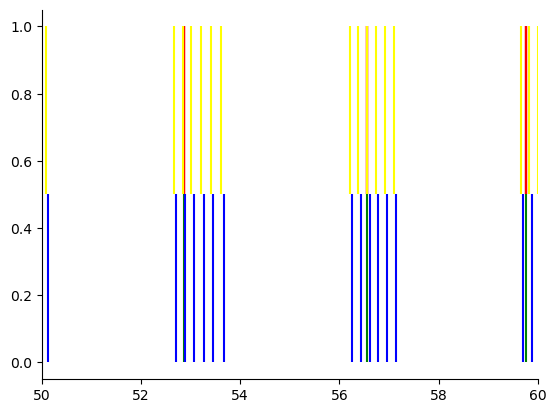

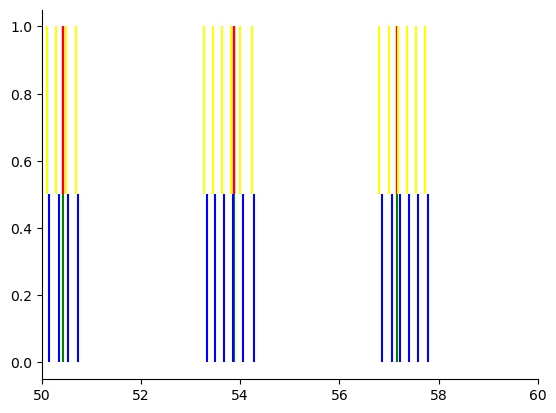

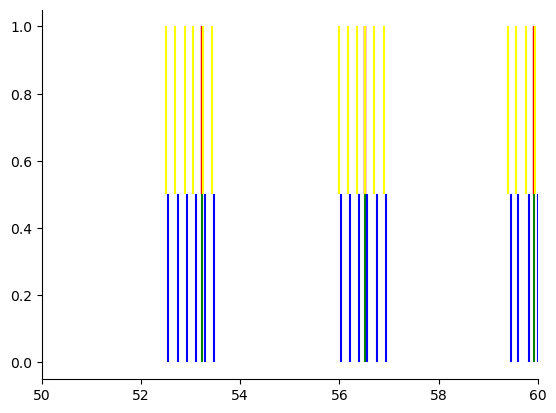

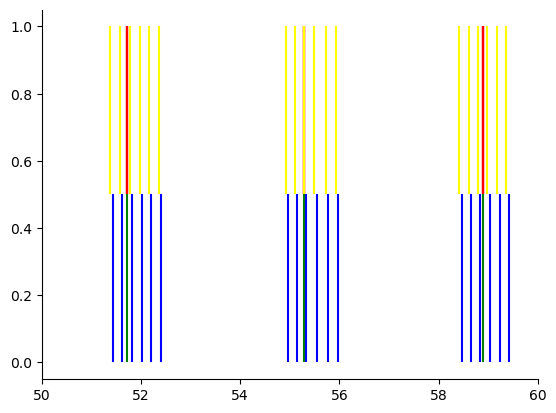

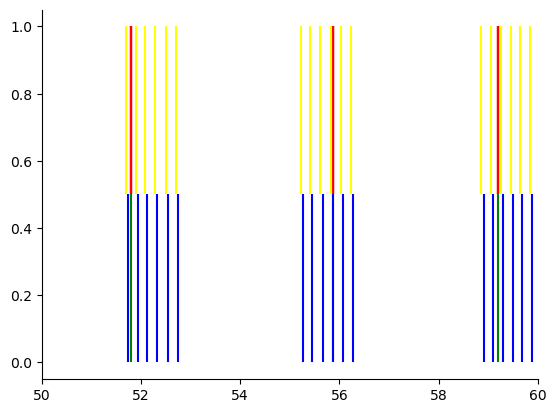

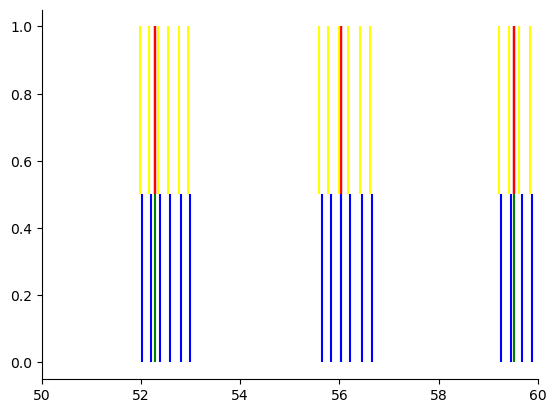

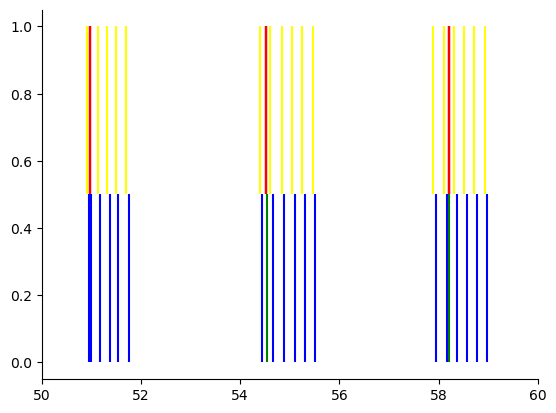

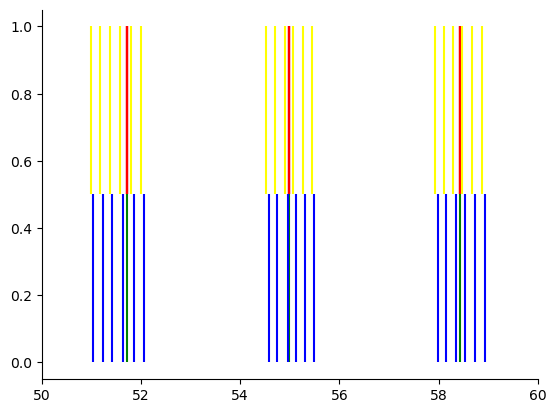

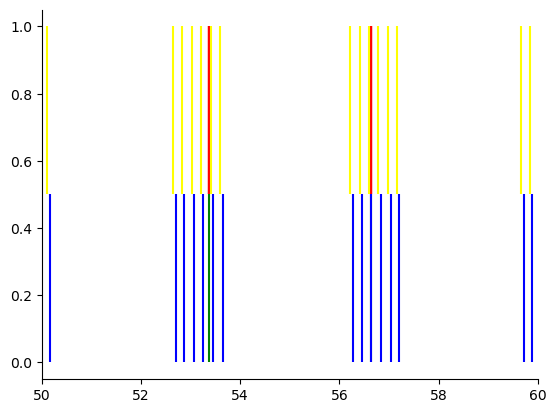

P19 B1


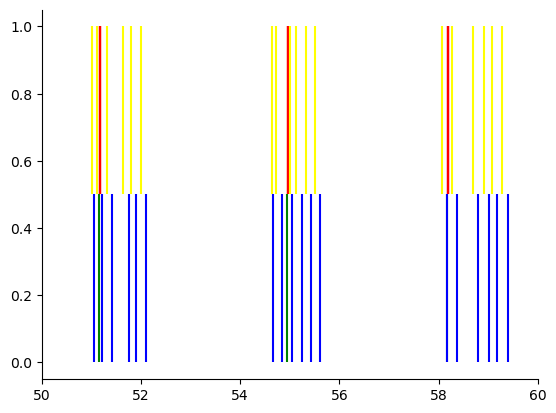

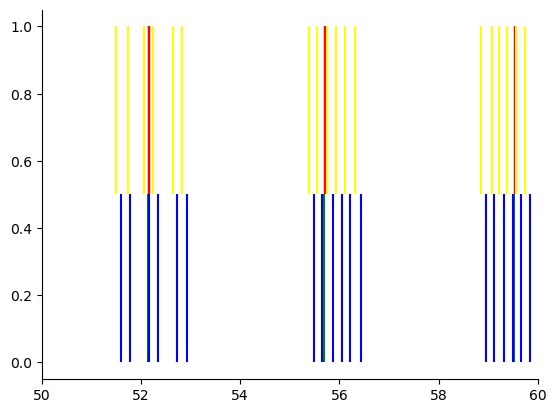

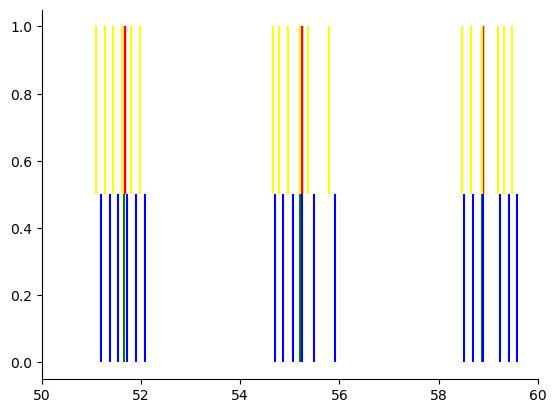

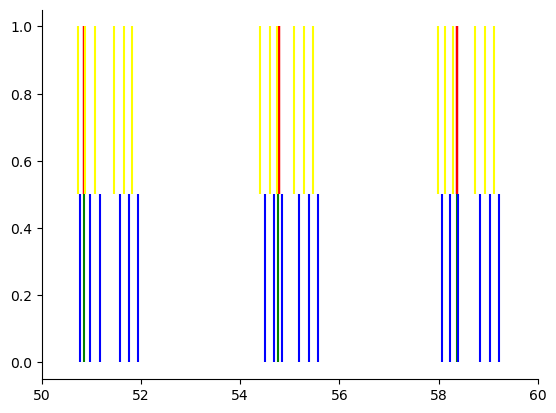

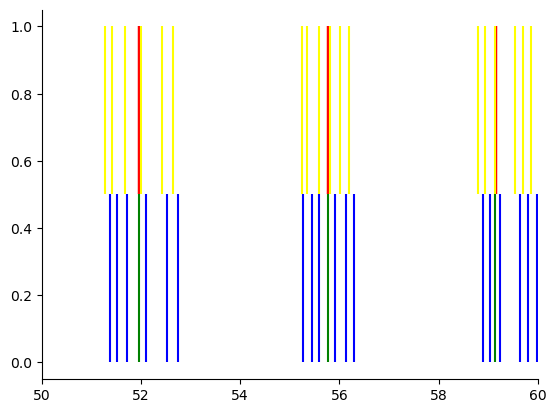

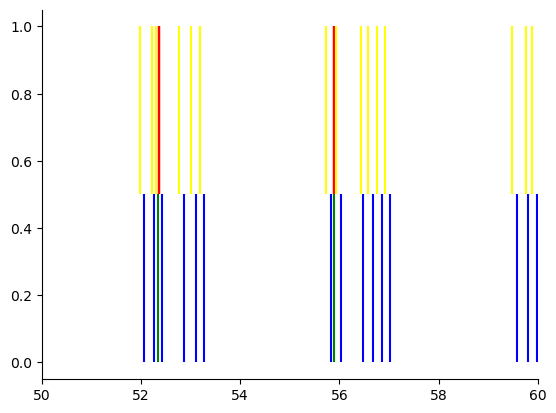

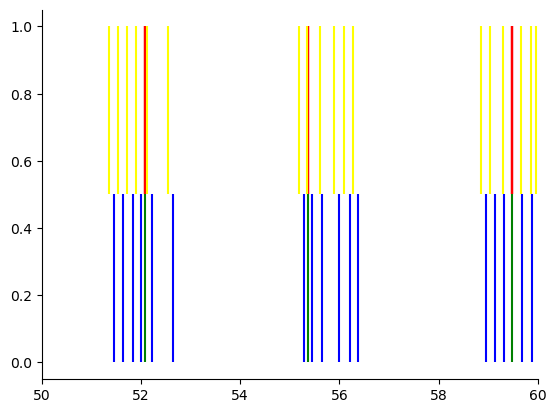

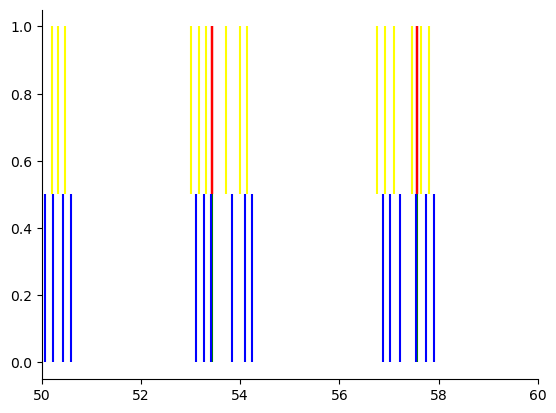

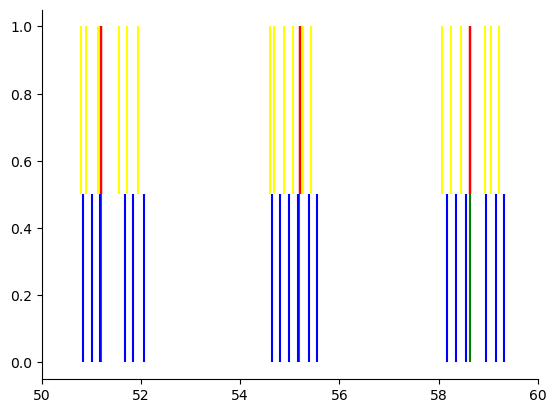

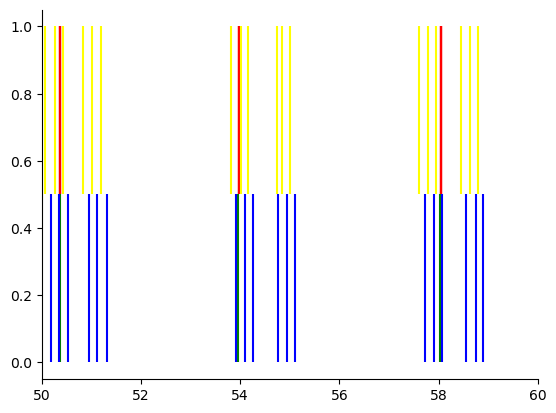

P19 B2


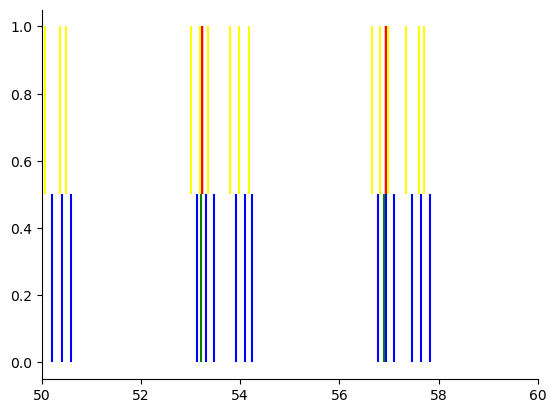

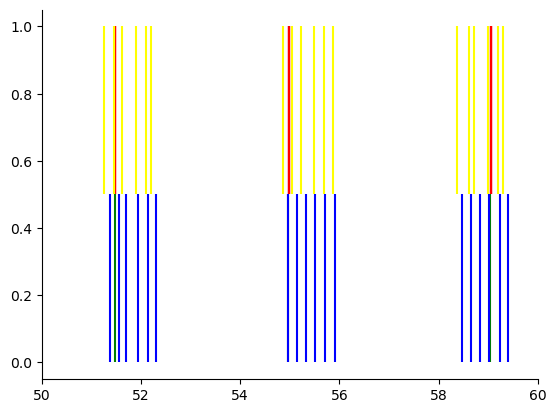

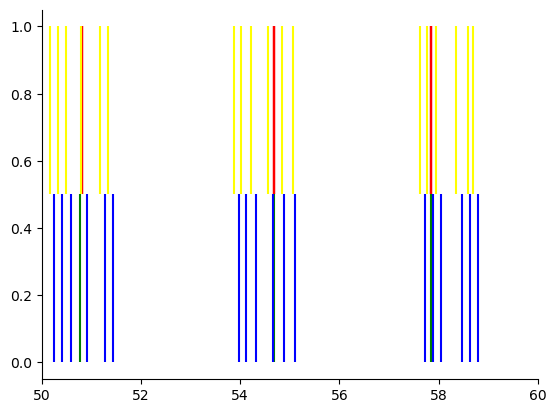

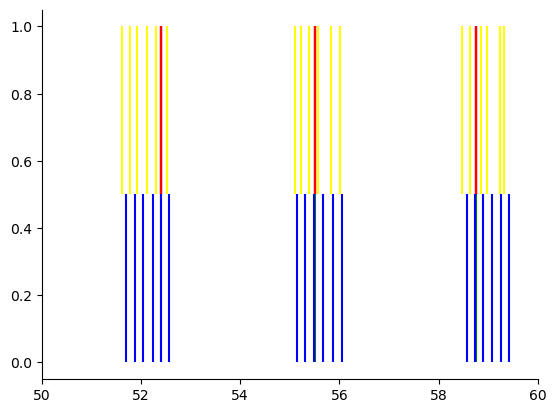

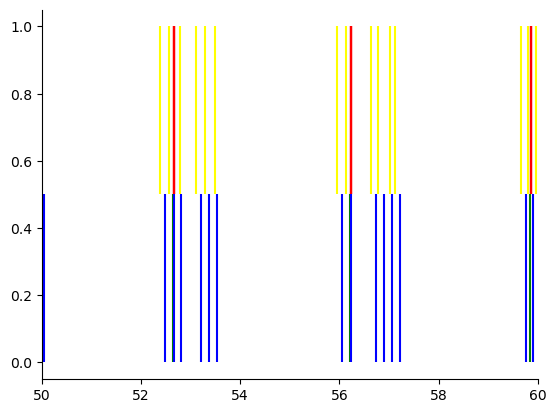

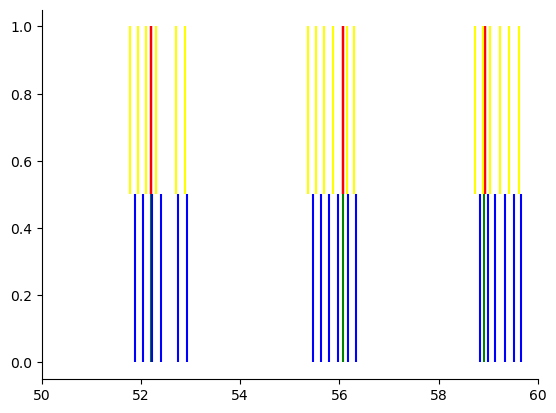

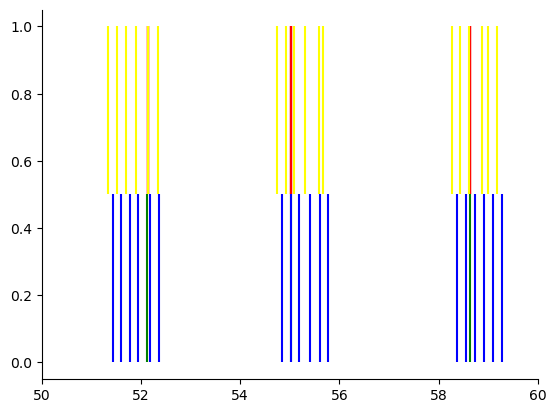

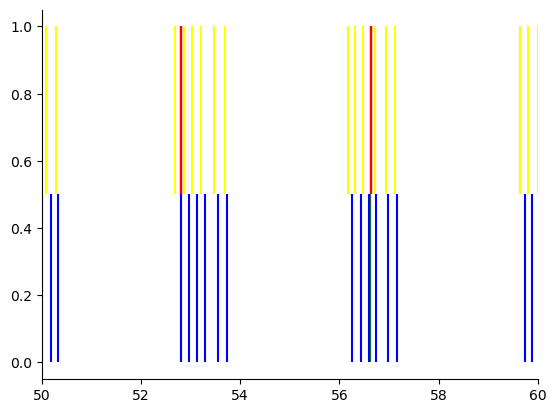

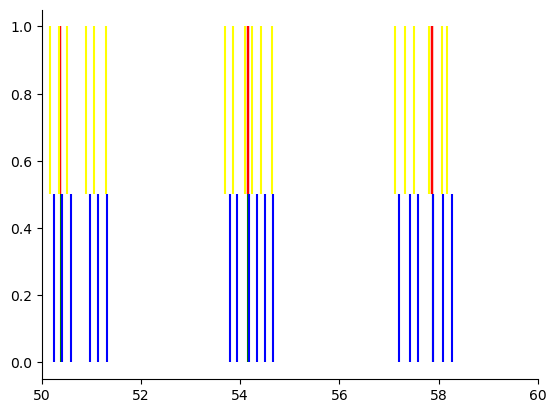

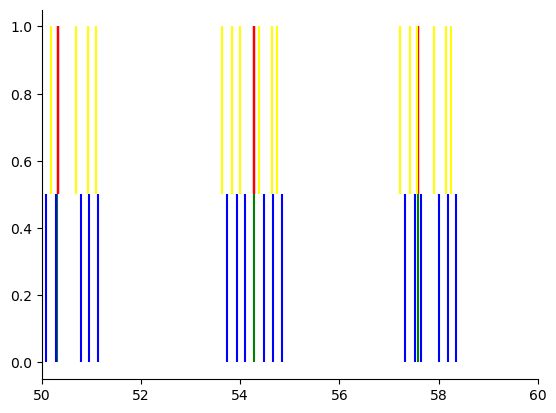

P20 B1


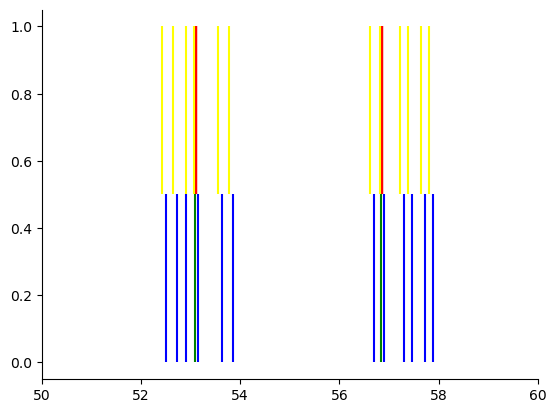

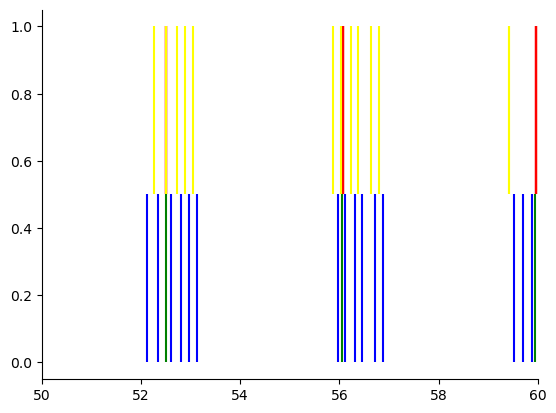

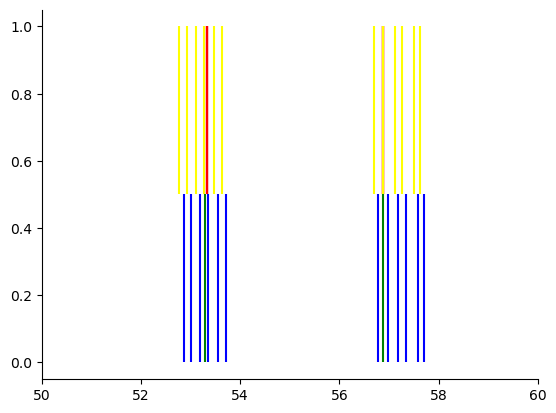

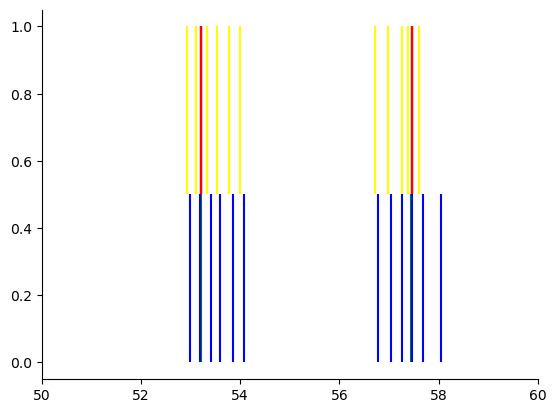

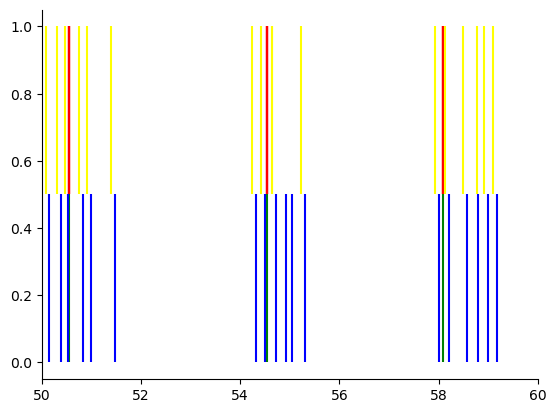

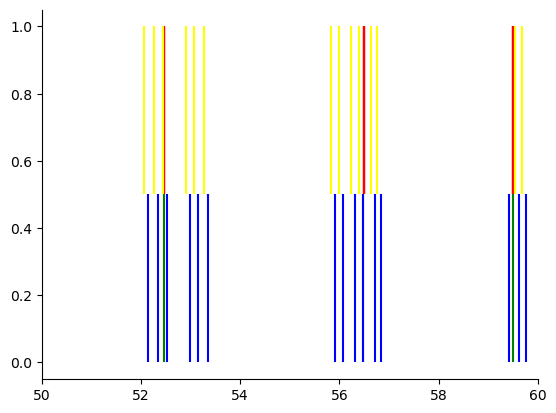

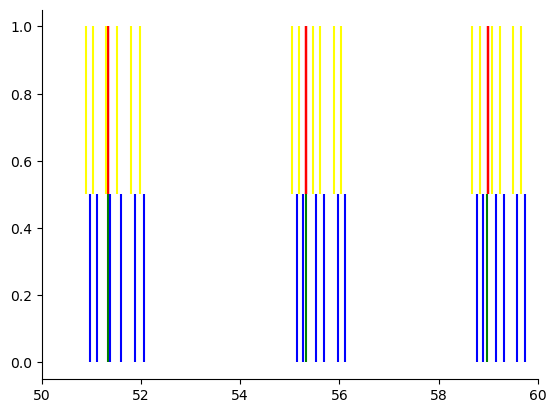

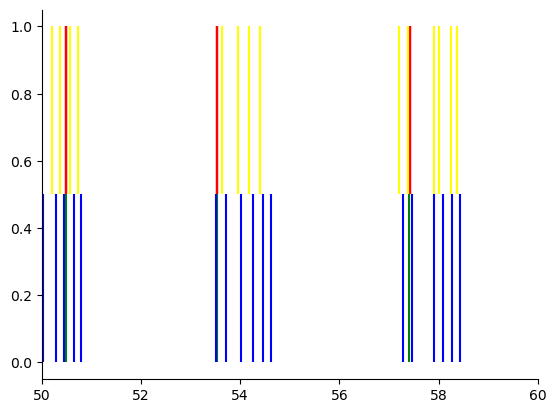

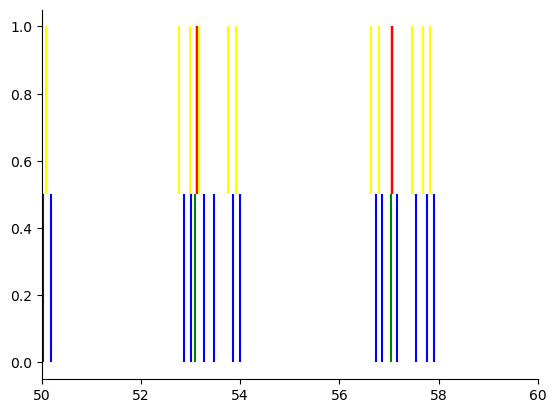

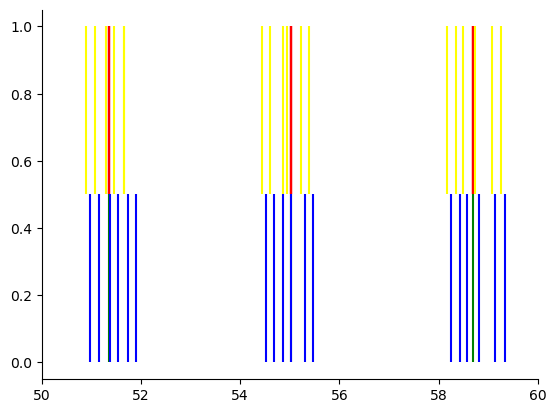

P20 B2


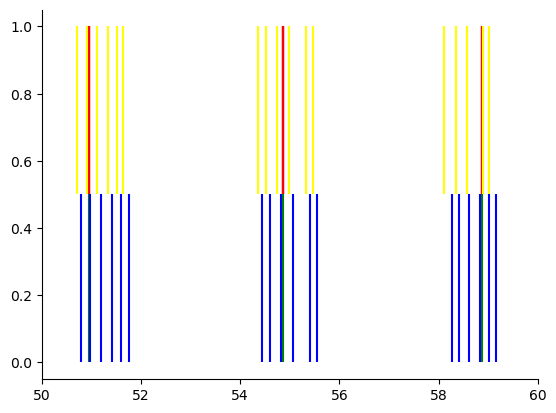

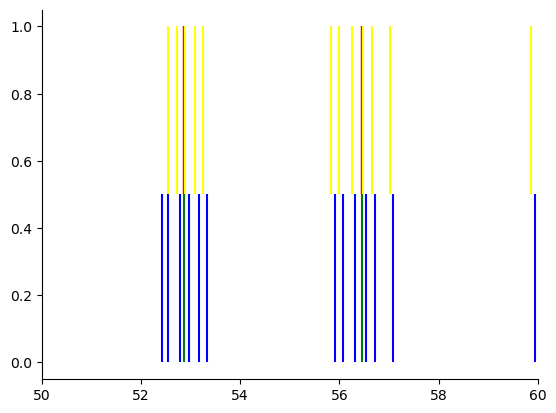

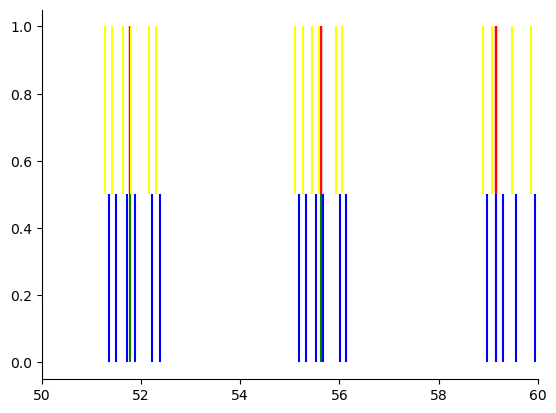

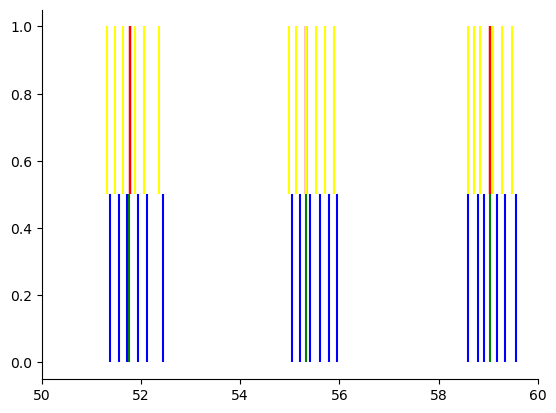

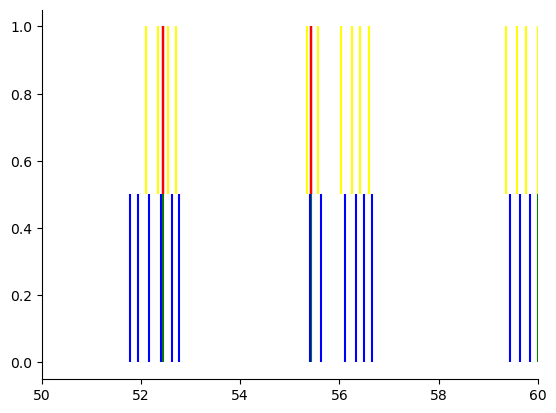

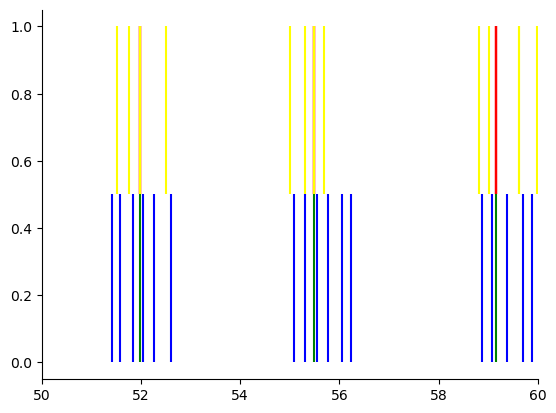

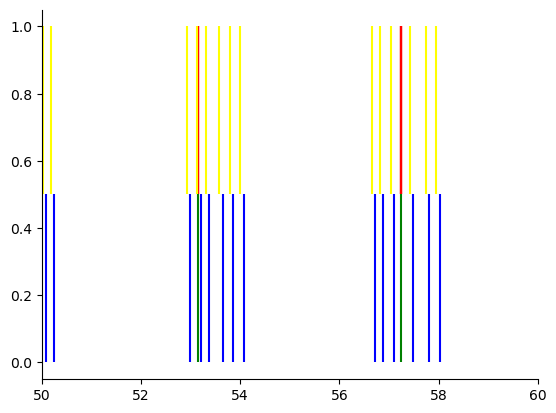

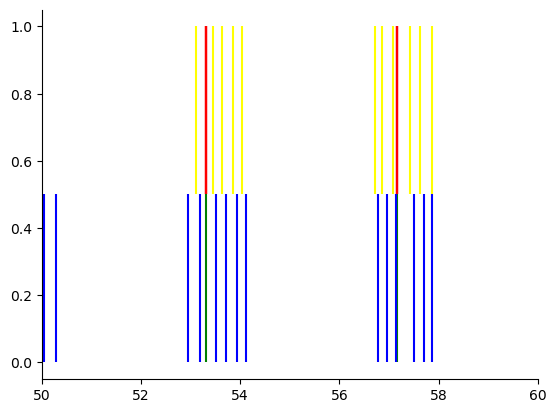

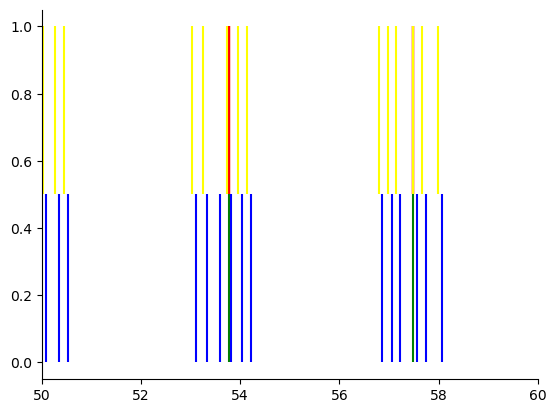

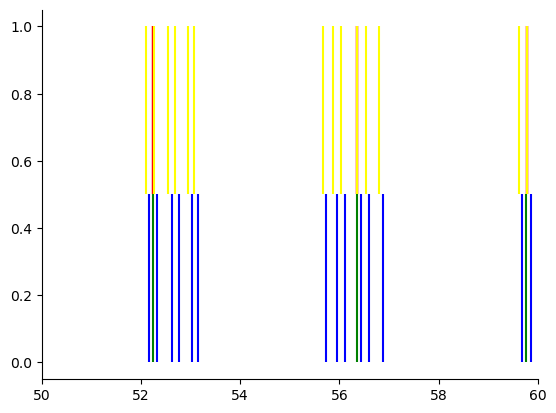

P21 B1


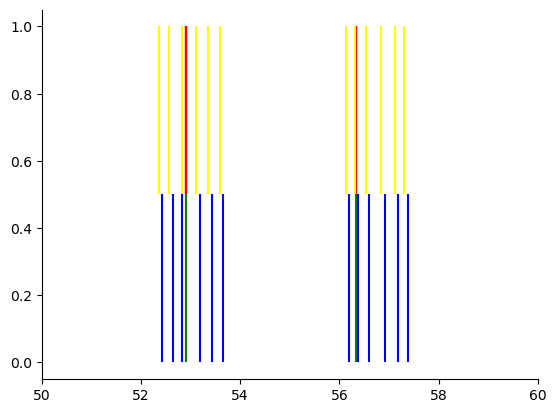

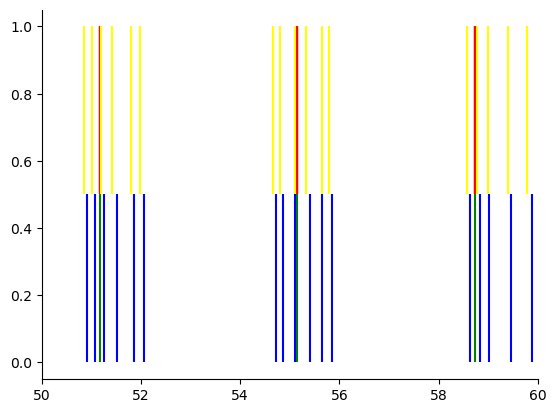

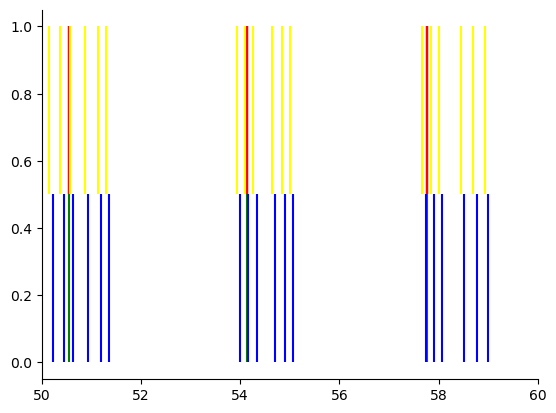

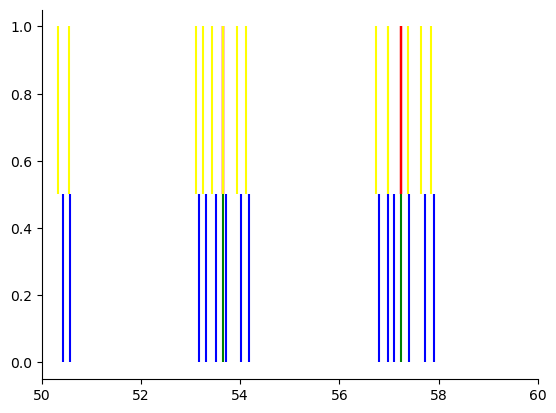

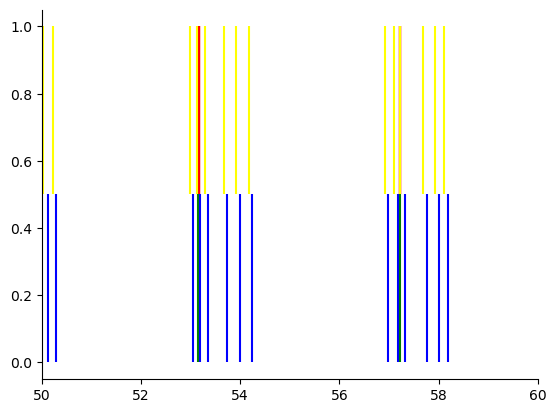

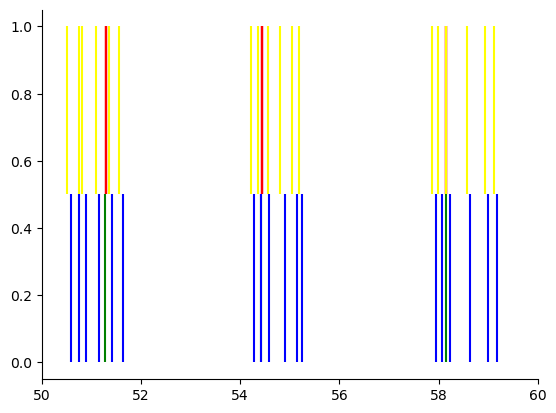

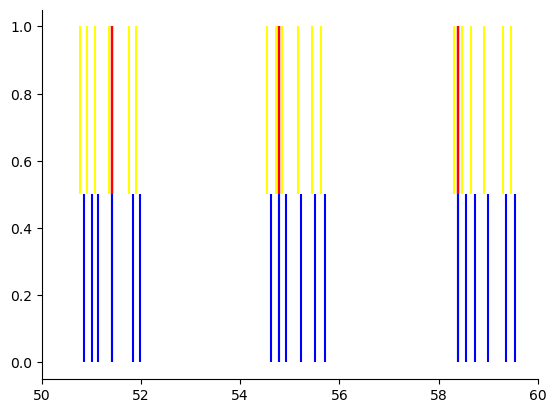

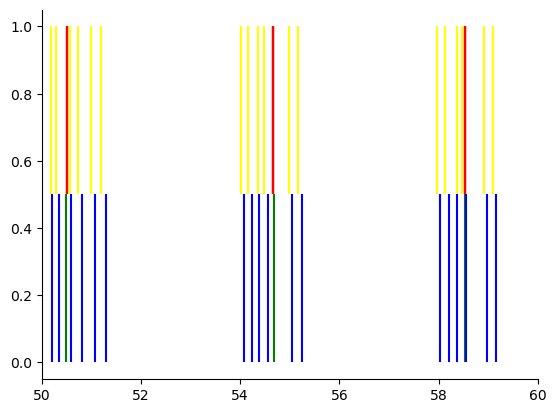

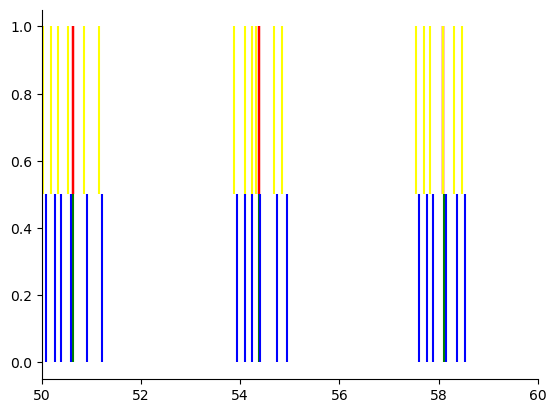

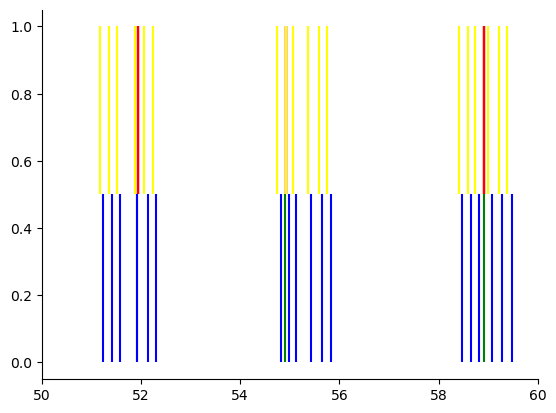

P21 B2


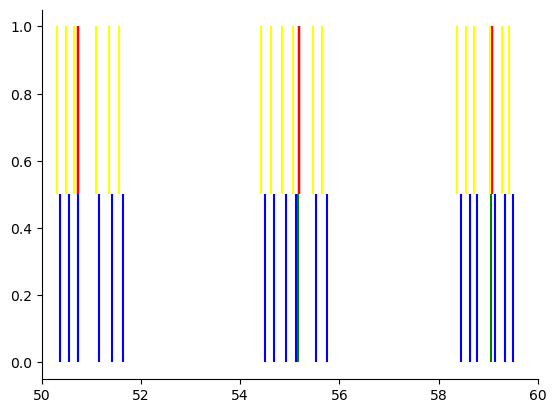

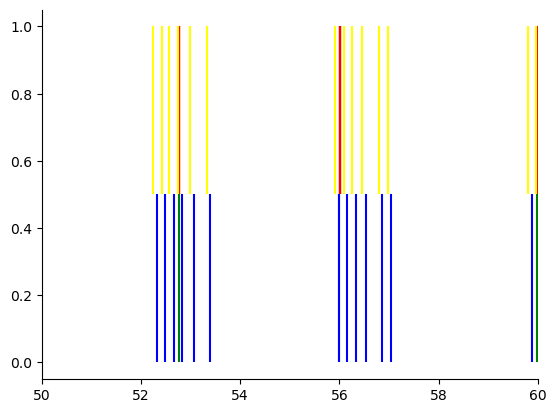

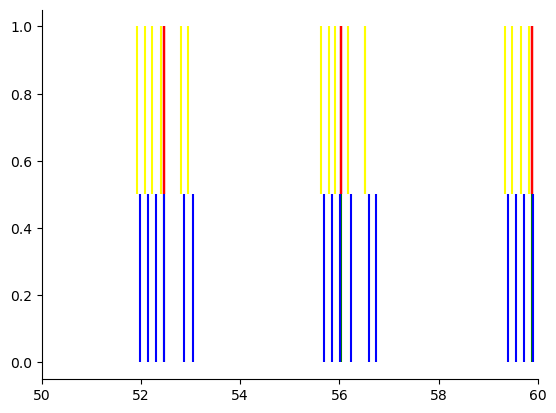

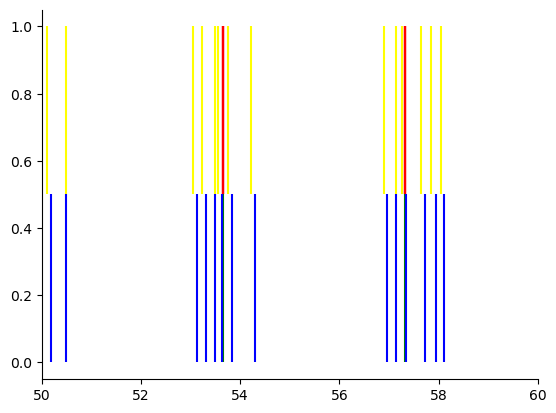

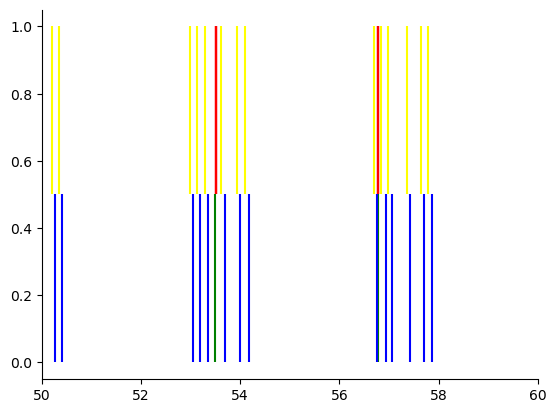

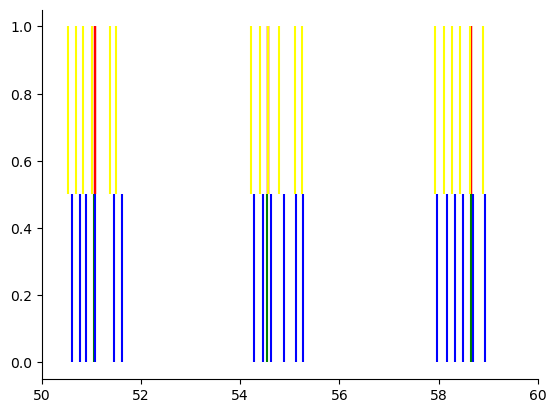

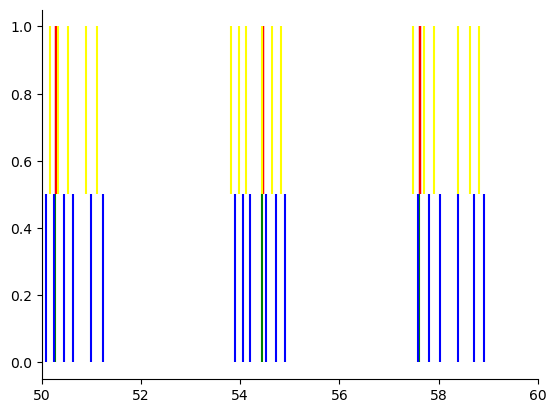

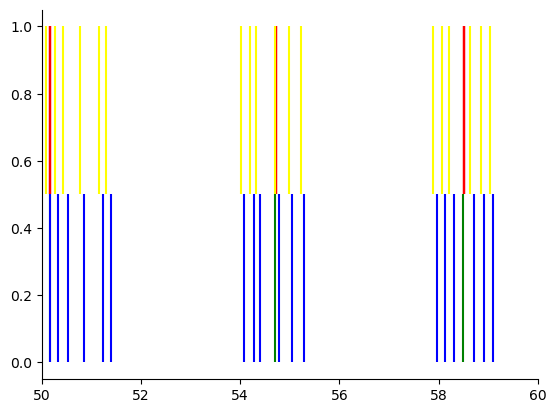

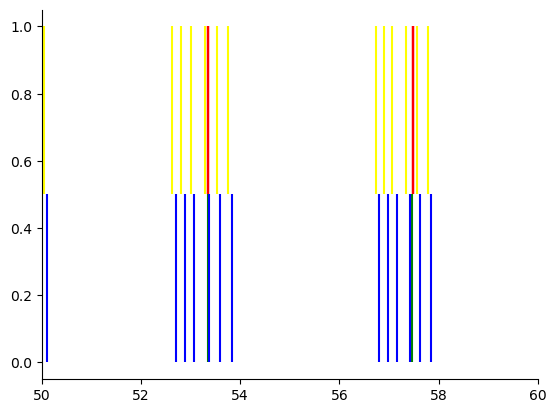

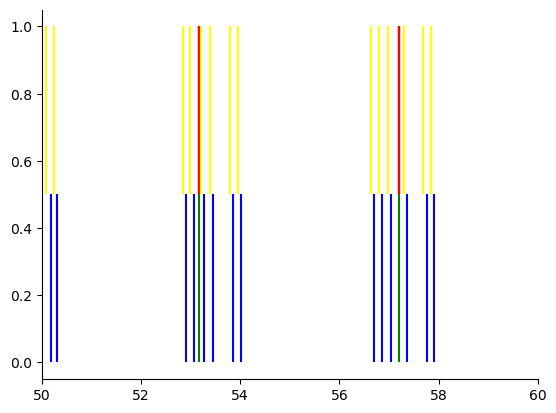

In [27]:
for p in participants:
    p_code = p.split('P')[1]
    p_info = meta_info[meta_info.participant == p]
    # loop through all sessions - this is one folder
    for s in sessions:
        print(p, s)
        s_code = s.split('B')[1]
        s_info = p_info[p_info.session == s]
        s_info = s_info.iloc[-1, :]

        if len(s_info) == 2:
            print(s_info)
        
        jatos_data = full_data[full_data.participant_id == int(p_code)]
        jatos_data = jatos_data[jatos_data.session_number == int(s_code)]

                    
        missing_blocks = s_info.missing_blocks
        original_block_list = np.arange(1, 11)
                    
        include_blocks = get_relevant_blocks(original_block_list, missing_blocks, s_info.reloaded_blocks)
        
        #jatos_data = full_data[full_data.participant_id == int(p_code)]
        #jatos_data = jatos_data[jatos_data.session_number == int(s_code)]
        
        for b, dt in enumerate(np.sort(np.unique(jatos_data.startup_datetime))):
            block_id = b+1

            if block_id in include_blocks:
                jatos_block_data = jatos_data[jatos_data.startup_datetime == dt]
                full_data.loc[jatos_block_data.index, 'block'] = block_id
                
                event_block_data = all_events[all_events.participant == p]
                event_block_data = event_block_data[event_block_data.session == s]
                event_block_data = event_block_data[event_block_data.block == block_id]
    
                diode_setup_block_data = diode_setup_data[diode_setup_data.participant_id == int(p_code)]
                diode_setup_block_data = diode_setup_block_data[diode_setup_block_data.session_number == int(s_code)]
                diode_setup_block_data = diode_setup_block_data[diode_setup_block_data.startup_datetime == dt]
                block_onset = s_info.use_block_onset
                if len(block_onset) > 1:
                    block_onset = block_onset.split(',')[b].strip(',')
                    
                jatos_block_start = diode_setup_block_data.change_timestamps.iloc[0][int(block_onset)]
                # jatos_block_start = diode_setup_block_data.change_timestamps.iloc[0][s_info.use_block_onset]
    
                block_info = all_blocks[all_blocks.participant == p]
                block_info = block_info[block_info.session == s]
                block_info = block_info[block_info.block_number == block_id]
    
                tap_block_data = all_taps[all_taps.participant == p]
                tap_block_data = tap_block_data[tap_block_data.session == s]
                tap_block_data = tap_block_data[tap_block_data.block_number == block_id]
    
                flash_ons_diode = []
                flash_ons_jatos  = []
                taps_on_sensor = []
                taps_jatos = []
    
                if len(block_info) > 0:
                    flash_ons_jatos = (jatos_block_data.startTime - jatos_block_start + jatos_block_data.flashOnTime)/1000
                    flash_ons_diode = event_block_data.start_time - block_info['onset'].iloc[-1]
                    taps_on_sensor = tap_block_data.start_time - block_info['onset'].iloc[-1]
    
                    flash_ons_jatos = flash_ons_jatos[flash_ons_jatos>0]
                    flash_ons_diode = flash_ons_diode[flash_ons_diode>0]
                    taps_on_sensor = taps_on_sensor[taps_on_sensor>0]
    
                    taps_jatos =  (jatos_block_data.startTime - jatos_block_start + jatos_block_data.flashOnTime + jatos_block_data.touchOn)/1000
                    full_data.loc[flash_ons_jatos.index.values, 'event_onset_in_block'] = flash_ons_jatos.values
                    try:
                        full_data.loc[flash_ons_jatos.index.values, 'tap_onset_in_block'] = taps_jatos.values
                    except ValueError:
                        pass
                        
                    for x in flash_ons_jatos.index.values:
                        jatos_onset = full_data.loc[x, 'event_onset_in_block']
                        diode_onset = flash_ons_diode.values[np.argmin(abs(flash_ons_diode.values - jatos_onset))]
                        jatos_tap = full_data.loc[x, 'tap_onset_in_block']
                        
                        if abs(diode_onset - jatos_onset) < 0.1:
                            full_data.loc[x, 'diode_onset_in_block'] = diode_onset
                        else:
                            pass
    
                        sound_onset = taps_on_sensor - jatos_tap
                        earlier_taps = sound_onset[sound_onset <= 0]
                        if len(earlier_taps) > 0:
                            sound_tap_idx = np.argmin(abs(earlier_taps))
                            sound_tap = earlier_taps.values[sound_tap_idx] 
                            sound_tap += jatos_tap
                            
                            if abs(earlier_taps.values[sound_tap_idx]) < 0.3:
                                full_data.loc[x, 'tap_sound_onset_in_block'] = sound_tap
                                jatos_block_data.loc[x, 'tap_sound_onset_in_block'] = sound_tap
                                
                            else:
                                pass
    
                    fig,axs = plt.subplots(2, 1, figsize = (15, 6))
                    axs[0].vlines(flash_ons_diode, 0, 0.5, color = 'green')
                    axs[0].vlines(flash_ons_jatos, 0.5, 1, color = 'red')
                    axs[1].vlines(taps_jatos, 0, 0.5, color = 'blue')
                    axs[1].vlines(jatos_block_data['tap_sound_onset_in_block'], 0.5, 1, color = 'yellow')
                    # plt.xlim([50, 60])
                    plt.show()
                        
        jatos_data = full_data[full_data.participant_id == int(p_code)]
        jatos_data = jatos_data[jatos_data.session_number == int(s_code)]
        print(f"NAN percentage: {round(sum(np.isnan(jatos_data['tap_sound_onset_in_block']))/len(jatos_data) * 100)}%")
                

-94.0


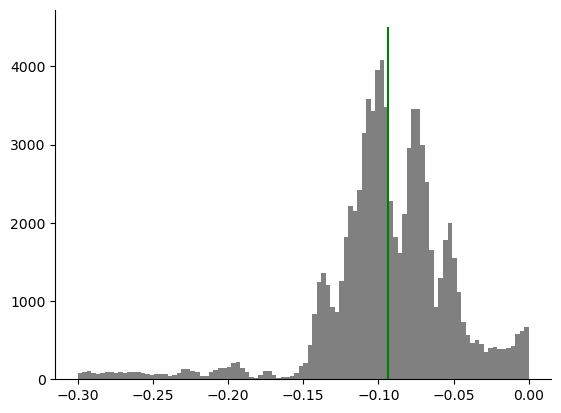

In [28]:
plt.hist(full_data.tap_sound_onset_in_block - full_data.tap_onset_in_block, bins = 100, color = 'grey')
plt.vlines(np.mean(full_data.tap_sound_onset_in_block - full_data.tap_onset_in_block), 0, 4500, color = 'green')

print(round(np.mean(full_data.tap_sound_onset_in_block - full_data.tap_onset_in_block), 3)*1000)

plt.savefig(f'{results_path}/sound_onset_delay_{study_name}.svg')

-13.0


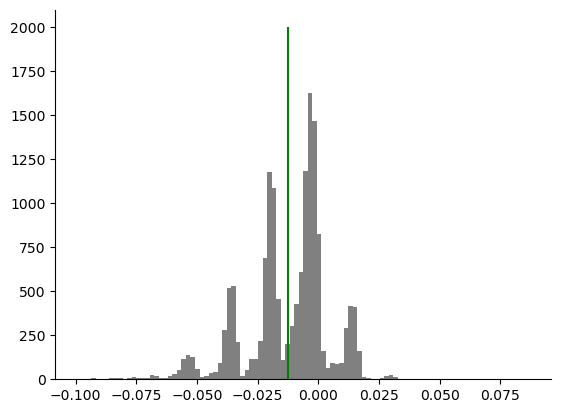

In [29]:
plt.hist(full_data[full_data.choiceOrder == 0].diode_onset_in_block - full_data[full_data.choiceOrder == 0].event_onset_in_block, bins = 100, color = 'grey')
plt.vlines(np.mean(full_data[full_data.choiceOrder == 0].diode_onset_in_block - full_data[full_data.choiceOrder == 0].event_onset_in_block), 0, 2000, color = 'green')
print(round(np.mean(full_data[full_data.choiceOrder == 0].diode_onset_in_block - full_data[full_data.choiceOrder == 0].event_onset_in_block), 3)*1000);
plt.savefig(f'{results_path}/light_onset_delay_{study_name}.svg')

In [30]:
full_data['start_event_in_block'] = full_data['event_onset_in_block']
full_data['start_trial_in_block'] = full_data['start_event_in_block'] - (full_data['flashOnTime']/1000)

full_data.to_csv(complete_output_path, index = False)

In [31]:
## Recreate the movement rates with sound and light data

noise_sound_df = full_data[full_data.success == 1].reset_index(drop = True)
noise_sound_df['relative_tap_onset'] = (noise_sound_df['tap_sound_onset_in_block'] - noise_sound_df['diode_onset_in_block']) * 1000
noise_sound_df['relative_tap_offset'] =  (noise_sound_df['relative_tap_onset'] + 70)

no flash no jump


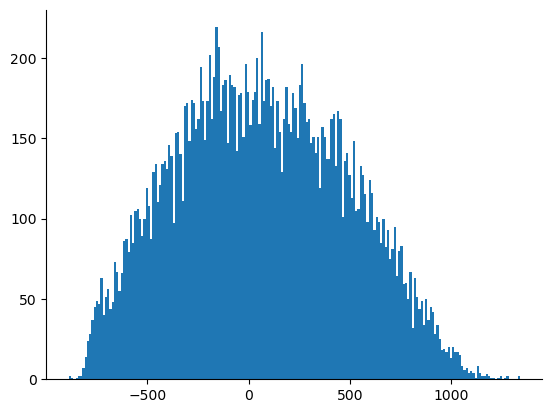

no flash jump


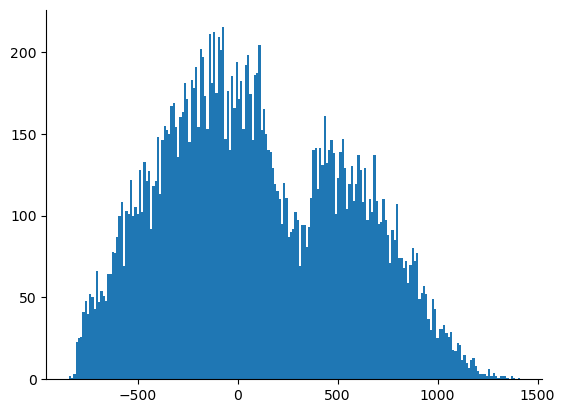

flash no jump


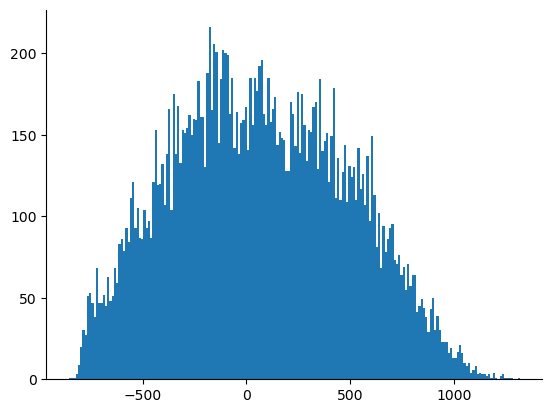

flash jump


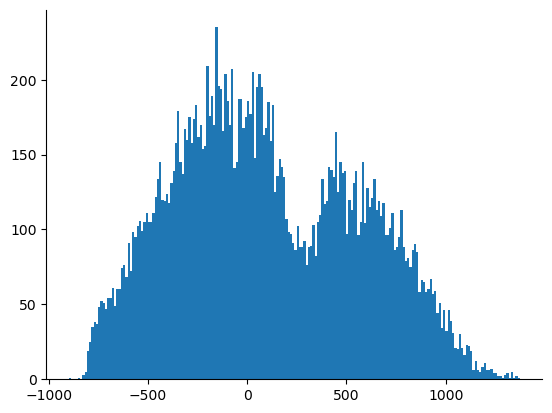

In [32]:
#plt.hist(noise_sound_df['relative_tap_onset'], bins = 100);

for flash in [0, 1]:
    for jump in [0, 1]:
        part_data = noise_sound_df[noise_sound_df.flashShown == flash]
        part_data = part_data[part_data.stimJumped == jump]
        print(['no flash', 'flash'][flash], ['no jump', 'jump'][jump])
        plt.hist(part_data['relative_tap_onset'], bins = 200)
        plt.show()

In [33]:
noise_sound_df = noise_sound_df.dropna(axis = 0, subset = 'relative_tap_onset')
noise_sound_df

,test_part,trial_type,trial_index,time_elapsed,internal_node_id,subject,component,startup_time,startup_datetime,success,...,session_number,event_onset_in_block,block,tap_onset_in_block,diode_onset_in_block,tap_sound_onset_in_block,start_event_in_block,start_trial_in_block,relative_tap_onset,relative_tap_offset
240,trial,canvas-mi-serial,4,19028,0.0-2.0-0.0-0.0,21102,Trials_Serial,2730.3,1677500484,1.0,...,2.0,5.156066,3.0,4.960340,5.119862,4.855146,5.156066,4.960340,-264.716351,-194.716351
241,trial,canvas-mi-serial,4,19028,0.0-2.0-0.0-0.0,21102,Trials_Serial,2730.3,1677500484,1.0,...,2.0,5.156066,3.0,5.143340,5.119862,5.035333,5.156066,4.960340,-84.529440,-14.529440
242,trial,canvas-mi-serial,4,19028,0.0-2.0-0.0-0.0,21102,Trials_Serial,2730.3,1677500484,1.0,...,2.0,5.156066,3.0,5.326340,5.119862,5.215533,5.156066,4.960340,95.671221,165.671221
243,trial,canvas-mi-serial,4,19028,0.0-2.0-0.0-0.0,21102,Trials_Serial,2730.3,1677500484,1.0,...,2.0,5.156066,3.0,5.501340,5.119862,5.390784,5.156066,4.960340,270.922233,340.922233
244,trial,canvas-mi-serial,4,19028,0.0-2.0-0.0-0.0,21102,Trials_Serial,2730.3,1677500484,1.0,...,2.0,5.156066,3.0,5.676340,5.119862,5.564821,5.156066,4.960340,444.959193,514.959193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95987,trial,canvas-mi-serial,80,160622,0.0-2.0-0.38-0.38,22443,Trials_Serial,1225.2,1682342608,1.0,...,2.0,148.592634,10.0,149.495958,148.590835,149.421705,148.592634,148.377958,830.869530,900.869530
95988,trial,canvas-mi-serial,82,164278,0.0-2.0-0.39-0.39,22443,Trials_Serial,1225.2,1682342608,1.0,...,2.0,152.649986,10.0,152.125958,152.649643,152.055211,152.649986,152.125958,-594.432674,-524.432674
95989,trial,canvas-mi-serial,82,164278,0.0-2.0-0.39-0.39,22443,Trials_Serial,1225.2,1682342608,1.0,...,2.0,152.649986,10.0,152.300958,152.649643,152.232409,152.649986,152.125958,-417.234394,-347.234394
95990,trial,canvas-mi-serial,82,164278,0.0-2.0-0.39-0.39,22443,Trials_Serial,1225.2,1682342608,1.0,...,2.0,152.649986,10.0,152.492958,152.649643,152.415579,152.649986,152.125958,-234.064709,-164.064709


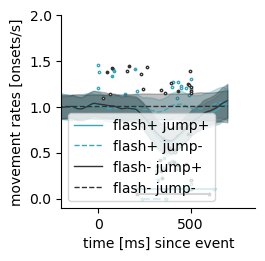

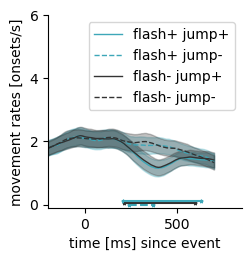

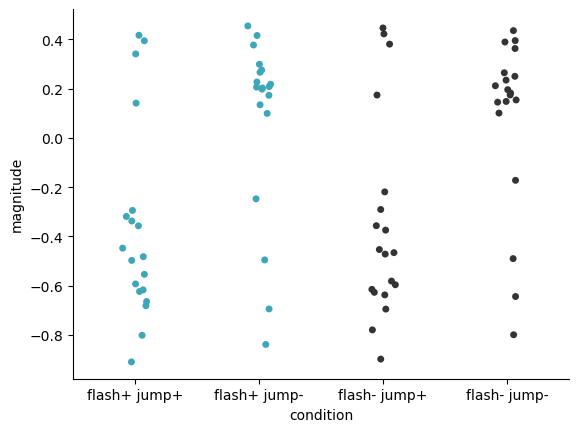

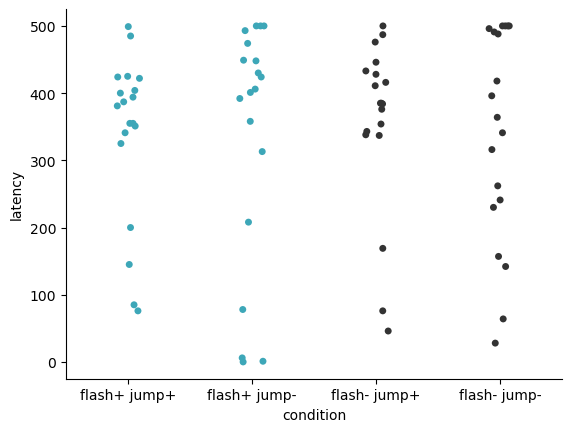

Results from ANOVA with 
DEPENDENT variable: MAGNITUDE; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.2836 1.0000 18.0000 0.6009
stim_jumped             37.0069 1.0000 18.0000 0.0000
flash_shown:stim_jumped  0.1078 1.0000 18.0000 0.7464

Results from ANOVA with 
DEPENDENT variable: LATENCY; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT_ID


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              0.3524 1.0000 18.0000 0.5601
stim_jumped              0.1391 1.0000 18.0000 0.7135
flash_shown:stim_jumped  0.1677 1.0000 18.0000 0.6870



In [34]:
movement_rate_metrics_path = f'{results_path}/movement_rate_metrics_sensors_{study_name}.csv' # here we put the path name for the rate metrics
movement_rate_figure_path = f'{results_path}/movement_rate_figure_sensors_{study_name}.svg' # here we put the path name for the rate metrics
movement_rate_test_path  = f'{data_path}/test_files/movement_rate_test_sensors_{study_name}.csv' # this is a test file we create manually by saving the first version of the analysis testing for validity
movement_rate_cluster_file = f'{results_path}/movement_rate_clusters_sensors_{study_name}.csv'
raw_movement_rate_file = f'{results_path}/raw_movement_rate_clusters_sensors_{study_name}.svg'

rate_analysis_parameters = {'window_start': -300,
                            'window_end': 700,
                            'search_start': 0,
                            'search_end': 500,
                            'baseline_start': -100,
                            'baseline_end': 0,
                            'alpha': 1/50}

analysis_rates(noise_sound_df,
               'relative_tap_onset',
               'relative_tap_offset',
               participant_col,
               rate_analysis_parameters,
               touch_order_col,
               conditions_rates, 
               color_rates,
               linestyles,
               movement_rate_metrics_path,
               movement_rate_figure_path,
               raw_movement_rate_file,
               dependent_variables,
               independent_variables,
               baseline_name,
               results_path,
               movement_rate_cluster_file)

## Saccades 

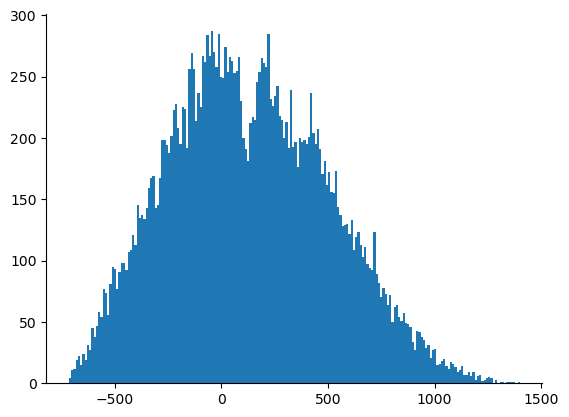

In [35]:
all_saccades = pd.read_csv('../../../results/inlab/all_saccades.csv')
background_saccades = all_saccades[all_saccades['condition'] == condition_code].reset_index(drop = True)

background_saccades['relative_eye_onset'] = background_saccades['relative_eye_movement_time'] * 1000
background_saccades.loc[background_saccades['relative_eye_onset']<= -1000, 'relative_eye_onset'] = np.nan
background_saccades['relative_eye_offset'] = background_saccades['relative_eye_onset'] + background_saccades['duration'] * 1000
background_saccades['flash'] = background_saccades['flash_shown']
background_saccades['shift'] = background_saccades['jump_shown']

plt.hist(background_saccades.relative_eye_onset, bins = 200);

In [36]:
for p in np.unique(background_saccades.participant):
    p_saccades = background_saccades[background_saccades.participant == p]
    for s in np.unique(p_saccades.session):
        s_saccades = p_saccades[p_saccades.session == s]
        for b in np.unique(s_saccades.block):
            b_saccades = s_saccades[s_saccades.block == b]
            for t in np.unique(b_saccades.trial_n):
                t_saccades = b_saccades[b_saccades.trial_n == t]
                for n, idx in enumerate(t_saccades.index):
                    background_saccades.loc[idx, 'choiceOrder'] = int(n + 1)

In [37]:
conditions_rates = {
    'flash+ jump+': {'flash': 1,
                  'shift': 1},
    'flash+ jump-': {'flash': 1,
                  'shift': 0},
    'flash- jump+': {'flash': 0,
                  'shift': 1},
    'flash- jump-': {'flash': 0,
                  'shift': 0},
}

gaze_metrics_path = f'{results_path}/gaze_rate_metrics_{study_name}.csv'
gaze_rate_figure_path = f'{results_path}/gaze_rate_figure_{study_name}.svg'
raw_gaze_rate_file = f'{results_path}/raw_gaze_rate_clusters_{study_name}.svg'
gaze_rate_cluster_file = f'{results_path}/gaze_rate_clusters_{study_name}.csv'

rate_analysis_parameters = {'window_start': -700,
                            'window_end': 1500,
                            'search_start': 0,
                            'search_end': 300,
                            'baseline_start': -100,
                            'baseline_end': 0,
                            'alpha': 1/50}

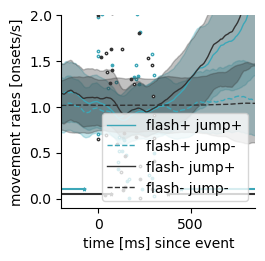

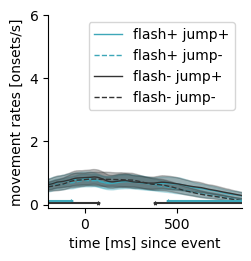

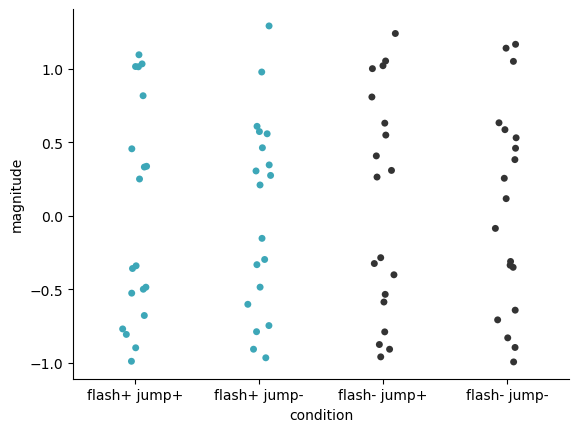

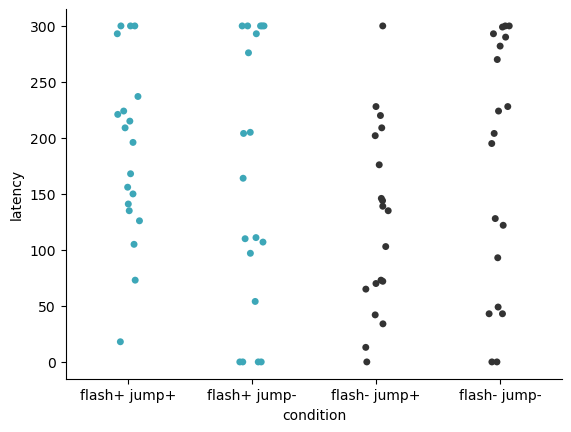

Results from ANOVA with 
DEPENDENT variable: MAGNITUDE; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              4.9196 1.0000 18.0000 0.0397
stim_jumped              0.0057 1.0000 18.0000 0.9406
flash_shown:stim_jumped  0.7671 1.0000 18.0000 0.3927

Results from ANOVA with 
DEPENDENT variable: LATENCY; 
INDEPENDENT variables: ['FLASH_SHOWN', 'STIM_JUMPED'], 
GROUPED by: PARTICIPANT


                        Anova
                        F Value Num DF  Den DF Pr > F
-----------------------------------------------------
flash_shown              1.1097 1.0000 18.0000 0.3061
stim_jumped              0.4293 1.0000 18.0000 0.5206
flash_shown:stim_jumped  3.8318 1.0000 18.0000 0.0660



In [38]:
analysis_rates(background_saccades,
               'relative_eye_offset',
               'relative_eye_onset',
               'participant',
               rate_analysis_parameters,
               touch_order_col,
               conditions_rates, 
               color_rates,
               linestyles,
               gaze_metrics_path,
               gaze_rate_figure_path,
               raw_gaze_rate_file,
               dependent_variables,
               independent_variables,
               baseline_name,
               results_path,
               gaze_rate_cluster_file)